In [41]:
import warnings
import time
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import missingno as msno
import xgboost as xgb
import optuna
from optuna.pruners import MedianPruner
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import LocalOutlierFactor, KNeighborsRegressor
from sklearn.ensemble import IsolationForest, RandomForestRegressor, StackingRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler, MaxAbsScaler, MinMaxScaler
from sklearn.inspection import permutation_importance
from IPython.display import display, display_html
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import ElasticNetCV, ElasticNet, RidgeCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", lambda x: "%.3f" % x)
pd.set_option("display.width", 500)

data_path = "train.csv"
test_path = "test.csv"

def load_data(path):
    data = pd.read_csv(path)
    return data

df = load_data(data_path)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.000,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.000,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
test_df = load_data(test_path)
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.000,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,CBlock,TA,TA,No,Rec,468.000,LwQ,144.000,270.000,882.000,GasA,TA,Y,SBrkr,896,0,0,896,0.000,0.000,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.000,Unf,1.000,730.000,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.000,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.000,TA,TA,CBlock,TA,TA,No,ALQ,923.000,Unf,0.000,406.000,1329.000,GasA,TA,Y,SBrkr,1329,0,0,1329,0.000,0.000,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.000,Unf,1.000,312.000,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.000,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,PConc,Gd,TA,No,GLQ,791.000,Unf,0.000,137.000,928.000,GasA,Gd,Y,SBrkr,928,701,0,1629,0.000,0.000,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.000,Fin,2.000,482.000,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.000,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.000,TA,TA,PConc,TA,TA,No,GLQ,602.000,Unf,0.000,324.000,926.000,GasA,Ex,Y,SBrkr,926,678,0,1604,0.000,0.000,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.000,Fin,2.000,470.000,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.000,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.000,Gd,TA,PConc,Gd,TA,No,ALQ,263.000,Unf,0.000,1017.000,1280.000,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.000,0.000,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.000,RFn,2.000,506.000,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [3]:
def check_df(dataframe, head=5):
    print("###################### Shape ######################")
    print(dataframe.shape)
    print("\n###################### Info ######################")
    dataframe.info()
    print("\n###################### Types ######################")
    display(dataframe.dtypes.to_frame("Type"))
    print("\n##################### Head #####################")
    display(dataframe.head(head))
    print("\n###################### Tail ######################")
    display(dataframe.tail(head))
    print("\n###################### Describe ######################")
    display(dataframe.describe([0, 0.05, 0.50, 0.95, 0.99, 1]).T)
    print("\n###################### Unique Value Counts per Column ######################")
    display(dataframe[dataframe.columns].nunique())
    print("\n###################### NA ######################")
    display(dataframe.isnull().sum().to_frame("Missing Values"))

check_df(df)

###################### Shape ######################
(1460, 81)

###################### Info ######################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-n

,Type
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
Street,object
Alley,object
LotShape,object
LandContour,object
Utilities,object



##################### Head #####################


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.000,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.000,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



###################### Tail ######################


...

,count,mean,std,min,0%,5%,50%,95%,99%,100%,max
Id,1460.000,730.500,421.610,1.000,1.000,73.950,730.500,1387.050,1445.410,1460.000,1460.000
MSSubClass,1460.000,56.897,42.301,20.000,20.000,20.000,50.000,160.000,190.000,190.000,190.000
LotFrontage,1201.000,70.050,24.285,21.000,21.000,34.000,69.000,107.000,141.000,313.000,313.000
LotArea,1460.000,10516.828,9981.265,1300.000,1300.000,3311.700,9478.500,17401.150,37567.640,215245.000,215245.000
OverallQual,1460.000,6.099,1.383,1.000,1.000,4.000,6.000,8.000,10.000,10.000,10.000
OverallCond,1460.000,5.575,1.113,1.000,1.000,4.000,5.000,8.000,9.000,9.000,9.000
YearBuilt,1460.000,1971.268,30.203,1872.000,1872.000,1916.000,1973.000,2007.000,2009.000,2010.000,2010.000
YearRemodAdd,1460.000,1984.866,20.645,1950.000,1950.000,1950.000,1994.000,2007.000,2009.000,2010.000,2010.000
MasVnrArea,1452.000,103.685,181.066,0.000,0.000,0.000,0.000,456.000,791.920,1600.000,1600.000
BsmtFinSF1,1460.000,443.640,456.098,0.000,0.000,0.000,383.500,1274.000,1572.410,5644.000,5644.000



###################### Unique Value Counts per Column ######################


Id               1460
MSSubClass         15
MSZoning            5
LotFrontage       110
LotArea          1073
Street              2
Alley               2
LotShape            4
LandContour         4
Utilities           2
LotConfig           5
LandSlope           3
Neighborhood       25
Condition1          9
Condition2          8
BldgType            5
HouseStyle          8
OverallQual        10
OverallCond         9
YearBuilt         112
YearRemodAdd       61
RoofStyle           6
RoofMatl            8
Exterior1st        15
Exterior2nd        16
MasVnrType          3
MasVnrArea        327
ExterQual           4
ExterCond           5
Foundation          6
BsmtQual            4
BsmtCond            4
BsmtExposure        4
BsmtFinType1        6
BsmtFinSF1        637
BsmtFinType2        6
BsmtFinSF2        144
BsmtUnfSF         780
TotalBsmtSF       721
Heating             6
HeatingQC           5
CentralAir          2
Electrical          5
1stFlrSF          753
2ndFlrSF          417
LowQualFin


###################### NA ######################


,Missing Values
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
Street,0
Alley,1369
LotShape,0
LandContour,0
Utilities,0


In [4]:
# ========================================
# MSSubClass: Convert to Meaningful Categories
# ========================================
# MSSubClass is nominal categorical encoded as numbers
# Converting to readable category names for better interpretability

mssubclass_map = {
    20: '1story_1946+',
    30: '1story_1945-',
    40: '1story_unf_attic',
    45: '1.5story_unf',
    50: '1.5story_fin',
    60: '2story_1946+',
    70: '2story_1945-',
    75: '2.5story_all_ages',
    80: 'split_multilevel',
    85: 'split_foyer',
    90: 'duplex_all_style_age',
    120: '1story_PUD_1946+',
    150: '1.5story_PUD_all',
    160: '2story_PUD_1946+',
    180: 'PUD_multilevel',
    190: '2family_conversion'
}

# Apply mapping
df['MSSubClass'] = df['MSSubClass'].map(mssubclass_map)

# Verify conversion
print("MSSubClass dtype:", df['MSSubClass'].dtype)
print("MSSubClass unique values:", df['MSSubClass'].nunique())
print("\nValue counts:")
print(df['MSSubClass'].value_counts())

MSSubClass dtype: object
MSSubClass unique values: 15

Value counts:
MSSubClass
1story_1946+            536
2story_1946+            299
1.5story_fin            144
1story_PUD_1946+         87
1story_1945-             69
2story_PUD_1946+         63
2story_1945-             60
split_multilevel         58
duplex_all_style_age     52
2family_conversion       30
split_foyer              20
2.5story_all_ages        16
1.5story_unf             12
PUD_multilevel           10
1story_unf_attic          4
Name: count, dtype: int64


In [5]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """
    Returns the names of categorical, numerical, and categorical but cardinal columns in the dataset.
    
    Note: Categorical columns also include those that are numerically-coded but categorical in nature.
    
    Parameters
    ----------
        dataframe: pandas.DataFrame
                The dataframe from which the column names are to be extracted.
        cat_th: int, optional
                The threshold for the number of unique values to classify a numerical column as categorical.
        car_th: int, optional
                The threshold for the number of unique values to classify a categorical column as cardinal.
    
    Returns
    -------
        cat_cols: list
                A list of the names of categorical columns.
        num_cols: list
                A list of the names of numerical columns.
        cat_but_car: list
                A list of the names of categorical columns that are considered cardinal.
        num_but_cat: list
                A list of the names of numerical columns that are considered categorical.
    
    Examples
    --------
        import seaborn as sns
        df = sns.load_dataset("iris")
        print(grab_col_names(df))
    
    Notes
    -----
        - The sum of the lengths of cat_cols, num_cols, and cat_but_car equals the total number of columns.
        - Columns identified as "numeric but categorical" are included within the cat_cols list.
        - The total number of columns is equal to the sum of the lengths of the three returned lists: len(cat_cols) + len(num_cols) + len(cat_but_car).

    """
    
    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() <= cat_th and dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}")
    print(f"num_cols: {len(num_cols)}")
    print(f"cat_but_car: {len(cat_but_car)}")
    print(f"num_but_cat: {len(num_but_cat)}")
    return cat_cols, num_cols, cat_but_car, num_but_cat

cat_cols, num_cols, cat_but_car, num_but_cat = grab_col_names(df)

num_cols = [col for col in num_cols if col not in "Id"]

Observations: 1460
Variables: 81
cat_cols: 55
num_cols: 25
cat_but_car: 1
num_but_cat: 12


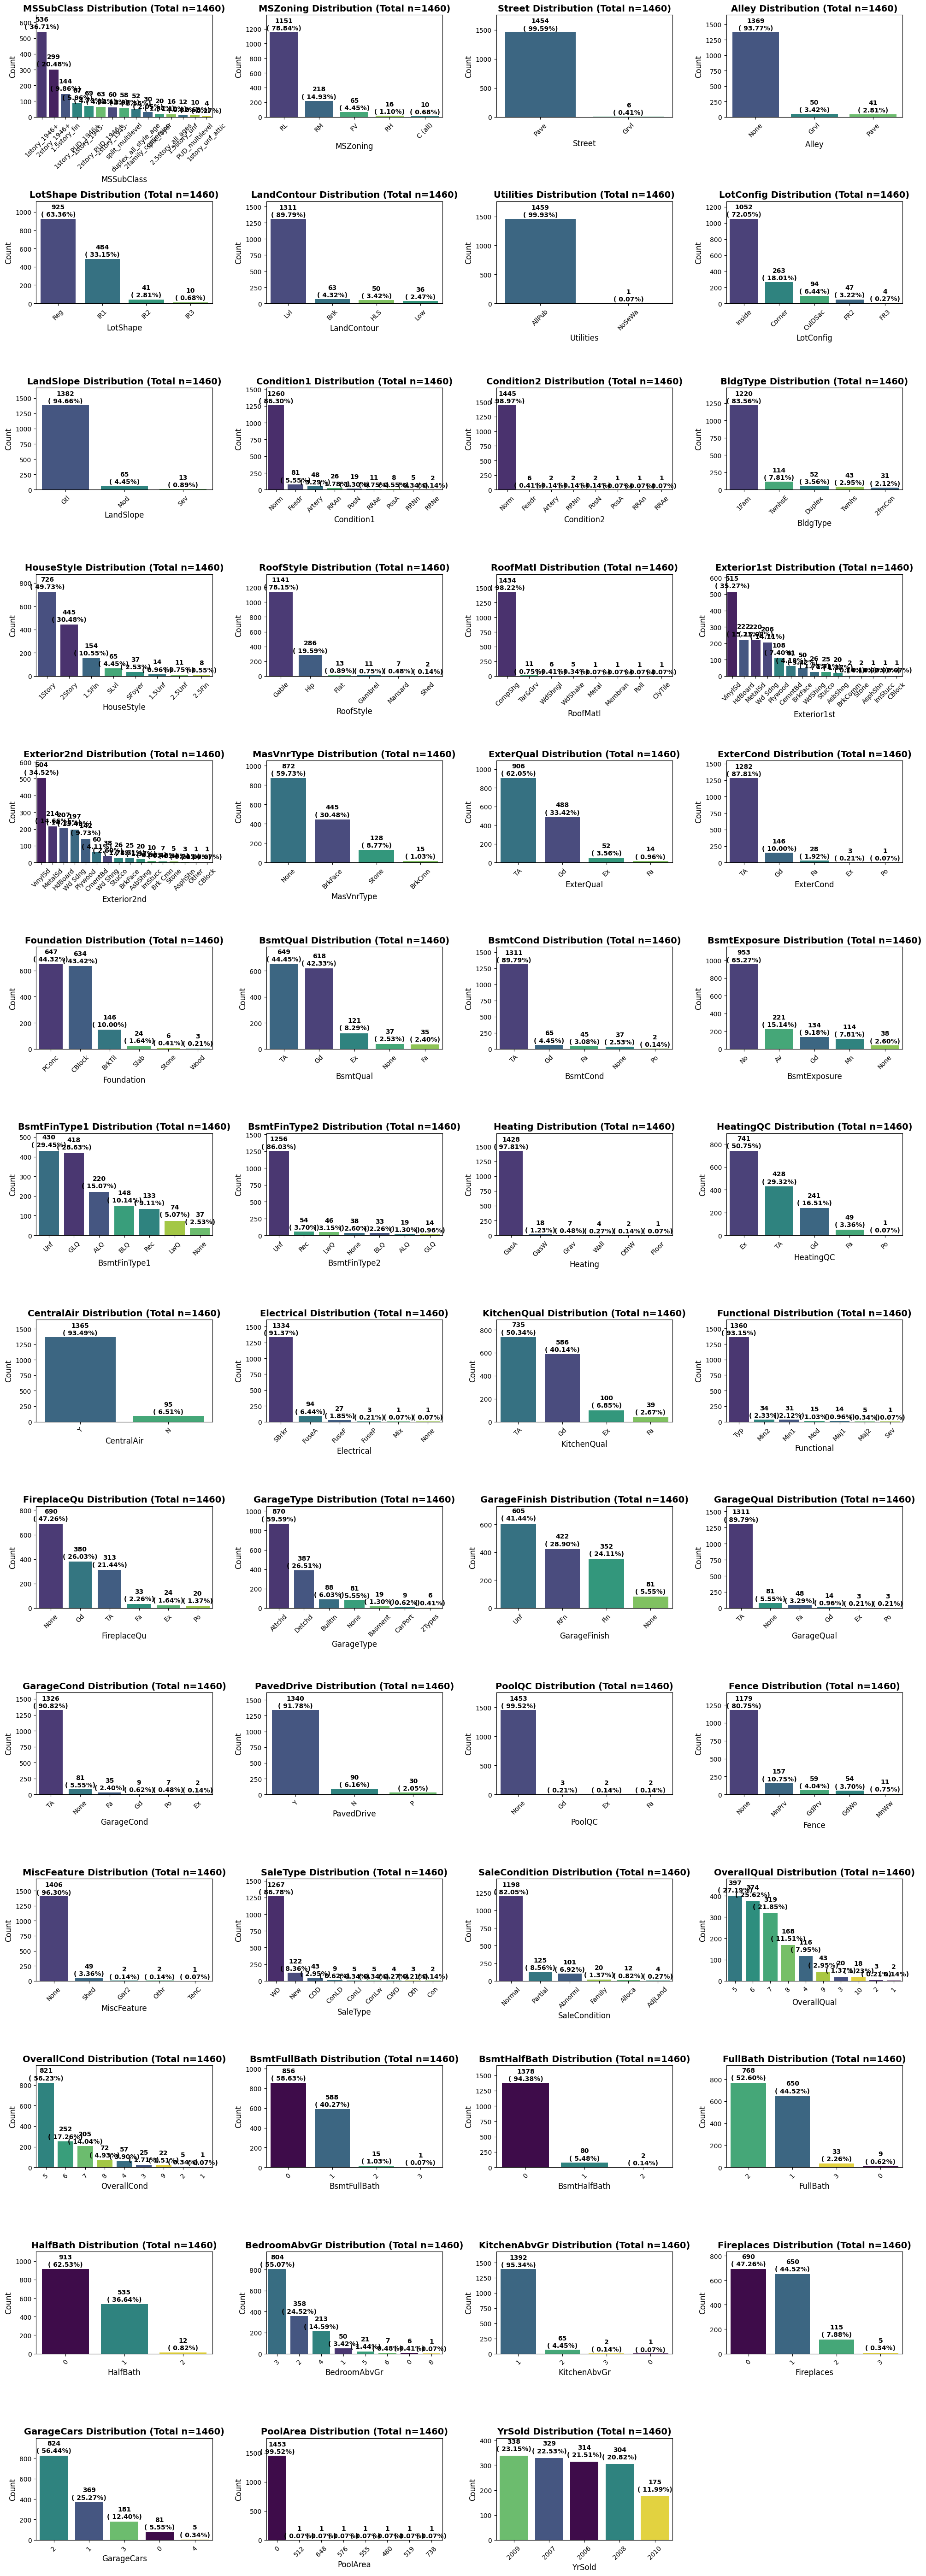

In [6]:
def cat_summary(dataframe, col_name, plot=False, ax=None):
    if dataframe[col_name].dtypes == "bool":
        dataframe[col_name] = dataframe[col_name].astype(int)
    value_counts = dataframe[col_name].value_counts(dropna=False)
    ratio = 100 * value_counts / len(dataframe)
    summary_df = pd.DataFrame({
        col_name: value_counts,
        "Ratio:%": ratio.round(2)
    })
    n_missing = dataframe[col_name].isnull().sum()
    #print(f"\n{'#'*50}")
    #print(f"Column: {col_name}")
    #print(f"{'#'*50}")
    #print(summary_df,"\n")
    if n_missing > 0:
        #print(f"Column: {col_name} has missing rate: {n_missing} ({100*n_missing/len(dataframe):.2f}%)\n")
        pass
    if plot:
        plot_data = dataframe[[col_name]].copy()
        plot_data[col_name] = plot_data[col_name].fillna("None")
        order = plot_data[col_name].value_counts().index
        
        if ax is None:
            plt.figure(figsize=(12, 6))
            ax = plt.gca()
        
        sns.countplot(x=col_name, data=plot_data, order=order, hue=col_name, palette="viridis", legend=False, ax=ax)
        total = len(plot_data)
        for p in ax.patches:
            height = p.get_height()
            pct = 100 * height / total
            ax.annotate(f"{int(height)}\n({pct: .2f}%)",
                       (p.get_x() + p.get_width() / 2., height + total * 0.01),
                       ha="center", va="bottom", fontsize=10, fontweight="bold")
        ax.set_title(f"{col_name} Distribution (Total n={total})", fontsize=14, fontweight="bold")
        ax.set_xlabel(col_name, fontsize=12)
        ax.set_ylabel("Count", fontsize=12)
        ax.tick_params(axis="x", rotation=45)
        ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
        
        if ax is None:
            plt.tight_layout()
            plt.show(block=True)

# Display all graphs in a single plot
def plot_all_categories(dataframe, cat_cols, cols_per_row=4, save=False, filename="cat_summary.png"):
    n_cols = len(cat_cols)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(5*cols_per_row, 4*n_rows))
    axes = axes.flatten()
    
    for idx, col in enumerate(cat_cols):
        cat_summary(dataframe, col, plot=True, ax=axes[idx])
    
    for idx in range(n_cols, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    
    if save:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"✓ Grafik kaydedildi: {filename}")
    
    plt.show()

plot_all_categories(df, cat_cols)  # Don"t save
# plot_all_categories(df, cat_cols, save=True)  # Save with default name
# plot_all_categories(df, cat_cols, save=True, filename="analyze.png")  # Save with special name

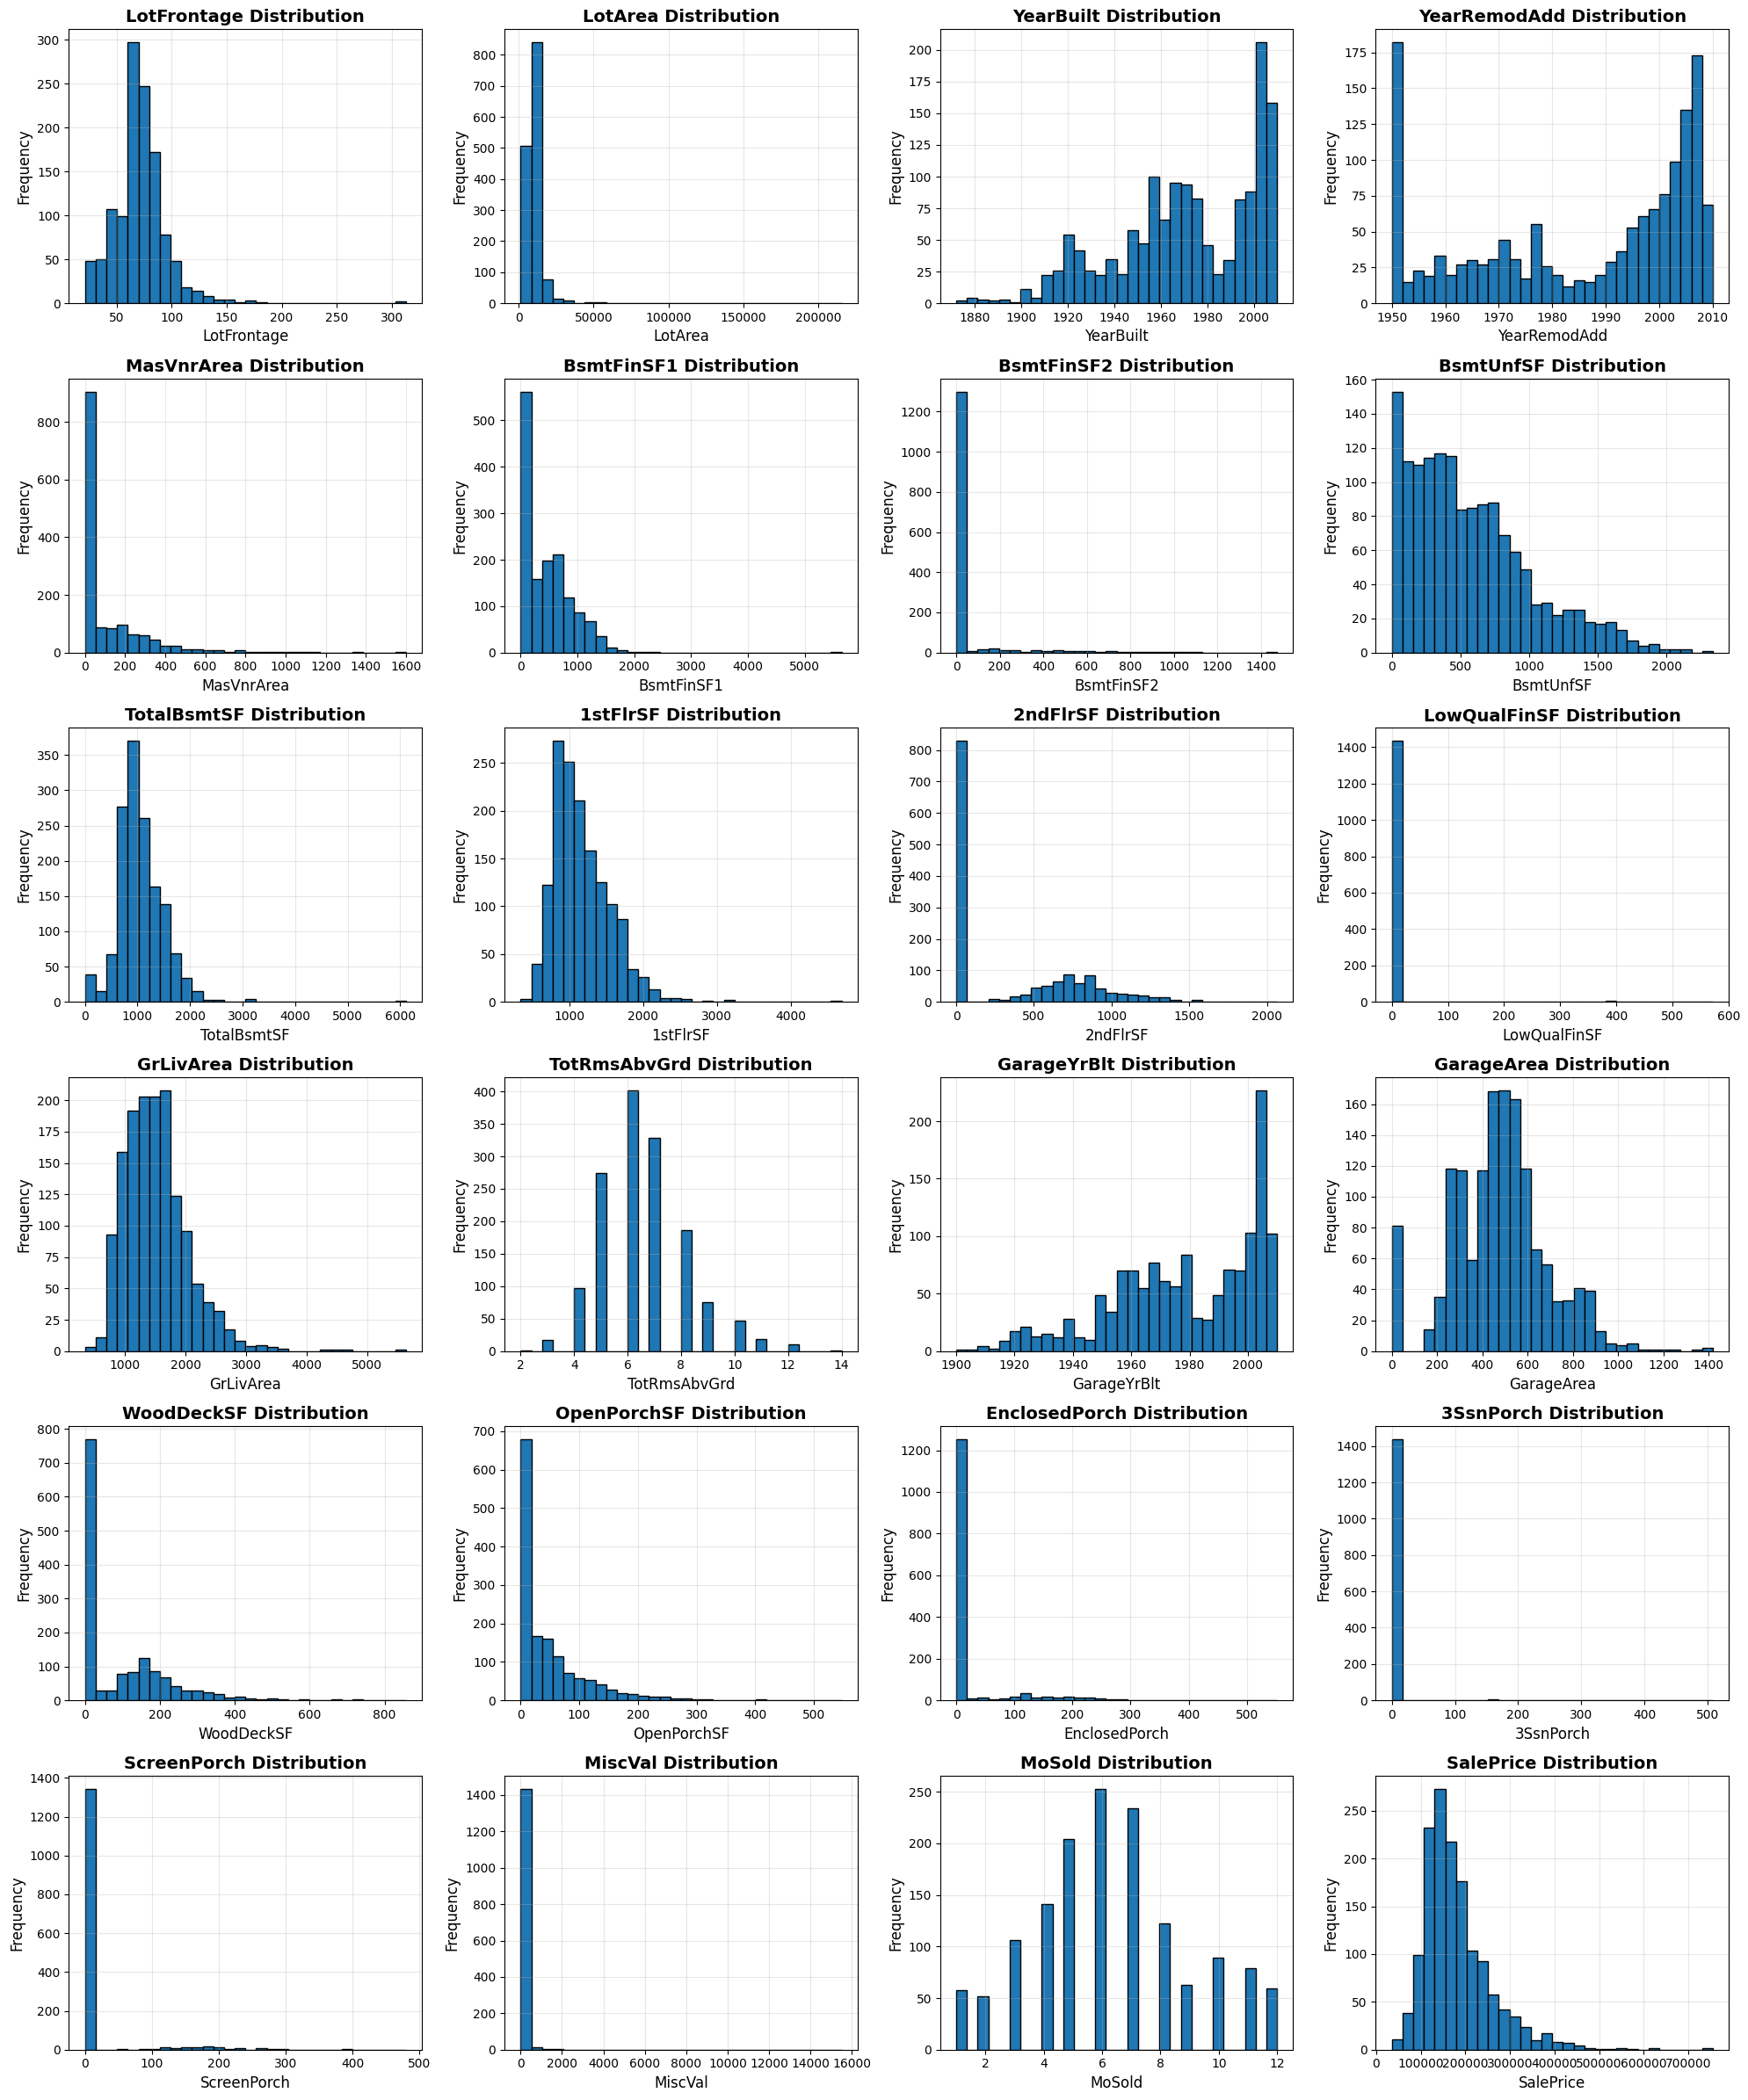

In [7]:
def num_summary(dataframe, numerical_col, plot=False, ax=None):
    missing_count = dataframe[numerical_col].isna().sum()
    missing_pct = 100 * missing_count / len(dataframe)
    #print("#######################################################")
    #print(f"Column: {numerical_col} \nMissing Value Count: {missing_count} \nMissing Value Percentage: {missing_pct:.2f}%\n")
    #quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    #print(dataframe[numerical_col].describe(quantiles).T, "\n")
    
    if plot:
        if ax is None:
            plt.figure(figsize=(10, 6))
            ax = plt.gca()
        
        dataframe[numerical_col].hist(ax=ax, bins=30, edgecolor="black")
        ax.set_xlabel(numerical_col, fontsize=12)
        ax.set_ylabel("Frequency", fontsize=12)
        ax.set_title(f"{numerical_col} Distribution", fontsize=14, fontweight="bold")
        ax.grid(alpha=0.3)
        
        if ax is None:
            plt.tight_layout()
            plt.show(block=True)

# Display all graphs in a single plot
def plot_all_numerical(dataframe, num_cols, cols_per_row=4, save=False, filename="num_summary.png"):
    n_cols = len(num_cols)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(5*cols_per_row, 4*n_rows))
    axes = axes.flatten()
    
    for idx, col in enumerate(num_cols):
        num_summary(dataframe, col, plot=True, ax=axes[idx])
    
    # Hide unused subplots
    for idx in range(n_cols, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    
    if save:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"The graph has been saved: {filename}")
    
    plt.show()

plot_all_numerical(df, num_cols)  # Don't save
# plot_all_numerical(df, num_cols, save=True)  # Save with default name
# plot_all_numerical(df, num_cols, cols_per_row=3, save=True, filename="numerical_analysis.png")  # Save with special name

In [8]:
def target_summary_with_cat(dataframe, target, categorical_col):
    """
    Displays the target mean for each class of the categorical variable (including NaN).
    
    Parameters
    ----------
    dataframe : pd.DataFrame
        The dataframe to analyze the relationship between the categorical feature and the target feature.
    target : str
        Target feature ('SalePrice')
    categorical_col : str
        Categorical feature
    
    Examples
    --------
    target_summary_with_cat(df, "SalePrice", "PoolQC")
    """
    # Temporarily fill NaNs with ‘None’ (without altering the original data)
    temp_cat_col = dataframe[categorical_col].fillna("None")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = pd.DataFrame({
            "COUNT": temp_cat_col.value_counts(),
            "RATIO": 100 * temp_cat_col.value_counts() / len(dataframe),
            "TARGET_MEAN": dataframe.groupby(temp_cat_col)[target].mean(),
            "TARGET_MEDIAN": dataframe.groupby(temp_cat_col)[target].median()
        }).sort_values("TARGET_MEAN", ascending=False)
    print(f"\n{'='*70}")
    print(f"{categorical_col} → {target}")
    print(f"{'='*70}")
    print(result, "\n")

# For categorical variables (NaN values will appear as None)
for col in cat_cols:
    target_summary_with_cat(df, "SalePrice", col)


MSSubClass → SalePrice
                      COUNT  RATIO  TARGET_MEAN  TARGET_MEDIAN
MSSubClass                                                    
2story_1946+            299 20.479   239948.502     215200.000
1story_PUD_1946+         87  5.959   200779.080     192000.000
2.5story_all_ages        16  1.096   192437.500     163500.000
1story_1946+            536 36.712   185224.812     159250.000
split_multilevel         58  3.973   169736.552     166500.000
2story_1945-             60  4.110   166772.417     156000.000
1story_unf_attic          4  0.274   156125.000     142500.000
split_foyer              20  1.370   147810.000     140750.000
1.5story_fin            144  9.863   143302.972     132000.000
2story_PUD_1946+         63  4.315   138647.381     146000.000
duplex_all_style_age     52  3.562   133541.077     135980.000
2family_conversion       30  2.055   129613.333     128250.000
1.5story_unf             12  0.822   108591.667     107500.000
PUD_multilevel           10  0.

In [9]:
# For cardinal categorical variables (NaN values will appear as None)
for col in cat_but_car:
    target_summary_with_cat(df, "SalePrice", col)


Neighborhood → SalePrice
              COUNT  RATIO  TARGET_MEAN  TARGET_MEDIAN
Neighborhood                                          
NoRidge          41  2.808   335295.317     301500.000
NridgHt          77  5.274   316270.623     315000.000
StoneBr          25  1.712   310499.000     278000.000
Timber           38  2.603   242247.447     228475.000
Veenker          11  0.753   238772.727     218000.000
Somerst          86  5.890   225379.837     225500.000
ClearCr          28  1.918   212565.429     200250.000
Crawfor          51  3.493   210624.725     200624.000
CollgCr         150 10.274   197965.773     197200.000
Blmngtn          17  1.164   194870.882     191000.000
Gilbert          79  5.411   192854.506     181000.000
NWAmes           73  5.000   189050.068     182900.000
SawyerW          59  4.041   186555.797     179900.000
Mitchel          49  3.356   156270.122     153500.000
NAmes           225 15.411   145847.080     140000.000
NPkVill           9  0.616   142694.444

In [10]:
def target_summary_with_num(dataframe, target, numerical_col):
    """
    It displays the numerical variable statistics for the target variable across different groups.
    
    Parameters
    ----------
    dataframe : pd.DataFrame
        The dataframe to analyze the relationship between the numerical feature and the target feature.
    target : str
        Target variable ('SalePrice')
    numerical_col : str
        Numerical variable
    
    Examples
    --------
    target_summary_with_num(df, "SalePrice", "OverallQual")
    """
    # Categorise the target (divide into quartiles)
    target_bins = pd.qcut(dataframe[target], q=4, labels=["Q1_Low", "Q2_Medium", "Q3_High", "Q4_VeryHigh"])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = dataframe.groupby(target_bins)[numerical_col].agg([
            ('MEAN', 'mean'),
            ('MEDIAN', 'median'),
            ('STD', 'std'),
            ('MIN', 'min'),
            ('MAX', 'max')
        ]).round(2)
    
    print(f"\n{'='*70}")
    print(f"{numerical_col} by {target} Quartiles")
    print(f"{'='*70}")
    print(result)
    print()

# For numerical variables
for col in num_cols:
    target_summary_with_num(df, "SalePrice", col)


LotFrontage by SalePrice Quartiles
              MEAN  MEDIAN    STD    MIN     MAX
SalePrice                                       
Q1_Low      60.020  60.000 19.070 21.000 153.000
Q2_Medium   67.560  70.000 23.700 24.000 313.000
Q3_High     70.640  70.000 21.560 24.000 152.000
Q4_VeryHigh 83.130  81.000 26.540 30.000 313.000


LotArea by SalePrice Quartiles
                 MEAN    MEDIAN       STD   MIN     MAX
SalePrice                                              
Q1_Low       7753.970  7910.000  3159.390  1300   25339
Q2_Medium    9510.000  9000.000  5343.440  1950   63887
Q3_High     10117.840  9559.000  4800.690  2117   40094
Q4_VeryHigh 14726.720 11775.500 17710.040  3196  215245


YearBuilt by SalePrice Quartiles
                MEAN   MEDIAN    STD   MIN   MAX
SalePrice                                       
Q1_Low      1945.330 1949.000 24.000  1872  2006
Q2_Medium   1962.890 1963.000 24.660  1890  2008
Q3_High     1984.650 1994.000 23.790  1882  2009
Q4_VeryHigh 1992.390 

Observations: 1460
Variables: 81
cat_cols: 55
num_cols: 25
cat_but_car: 1
num_but_cat: 12


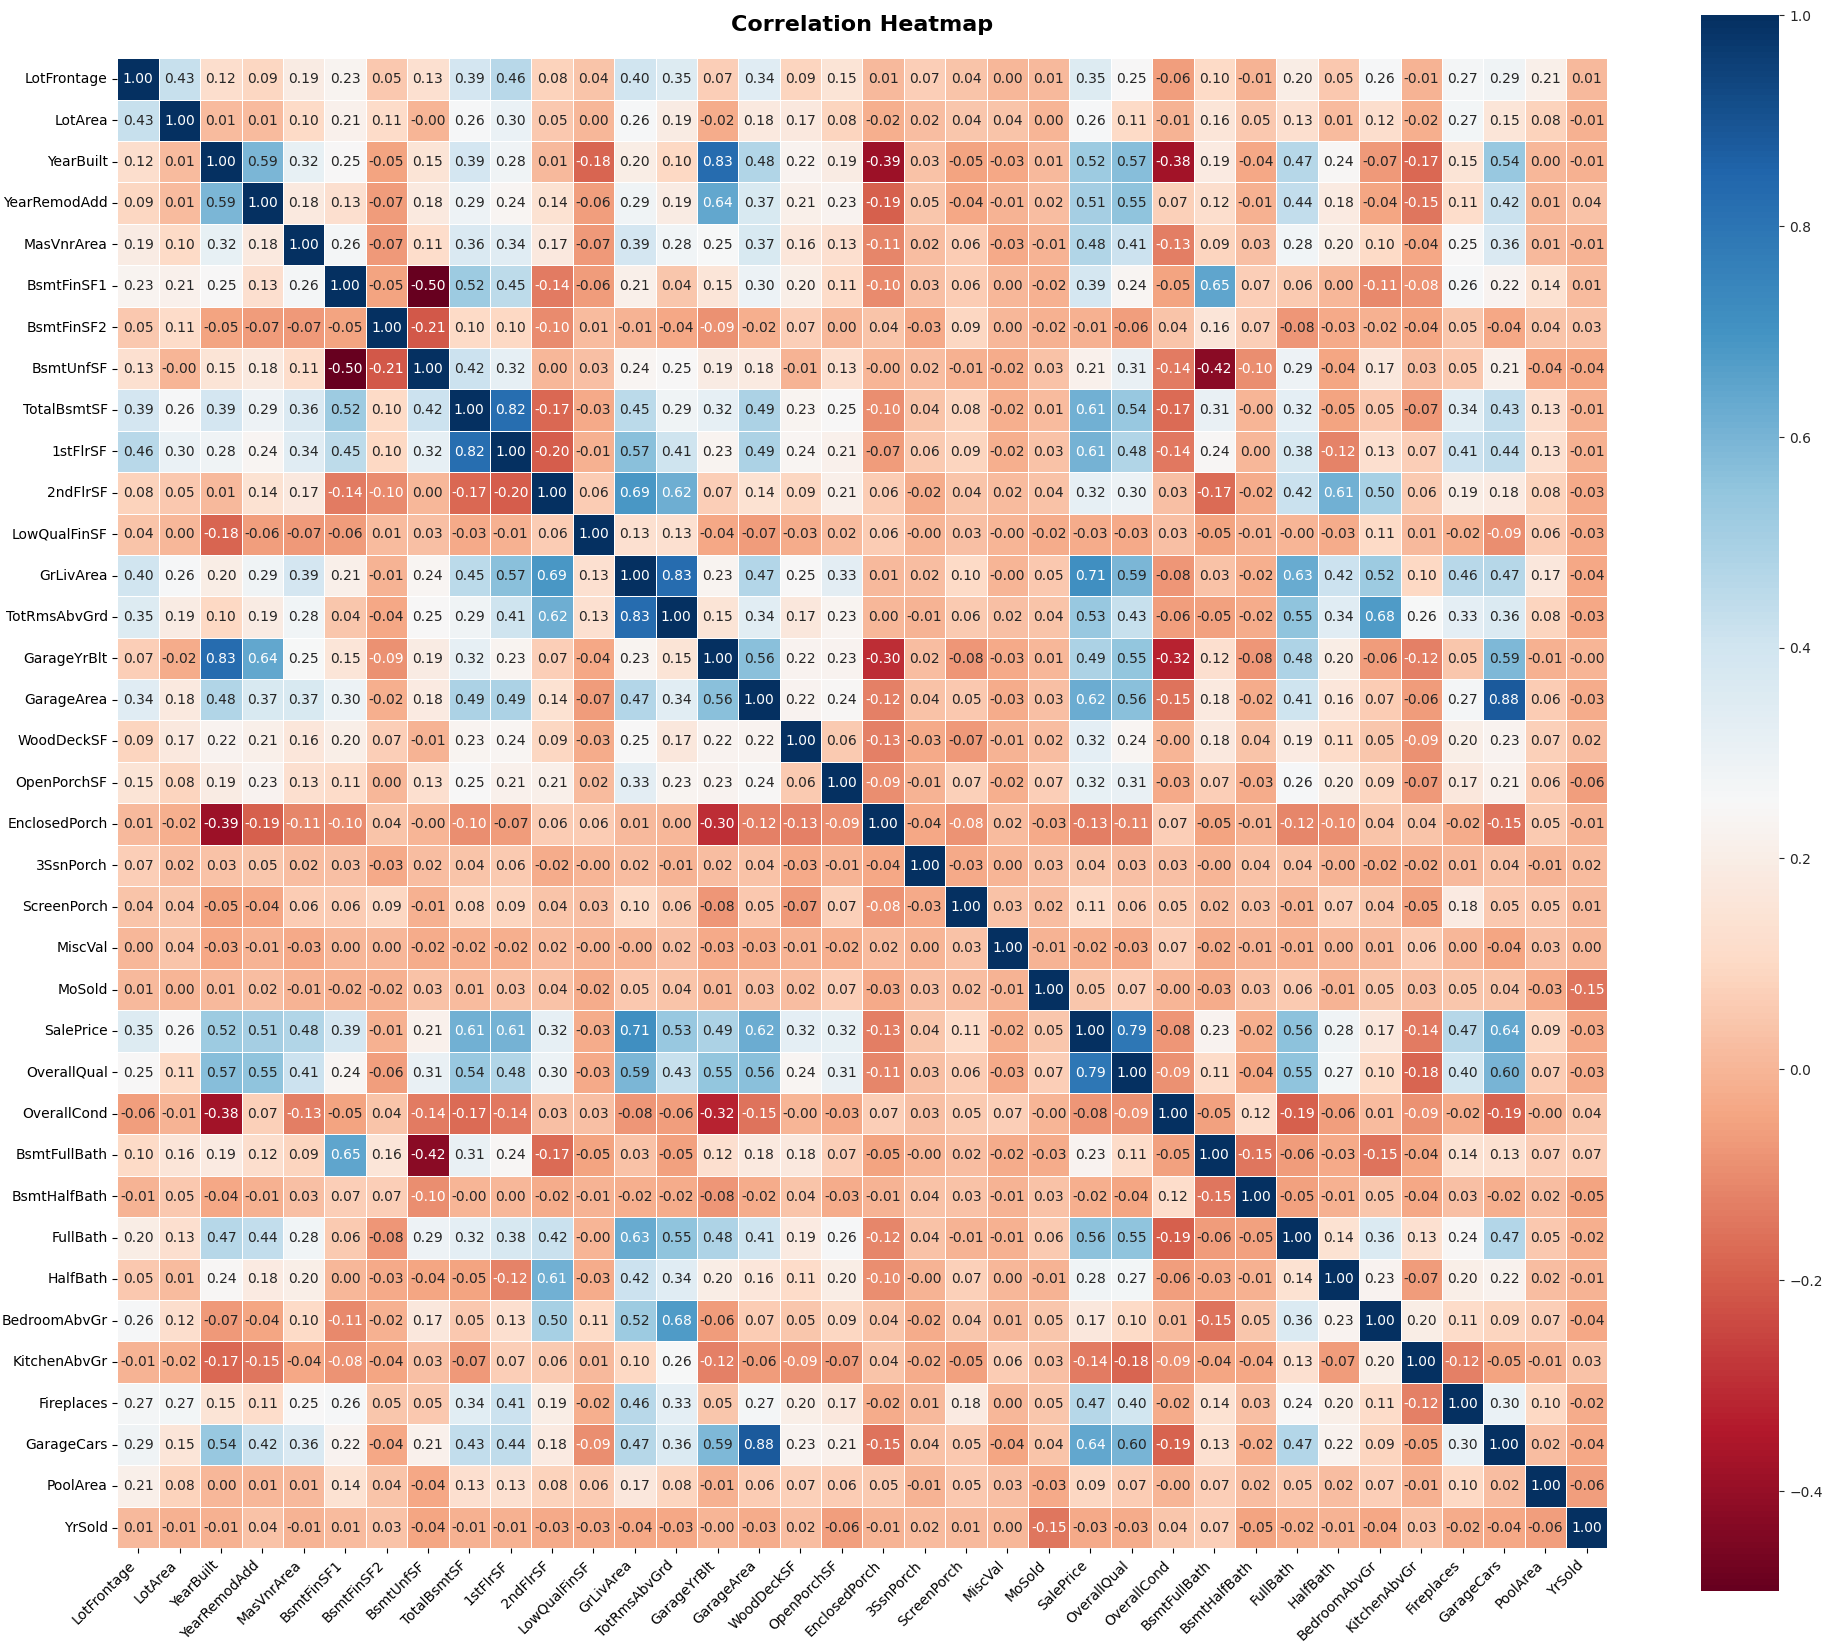

(<Figure size 2000x2000 with 2 Axes>,
 <Axes: title={'center': 'Correlation Heatmap'}>,
                LotFrontage  LotArea  YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFinSF2  BsmtUnfSF  TotalBsmtSF  1stFlrSF  2ndFlrSF  LowQualFinSF  GrLivArea  TotRmsAbvGrd  GarageYrBlt  GarageArea  WoodDeckSF  OpenPorchSF  EnclosedPorch  3SsnPorch  ScreenPorch  MiscVal  MoSold  SalePrice  OverallQual  OverallCond  BsmtFullBath  BsmtHalfBath  FullBath  HalfBath  BedroomAbvGr  KitchenAbvGr  Fireplaces  GarageCars  PoolArea  YrSold
 LotFrontage          1.000    0.426      0.123         0.089       0.193       0.234       0.050      0.133        0.392     0.457     0.080         0.038      0.403         0.352        0.070       0.345       0.089        0.152          0.011      0.070        0.041    0.003   0.011      0.352        0.252       -0.059         0.101        -0.007     0.199     0.054         0.263        -0.006       0.267       0.286     0.206   0.007
 LotArea              0.426 

In [11]:
def plot_correlation_heatmap(dataframe, 
                             columns=None, 
                             figsize=(20, 20), 
                             cmap="RdBu", 
                             annot_format=".2f", 
                             save=False, 
                             filename="heatmap.png", 
                             title=None):
    """
    Plots a correlation heatmap for numerical features.
    
    Parameters:
    -----------
    dataframe : pd.DataFrame
        Input dataframe
    columns : list, optional
        List of columns to include. If None, uses all numeric columns
    figsize : tuple, default (20, 20)
        Figure size (width, height)
    cmap : str, default "RdBu"
        Colormap for heatmap (e.g., "RdBu", "coolwarm", "viridis")
    annot_format : str, default ".2f"
        Format for annotation values (e.g., ".2f", ".3f", ".1%")
    save : bool, default False
        Whether to save the figure
    filename : str, default "heatmap.png"
        Filename for saved figure (only used if save=True)
    title : str, optional
        Title for the plot. If None, uses default title
    
    Returns:
    --------
    tuple : (fig, ax, corr_matrix)
        Figure, axes, and correlation matrix
    """

    if columns is None:
        # Auto-detect numeric columns using grab_col_names
        _, numeric, _, numeric_but_cat = grab_col_names(dataframe)

        # Remove Id column
        numeric = [col for col in numeric if col != "Id"]

        # Include numeric but categorical columns
        columns = numeric + numeric_but_cat

    # Calculate correlation matrix
    corr_matrix = dataframe[columns].corr()

    # Plot
    fig, ax, = plt.subplots(figsize=figsize)

    with sns.axes_style("darkgrid"):
        sns.heatmap(corr_matrix,
                    annot=True,
                    fmt=annot_format,
                    cmap=cmap,
                    square=True,
                    linewidths=0.5,
                    cbar_kws={"shrink": 0.8},
                    ax=ax
                    )
    
    if title is None:
        title = "Correlation Heatmap"
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"The heatmap has been saved: {filename}")

    plt.show()

    return fig, ax, corr_matrix

plot_correlation_heatmap(df)

In [12]:
_cramers_v_cache = {}

def cramers_v(x, y):
    """
    Calculate Cramér's V statistic for categorical-categorical association.
    Calculate Cramér's V statistic with manual caching.

    Cramér's V is a measure of association between two nominal variables,
    giving a value between 0 and 1 (inclusive).
    - 0.0-0.1: No or very weak association
    - 0.1-0.3: Weak association
    - 0.3-0.5: Moderate association
    - 0.5-0.7: Strong association
    - 0.7-1.0: Very strong association
    
    Parameters
    ----------
    x : pd.Series
        First categorical variable
    y : pd.Series
        Second categorical variable
    
    Returns
    -------
    float
        Cramér's V value (0-1)
    
    Examples
    --------
        cramers_v(df['MSZoning'], df['Neighborhood'])
    
    Notes
    -----
        Uses bias correction for better accuracy with small samples.
    """
    # Create cache key: use column names (memory efficient)
    cache_key = (x.name, y.name) if hasattr(x, 'name') and hasattr(y, 'name') else None
    
    # If in cache, return directly
    if cache_key and cache_key in _cramers_v_cache:
        return _cramers_v_cache[cache_key]
    
    # Otherwise calculate
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    result = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
    
    # Cache the result
    if cache_key:
        _cramers_v_cache[cache_key] = result
        # Also cache the reverse key (symmetric matrix)
        _cramers_v_cache[(y.name, x.name)] = result
    
    return result

def categorical_correlation_matrix(dataframe, cat_cols):
    """
    Create a correlation matrix for categorical variables using Cramér's V.
    
    Parameters
    ----------
    dataframe : pd.DataFrame
        The dataframe containing categorical variables
    cat_cols : list
        List of categorical column names
    
    Returns
    -------
    pd.DataFrame
        Correlation matrix with Cramér's V values (0-1)
    
    Examples
    --------
        cat_corr = categorical_correlation_matrix(df, cat_cols)
        display(cat_corr)
    
    Notes
    -----
        - NaN values are temporarily filled with "None" for calculation
        - Returns a symmetric matrix (V(X,Y) = V(Y,X))
        - Diagonal values are 1.0 (perfect correlation with itself)
    """
    # Temporarily fill NaN values with "None"
    df_temp = dataframe[cat_cols].fillna("None")

    # Initialize correlation matrix
    n = len(cat_cols)
    corr_matrix = pd.DataFrame(np.zeros((n, n)), index=cat_cols, columns=cat_cols)
    print("="*70)
    print("CALCULATING CRAMÉR'S V CORRELATION MATRIX")
    print("="*70)
    print(f"Number of categorical variables: {n}")
    print(f"Total pairs to calculate: {n*(n-1)//2}\n")

    # Calculate Cramer's V for each pair
    for i, col1 in enumerate(cat_cols):
        for j, col2 in enumerate(cat_cols):
            if i == j:
                corr_matrix.loc[col1, col2] = 1.0 # Perfect correlation with itself
            elif i < j: # Calculate only upper triangle (symmetric matrix)
                try:
                    v = cramers_v(df_temp[col1], df_temp[col2])
                    corr_matrix.loc[col1, col2] = v
                    corr_matrix.loc[col2, col1] = v # Symmetric
                except Exception as e:
                    print(f"Warning: Could not calculate for {col1} x {col2}: {str(e)}")
                    corr_matrix.loc[col1, col2] = 0
                    corr_matrix.loc[col2, col1] = 0

    print("Correlation matrix calculated successfully!")
    print("="*70, "\n")
    
    return corr_matrix

CALCULATING CRAMÉR'S V CORRELATION MATRIX
Number of categorical variables: 55
Total pairs to calculate: 1485

Correlation matrix calculated successfully!


Categorical Correlation Matrix:


,MSSubClass,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition,OverallQual,OverallCond,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,Fireplaces,GarageCars,PoolArea,YrSold
MSSubClass,1.000,0.337,0.092,0.305,0.164,0.140,0.000,0.079,0.087,0.111,0.157,0.891,0.848,0.217,0.080,0.193,0.203,0.228,0.285,0.167,0.359,0.334,0.199,0.262,0.233,0.142,0.150,0.239,0.434,0.162,0.283,0.097,0.188,0.331,0.383,0.235,0.212,0.309,0.093,0.131,0.179,0.090,0.152,0.202,0.190,0.239,0.084,0.313,0.533,0.338,0.494,0.220,0.295,0.073,0.000
MSZoning,0.337,1.000,0.249,0.389,0.152,0.102,0.000,0.064,0.072,0.071,0.059,0.189,0.184,0.073,0.000,0.178,0.186,0.098,0.239,0.079,0.224,0.165,0.079,0.064,0.134,0.038,0.055,0.117,0.297,0.100,0.174,0.000,0.119,0.211,0.194,0.126,0.102,0.218,0.000,0.025,0.000,0.151,0.136,0.190,0.161,0.071,0.020,0.175,0.140,0.165,0.091,0.136,0.144,0.000,0.000
Street,0.092,0.249,1.000,0.000,0.034,0.114,0.000,0.000,0.176,0.165,0.000,0.112,0.019,0.000,0.000,0.000,0.000,0.000,0.321,0.000,0.044,0.000,0.000,0.087,0.000,0.105,0.000,0.018,0.040,0.000,0.062,0.000,0.000,0.223,0.000,0.000,0.000,0.000,0.000,0.000,0.158,0.111,0.099,0.073,0.068,0.091,0.000,0.022,0.000,0.000,0.000,0.059,0.027,0.000,0.035
Alley,0.305,0.389,0.000,1.000,0.080,0.071,0.000,0.035,0.000,0.126,0.000,0.154,0.142,0.108,0.000,0.207,0.201,0.092,0.109,0.043,0.222,0.131,0.076,0.083,0.112,0.000,0.123,0.087,0.201,0.128,0.094,0.034,0.073,0.198,0.140,0.124,0.141,0.179,0.000,0.000,0.000,0.036,0.065,0.102,0.117,0.063,0.000,0.069,0.044,0.132,0.000,0.074,0.084,0.000,0.000
LotShape,0.164,0.152,0.034,0.080,1.000,0.127,0.000,0.221,0.119,0.105,0.000,0.084,0.073,0.035,0.186,0.082,0.093,0.068,0.112,0.000,0.117,0.140,0.058,0.105,0.064,0.065,0.025,0.053,0.108,0.110,0.092,0.000,0.122,0.143,0.141,0.076,0.051,0.075,0.094,0.030,0.000,0.000,0.002,0.116,0.060,0.094,0.045,0.102,0.084,0.033,0.037,0.141,0.120,0.174,0.000
LandContour,0.140,0.102,0.114,0.071,0.127,1.000,0.000,0.060,0.457,0.000,0.059,0.069,0.126,0.141,0.181,0.116,0.121,0.088,0.134,0.000,0.100,0.093,0.061,0.192,0.087,0.000,0.000,0.054,0.128,0.045,0.097,0.000,0.075,0.116,0.102,0.037,0.000,0.116,0.000,0.032,0.000,0.030,0.107,0.161,0.101,0.105,0.027,0.111,0.003,0.110,0.000,0.066,0.090,0.021,0.000
Utilities,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.085,0.000,0.000,0.000,0.000,0.100,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.117,0.000,0.027,0.000,0.081,0.000,0.000,0.000,0.219,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.131,0.076,0.000,0.000,0.000,0.102,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
LotConfig,0.079,0.064,0.000,0.035,0.221,0.060,0.085,1.000,0.079,0.148,0.092,0.069,0.000,0.075,0.077,0.052,0.076,0.000,0.014,0.000,0.043,0.070,0.003,0.053,0.053,0.000,0.000,0.010,0.063,0.000,0.000,0.000,0.049,0.057,0.032,0.015,0.052,0.029,0.023,0.000,0.000,0.000,0.034,0.017,0.000,0.000,0.034,0.041,0.000,0.000,0.041,0.049,0.044,0.015,0.031
LandSlope,0.087,0.072,0.176,0.000,0.119,0.457,0.000,0.079,1.000,0.000,0.000,0.026,0.000,0.256,0.313,0.134,0.116,0.047,0.094,0.000,0.050,0.000,0.133,0.222,0.042,0.076,0.000,0.050,0.000,0.000,0.045,0.075,0.032,0.109,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.038,0.152,0.188,0.200,0.045,0.124,0.041,0.100,0.000,0.154,0.033,0.000,0.000
Condition1,0.111,0.071,0.165,0.126,0.105,0.000,0.000,0.148,0.000,1.000,0.210,0.076,0.085,0.081,0.077,0.072,0.079,0.046,0.125,0.019,0.080,0.131,0.040,0.064,0.046,0.024,0.000,0.157,0.040,0.015,0.083,0.000,0.000,0.089,0.121,0.029,0.030,0.103,0.069,0.031,0.075,0.034,0.000,0.061,0.051,0.000,0.000,0.062,0.087,0.060,0.067,0.048,0.062,0.067,0.000


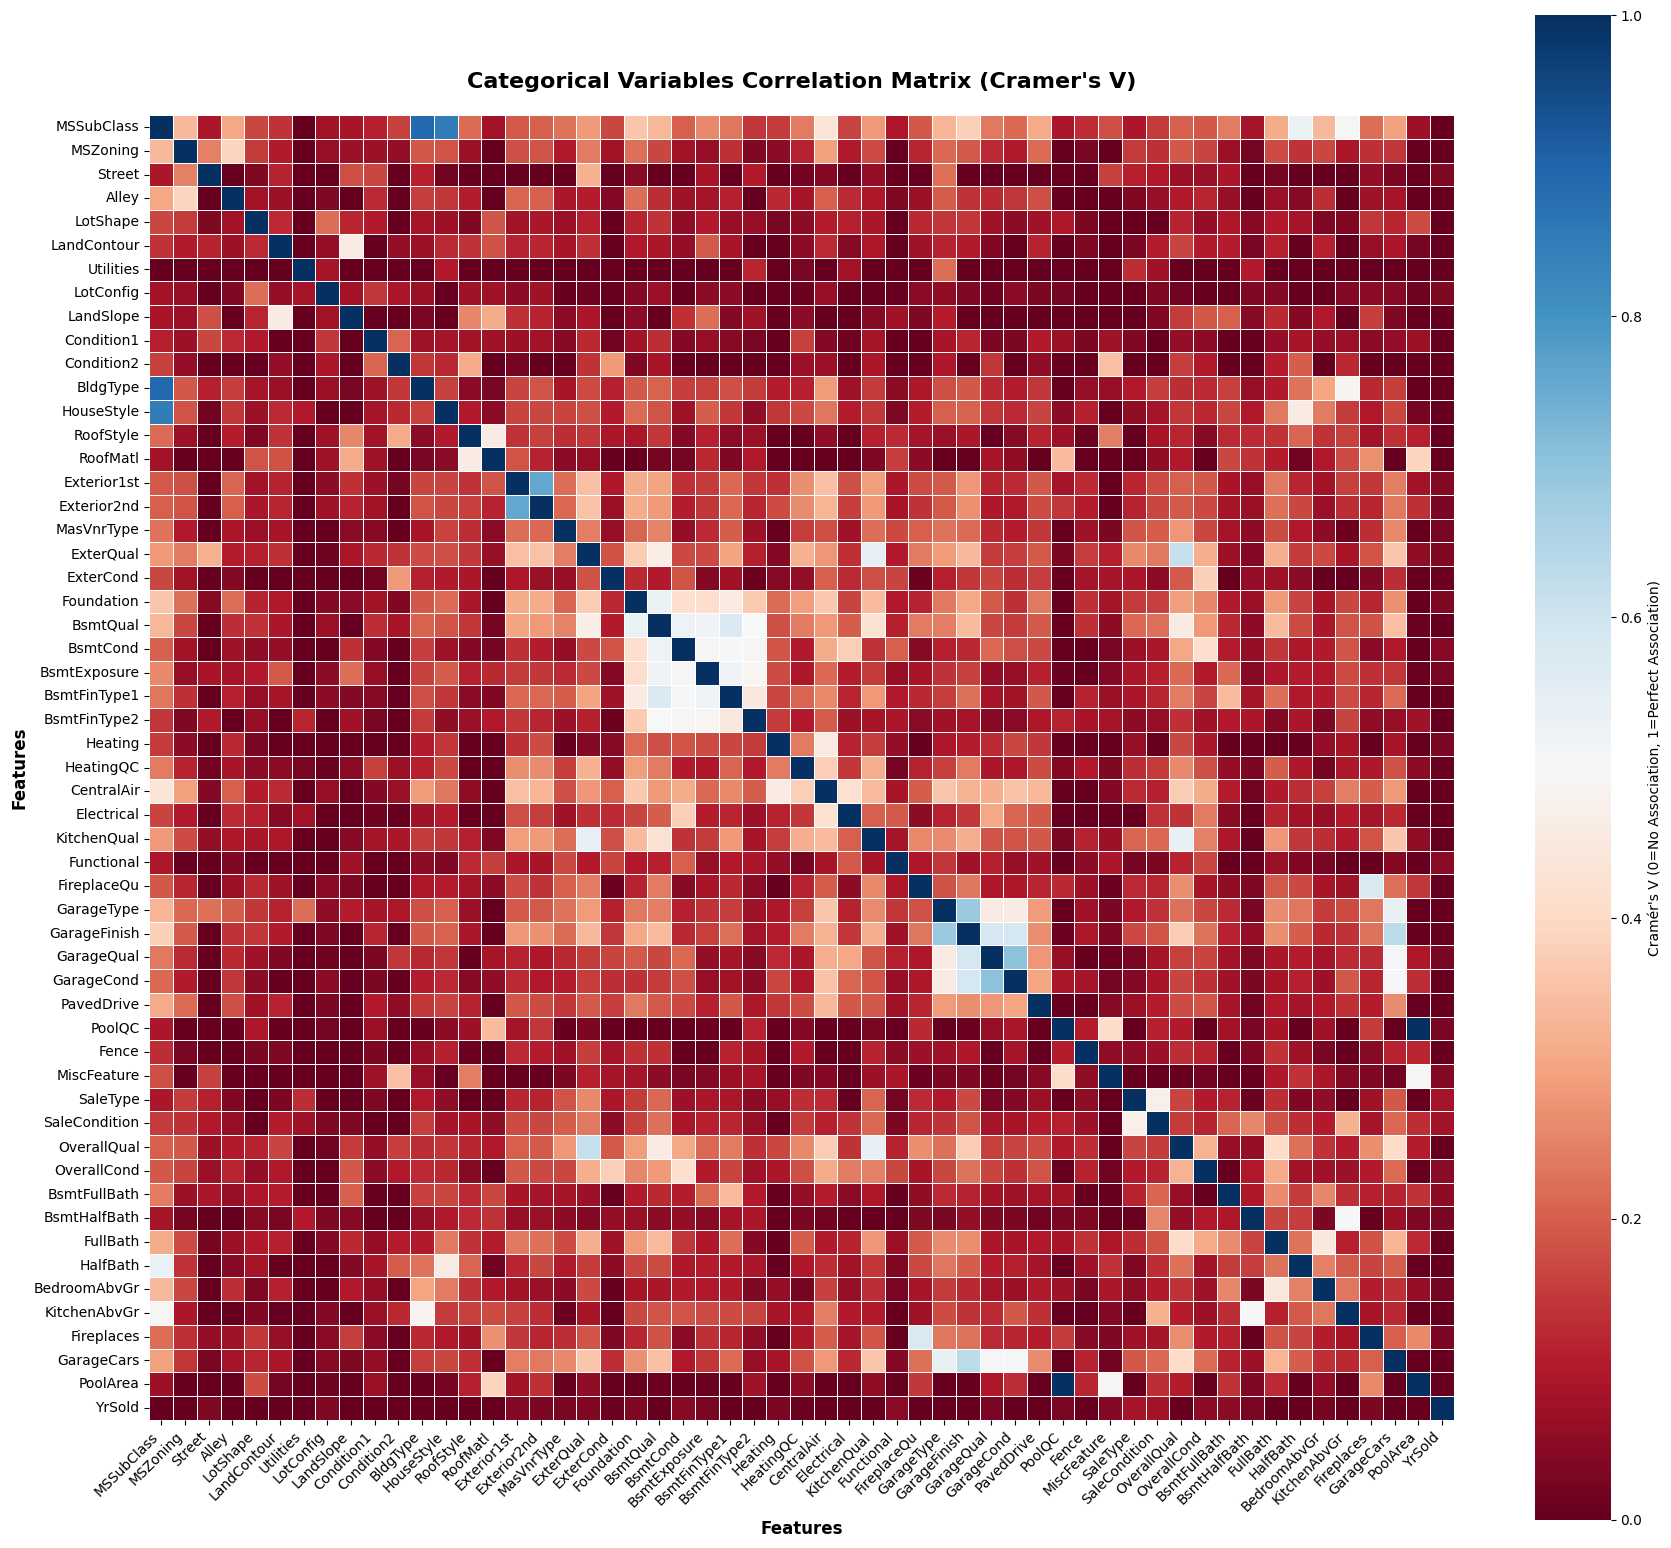


STRONGEST CATEGORICAL ASSOCIATIONS (Cramér's V)

Top 20 strongest correlations:
----------------------------------------------------------------------
 1. PoolQC               <-> PoolArea             : 0.999 (Very Strong)
 2. MSSubClass           <-> BldgType             : 0.891 (Very Strong)
 3. MSSubClass           <-> HouseStyle           : 0.848 (Very Strong)
 4. Exterior1st          <-> Exterior2nd          : 0.759 (Strong)
 5. GarageQual           <-> GarageCond           : 0.704 (Strong)
 6. GarageType           <-> GarageFinish         : 0.685 (Strong)
 7. GarageFinish         <-> GarageCars           : 0.635 (Strong)
 8. ExterQual            <-> OverallQual          : 0.614 (Strong)
 9. GarageFinish         <-> GarageQual           : 0.589 (Moderate)
10. GarageFinish         <-> GarageCond           : 0.586 (Moderate)
11. FireplaceQu          <-> Fireplaces           : 0.580 (Moderate)
12. BsmtQual             <-> BsmtFinType1         : 0.577 (Moderate)
13. ExterQual        

In [13]:
def plot_categorical_correlation_heatmap(corr_matrix, figsize=(18, 16), annot=False, save=False, filename="categorical_correlation.png"):
    """
    Plot a heatmap of categorical correlations using Cramér's V.
    
    Parameters
    ----------
    corr_matrix : pd.DataFrame
        Correlation matrix from categorical_correlation_matrix()
    figsize : tuple, optional
        Figure size (width, height), by default (18, 16)
    annot : bool, optional
        Whether to annotate cells with values, by default False
        Set to True for small matrices (<15 variables)
    save : bool, optional
        Whether to save the plot, by default False
    filename : str, optional
        Filename if saving, by default "categorical_correlation.png"
    
    Examples
    --------
        plot_categorical_correlation_heatmap(cat_corr, figsize=(20, 18), annot=False)
        plot_categorical_correlation_heatmap(cat_corr, annot=True, save=True, filename="cat_corr.png")
    
    Notes
    -----
        - Color map: YlOrRd (Yellow to Orange to Red)
        - Yellow (0.0): No association
        - Red (1.0): Perfect association
    """
    plt.figure(figsize=figsize)

    # Create heatmap
    sns.heatmap(corr_matrix,
                annot=annot,
                fmt=".2f",
                cmap="RdBu",
                square=True,
                linewidth=0.5,
                cbar_kws={"label": "Cramér's V (0=No Association, 1=Perfect Association)"},
                vmin=0,
                vmax=1
               )
    
    plt.title("Categorical Variables Correlation Matrix (Cramer's V)",
              fontsize=16, fontweight="bold", pad=20)
    plt.xlabel("Features", fontsize=12, fontweight="bold")
    plt.ylabel("Features", fontsize=12, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"Plot saved: {filename}")

    plt.show()

    # Print strongest associations
    print("\n" + "="*70)
    print("STRONGEST CATEGORICAL ASSOCIATIONS (Cramér's V)")
    print("="*70)

    # Get upper triangle only (avoid duplicates)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    strong_corr = corr_matrix.where(mask).stack().sort_values(ascending=False)
    
    print("\nTop 20 strongest correlations:")
    print("-"*70)
    for idx, (pair, value) in enumerate(strong_corr.head(20).items(), 1):
        if value > 0.8:
            strength = "Very Strong"
        elif value > 0.6:
            strength = "Strong"
        elif value > 0.4:
            strength = "Moderate"
        elif value > 0.2:
            strength = "Weak"
        else:
            strength = "Very Weak"
        
        print(f"{idx:2d}. {pair[0]:20s} <-> {pair[1]:20s} : {value:.3f} ({strength})")
    print("="*70)

# Calculate categorical correlation matrix
cat_corr = categorical_correlation_matrix(df, cat_cols)

# Display the matrix
print("\nCategorical Correlation Matrix:")
display(cat_corr)

# Plot heatmap (without annotations for better visualization)
plot_categorical_correlation_heatmap(cat_corr, figsize=(18, 16), annot=False)

# Optional: Plot with annotations (if you have few variables)
# plot_categorical_correlation_heatmap(cat_corr, figsize=(20, 18), annot=True)

# Optional: Save the plot
# plot_categorical_correlation_heatmap(cat_corr, save=True, filename="house_prices_cat_correlation.png")

In [14]:
def analyze_missing_values(dataframe, plot=True):
    """
    Analyzes missing values in the dataframe and displays detailed information.
    
    Parameters
    ----------
        dataframe: pandas.DataFrame
            The dataframe to analyze for missing values.
        plot: bool, optional
            Whether to display a visual plot of missing values using missingno library.
    
    Returns
    -------
        missing_df: pandas.DataFrame
            A dataframe with columns: Missing_Count, Missing_Percentage, sorted by percentage.
    
    Examples
    --------
        missing_info = analyze_missing_values(df)
        display(missing_info)
    """
    
    missing_counts = dataframe.isnull().sum()
    missing_pct = 100 * missing_counts / len(dataframe)
    
    missing_df = pd.DataFrame({
        "Missing_Count": missing_counts,
        "Missing_Percentage": missing_pct
    })
    
    missing_df = missing_df[missing_df["Missing_Count"] > 0].sort_values(
        by="Missing_Percentage", ascending=False
    )
    
    print("="*70)
    print("MISSING VALUES ANALYSIS")
    print("="*70)
    print(f"\nTotal rows: {len(dataframe)}")
    print(f"Columns with missing values: {len(missing_df)}/{len(dataframe.columns)}")
    print(f"Total missing values: {missing_df['Missing_Count'].sum()}")
    
    if len(missing_df) > 0:
        print("\nMissing Values Summary:")
        display(missing_df)
        
        if plot:
            plt.figure(figsize=(20, 10))
            msno.matrix(dataframe)
            plt.title("Missing Values Matrix", fontsize=16, fontweight="bold")
            plt.show()
    else:
        print("\nNo missing values found in the dataset!")
        
    return missing_df

In [15]:
def create_missing_value_handler(train_df):
    """
    Creates a missing value handler that learns parameters from the training data
    and can be applied to both train and test sets.
    
    This function implements domain-specific strategies for the House Prices dataset:
    - Fills categorical NaNs with "None" (meaning "feature doesn"t exist")
    - Fills related numerical NaNs with 0
    - Uses neighborhood-based median for LotFrontage
    - Uses mode for single missing values
    
    Parameters
    ----------
        train_df: pandas.DataFrame
            The training dataframe to learn missing value parameters from.
    
    Returns
    -------
        handler_function: function
            A function that can be applied to any dataframe (train or test)
            to handle missing values using the learned parameters.
    
    Examples
    --------
        # Create handler from training data
        missing_handler = create_missing_value_handler(df)
        
        # Apply to train and test
        df_clean = missing_handler(df)
        test_clean = missing_handler(test_df)
    
    Notes
    -----
        The handler learns all parameters ONLY from the training data to prevent
        data leakage. These same parameters are then applied to test data.
    """
    
    # Learn parameters from TRAINING DATA ONLY
    params = {}
    
    # 1. LotFrontage: Neighborhood-based median (domain knowledge)
    if "LotFrontage" in train_df.columns and "Neighborhood" in train_df.columns:
        params["lot_frontage_by_neighborhood"] = train_df.groupby("Neighborhood")["LotFrontage"].median().to_dict()
        params["lot_frontage_global_median"] = train_df["LotFrontage"].median()
    
    # 2. Electrical: Mode (only 1 missing value typically)
    if "Electrical" in train_df.columns:
        params["electrical_mode"] = train_df["Electrical"].mode()[0] if len(train_df["Electrical"].mode()) > 0 else None
    
    print("="*70)
    print("MISSING VALUE HANDLER CREATED")
    print("="*70)
    print(f"\nParameters learned from training data:")
    print(f"  - LotFrontage neighborhoods tracked: {len(params.get('lot_frontage_by_neighborhood', {}))}")
    print(f"  - Electrical mode: {params.get('electrical_mode')}")
    
    def apply_handler(dataframe):
        """
        Applies missing value handling strategy to the given dataframe.
        
        Parameters
        ----------
            dataframe: pandas.DataFrame
                The dataframe to handle missing values in.
        
        Returns
        -------
            df_clean: pandas.DataFrame
                The dataframe with missing values handled.
        """
        
        df = dataframe.copy()
        
        print("\n" + "="*70)
        print("APPLYING MISSING VALUE HANDLER")
        print("="*70)
        print(f"Initial missing values: {df.isnull().sum().sum()}")
        print(f"Initial shape: {df.shape}")
        
        # STEP 1: Categorical NaN = "None" (meaning "feature doesn"t exist")
        # Basement features
        basement_cols = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]
        # Garage features
        garage_cols = ["GarageType", "GarageFinish", "GarageQual", "GarageCond"]
        # Other features
        other_categorical = ["Alley", "PoolQC", "MiscFeature", "FireplaceQu", "MasVnrType", "Fence"]
        
        all_none_cols = basement_cols + garage_cols + other_categorical
        
        filled_cat = 0
        for col in all_none_cols:
            if col in df.columns:
                missing_before = df[col].isnull().sum()
                if missing_before > 0:
                    df[col] = df[col].fillna("None")
                    filled_cat += missing_before
        
        if filled_cat > 0:
            print(f"Filled {filled_cat} categorical NaNs with 'None'")
        
        # STEP 2: Numerical NaN = 0 (related to categorical features)
        numerical_zero = {
            "MasVnrArea": "If no masonry veneer, area = 0",
            "BsmtFinSF1": "If no basement, area = 0",
            "BsmtFinSF2": "If no basement, area = 0",
            "BsmtUnfSF": "If no basement, area = 0",
            "TotalBsmtSF": "If no basement, area = 0",
            "BsmtFullBath": "If no basement, bathrooms = 0",
            "BsmtHalfBath": "If no basement, bathrooms = 0",
            "GarageCars": "If no garage, cars = 0",
            "GarageArea": "If no garage, area = 0"
        }
        
        filled_num = 0
        for col, reason in numerical_zero.items():
            if col in df.columns:
                missing_before = df[col].isnull().sum()
                if missing_before > 0:
                    df[col] = df[col].fillna(0)
                    filled_num += missing_before
        
        if filled_num > 0:
            print(f"Filled {filled_num} numerical NaNs with 0")
        
        # STEP 3: LotFrontage - Neighborhood-based median
        if "LotFrontage" in df.columns:
            missing_before = df["LotFrontage"].isnull().sum()
            if missing_before > 0:
                df["LotFrontage"] = df.apply(
                    lambda row: params["lot_frontage_by_neighborhood"].get(
                        row["Neighborhood"], 
                        params["lot_frontage_global_median"]
                    ) if pd.isna(row["LotFrontage"]) else row["LotFrontage"],
                    axis=1
                )
                print(f"Filled {missing_before} LotFrontage NaNs using neighborhood medians")

        # STEP 4: GarageYrBlt - Special handling with -1 sentinel value
        if "GarageYrBlt" in df.columns:
            missing_before = df["GarageYrBlt"].isnull().sum()
            if missing_before > 0:
                df["GarageYrBlt"] = df["GarageYrBlt"].fillna(-1)
                print(f"Filled {missing_before} GarageYrBlt NaNs with -1 (sentinel value)")
        
        # STEP 5: Electrical - Mode
        if "Electrical" in df.columns and params.get("electrical_mode"):
            missing_before = df["Electrical"].isnull().sum()
            if missing_before > 0:
                df["Electrical"] = df["Electrical"].fillna(params["electrical_mode"])
                print(f"Filled {missing_before} Electrical NaNs with mode")
        
        # FINAL CHECK
        remaining_missing = df.isnull().sum().sum()
        print(f"\n{'='*70}")
        print(f"MISSING VALUE HANDLING COMPLETE")
        print(f"{'='*70}")
        print(f"Remaining missing values: {remaining_missing}")
        print(f"Final shape: {df.shape}")
        
        if remaining_missing > 0:
            print("\nWARNING: Some missing values remain:")
            remaining = df.isnull().sum()
            display(remaining[remaining > 0].to_frame("Count"))
        
        return df
    
    return apply_handler

# Step 1: Analyze missing values in the original data
print("\nORIGINAL DATA MISSING VALUES ANALYSIS")
missing_info = analyze_missing_values(df, plot=False)

# Step 2: Create handler from training data
missing_handler = create_missing_value_handler(df)

# Step 3: Apply handler to clean the data
df_clean = missing_handler(df)

# Step 4: Verify - no more missing values (except maybe a few edge cases)
print("\n\nCLEANED DATA VERIFICATION")
final_missing = analyze_missing_values(df_clean, plot=False)

# Step 5: Update column names for cleaned data
print("\n\nUPDATING COLUMN LISTS FOR CLEANED DATA")
cat_cols_clean, num_cols_clean, cat_but_car_clean, num_but_cat_clean = grab_col_names(df_clean)
num_cols_clean = [col for col in num_cols_clean if col not in ["Id"]]

print(f"\n Data ready for outlier detection!")
print(f"   - Clean dataframe: df_clean")
print(f"   - Numerical columns: num_cols_clean (n={len(num_cols_clean)})")
print(f"   - Categorical columns: cat_cols_clean (n={len(cat_cols_clean)})")


ORIGINAL DATA MISSING VALUES ANALYSIS
MISSING VALUES ANALYSIS

Total rows: 1460
Columns with missing values: 19/81
Total missing values: 7829

Missing Values Summary:


,Missing_Count,Missing_Percentage
PoolQC,1453,99.521
MiscFeature,1406,96.301
Alley,1369,93.767
Fence,1179,80.753
MasVnrType,872,59.726
FireplaceQu,690,47.260
LotFrontage,259,17.740
GarageType,81,5.548
GarageYrBlt,81,5.548
GarageFinish,81,5.548


MISSING VALUE HANDLER CREATED

Parameters learned from training data:
  - LotFrontage neighborhoods tracked: 25
  - Electrical mode: SBrkr

APPLYING MISSING VALUE HANDLER
Initial missing values: 7829
Initial shape: (1460, 81)
Filled 7480 categorical NaNs with 'None'
Filled 8 numerical NaNs with 0
Filled 259 LotFrontage NaNs using neighborhood medians
Filled 81 GarageYrBlt NaNs with -1 (sentinel value)
Filled 1 Electrical NaNs with mode

MISSING VALUE HANDLING COMPLETE
Remaining missing values: 0
Final shape: (1460, 81)


CLEANED DATA VERIFICATION
MISSING VALUES ANALYSIS

Total rows: 1460
Columns with missing values: 0/81
Total missing values: 0

No missing values found in the dataset!


UPDATING COLUMN LISTS FOR CLEANED DATA
Observations: 1460
Variables: 81
cat_cols: 55
num_cols: 25
cat_but_car: 1
num_but_cat: 12

 Data ready for outlier detection!
   - Clean dataframe: df_clean
   - Numerical columns: num_cols_clean (n=24)
   - Categorical columns: cat_cols_clean (n=55)


In [16]:
def calculate_vif(dataframe, num_cols):
    """
    Calculate VIF (Variance Inflation Factor) for numeric features.
    
    VIF measures multicollinearity - how much a feature can be predicted 
    by other features using linear regression.
    
    VIF Interpretation:
    - VIF = 1: No correlation with other features
    - VIF < 5: Low multicollinearity
    - VIF 5-10: Moderate multicollinearity
    - VIF > 10: High multicollinearity
    - VIF = inf: Perfect multicollinearity

    Parameters
    ----------
    dataframe : pd.DataFrame
        The dataframe containing numeric variables (must have NO missing values)
    num_cols : list
        List of numeric column names
    
    Returns
    -------
    pd.DataFrame
        VIF scores sorted by VIF value (descending)
    
    Examples
    --------
        num_cols_for_vif = [col for col in num_cols_clean if col != "SalePrice"]
        vif_results = calculate_vif(df_clean, num_cols_clean)
        display(vif_results)
    
    Notes
    -----
        - Dataframe MUST NOT have missing values (use df_clean, not df)
        - Only works with numeric features (int, float)
        - Features with VIF > 10 indicate redundancy
        - Features with VIF = inf indicate perfect multicollinearity
        - Consider dropping one feature from highly correlated pairs
        
    Warnings
    --------
        If you get "ValueError: array must not contain infs or NaNs":
        - Use df_clean (after missing value handling)
        - NOT df (raw data with missing values)
    """
    # Validate: Check for missing values
    missing_count = dataframe[num_cols].isnull().sum().sum()
    if missing_count > 0:
        raise ValueError(
            f"VIF claculation requires NO missing values! "
            f"Found {missing_count} missing values. "
            f"Use df_clean (after missing value handling) instead of raw df."
        )
    
    # Select only numeric columns
    df_vif = dataframe[num_cols].copy()

    print("="*70)
    print("CALCULATING VIF (VARIANCE INFLATION FACTOR)")
    print("="*70)
    print(f"Number of numeric variables: {len(num_cols)}")
    print(f"Number of observations: {len(df_vif)}")
    print(f"Missing values: {missing_count}\n")

    # Calculate VIF for each numeric feature
    vif_data = pd.DataFrame()
    vif_data["Feature"] = num_cols

    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning)
        vif_data["VIF"] = [
            variance_inflation_factor(df_vif.values, i) 
            for i in range(len(num_cols))
        ]
    
    # Sort by VIF (descending)
    vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)
    
    # Add interpretation
    def interpret_vif(vif):
        if np.isinf(vif):
            return "Perfect Multicollinearity"
        elif vif > 10:
            return "High Multicollinearity"
        elif vif > 5:
            return "Moderate Multicollinearity"
        elif vif > 2:
            return "Low Multicollinearity"
        else:
            return "Very Low Multicollinearity"

    vif_data["Interpretation"] = vif_data["VIF"].apply(interpret_vif)
    
    print("VIF calculation completed!")
    print("="*70, "\n")
    
    # Print summary
    perfect = np.isinf(vif_data["VIF"]).sum()
    critical = ((vif_data["VIF"] > 10) & ~np.isinf(vif_data["VIF"])).sum()
    high = ((vif_data["VIF"] > 5) & (vif_data["VIF"] <= 10)).sum()
    moderate = ((vif_data["VIF"] > 2) & (vif_data["VIF"] <= 5)).sum()
    low = (vif_data["VIF"] <= 2).sum()
    
    print("VIF SUMMARY:")
    print("-"*70)
    print(f"Features with VIF = inf (Perfect Multicollinearity):      {perfect:3d}")
    print(f"Features with VIF > 10 (High Multicollinearity):          {critical:3d}")
    print(f"Features with VIF 5-10 (Moderate Multicollinearity):      {high:3d}")
    print(f"Features with VIF 2-5 (Low Multicollinearity):            {moderate:3d}")
    print(f"Features with VIF < 2 (Very Low Multicollinearity):       {low:3d}")
    print("="*70, "\n")
    
    return vif_data

# Exclude target variable (SalePrice) from VIF calculation
num_cols_for_vif = [col for col in num_cols_clean if col != "SalePrice"]

# Run VIF analysis on cleaned data
vif_results = calculate_vif(df_clean, num_cols_for_vif)

# Display full results
print("\nFULL VIF RESULTS:")
display(vif_results)

# Show PERFECT multicollinearity features (VIF = inf)
print("\nPerfect Multicollinearity (VIF = inf):")
print("-"*70)
perfect_vif = vif_results[np.isinf(vif_results["VIF"])]
display(perfect_vif)

# Show only problematic features (VIF > 10)
print("\nHigh Multicollinearity (VIF > 10):")
print("-"*70)
high_vif = vif_results[(vif_results["VIF"] > 10) & ~np.isinf(vif_results["VIF"])]
display(high_vif)

# Show correlation with target for BOTH perfect and high VIF features
problematic_features = pd.concat([perfect_vif, high_vif])

if len(problematic_features) > 0:    
    print("\nCorrelation with SalePrice (Target):")
    print("-"*70)
    
    for feature in problematic_features["Feature"]:
        corr = df_clean[[feature, "SalePrice"]].corr().iloc[0, 1]
        vif_value = vif_results[vif_results["Feature"] == feature]["VIF"].values[0]
        
        if np.isinf(vif_value):
            vif_str = "inf"
        else:
            vif_str = f"{vif_value:>8.2f}"
        
        print(f"{feature:30s} | VIF: {vif_str} | Corr: {corr:>6.3f}")
    print("="*70)
else:
    print("No features with VIF > 10 or VIF = inf.")

CALCULATING VIF (VARIANCE INFLATION FACTOR)
Number of numeric variables: 23
Number of observations: 1460
Missing values: 0

VIF calculation completed!

VIF SUMMARY:
----------------------------------------------------------------------
Features with VIF = inf (Perfect Multicollinearity):        8
Features with VIF > 10 (High Multicollinearity):            6
Features with VIF 5-10 (Moderate Multicollinearity):        1
Features with VIF 2-5 (Low Multicollinearity):              1
Features with VIF < 2 (Very Low Multicollinearity):         7


FULL VIF RESULTS:


,Feature,VIF,Interpretation
0,BsmtFinSF2,inf,Perfect Multicollinearity
1,BsmtFinSF1,inf,Perfect Multicollinearity
2,LowQualFinSF,inf,Perfect Multicollinearity
3,2ndFlrSF,inf,Perfect Multicollinearity
4,1stFlrSF,inf,Perfect Multicollinearity
5,TotalBsmtSF,inf,Perfect Multicollinearity
6,BsmtUnfSF,inf,Perfect Multicollinearity
7,GrLivArea,inf,Perfect Multicollinearity
8,YearBuilt,8605.274,High Multicollinearity
9,YearRemodAdd,8550.041,High Multicollinearity



Perfect Multicollinearity (VIF = inf):
----------------------------------------------------------------------


,Feature,VIF,Interpretation
0,BsmtFinSF2,inf,Perfect Multicollinearity
1,BsmtFinSF1,inf,Perfect Multicollinearity
2,LowQualFinSF,inf,Perfect Multicollinearity
3,2ndFlrSF,inf,Perfect Multicollinearity
4,1stFlrSF,inf,Perfect Multicollinearity
5,TotalBsmtSF,inf,Perfect Multicollinearity
6,BsmtUnfSF,inf,Perfect Multicollinearity
7,GrLivArea,inf,Perfect Multicollinearity



High Multicollinearity (VIF > 10):
----------------------------------------------------------------------


,Feature,VIF,Interpretation
8,YearBuilt,8605.274,High Multicollinearity
9,YearRemodAdd,8550.041,High Multicollinearity
10,TotRmsAbvGrd,58.315,High Multicollinearity
11,GarageYrBlt,28.033,High Multicollinearity
12,LotFrontage,15.069,High Multicollinearity
13,GarageArea,13.542,High Multicollinearity



Correlation with SalePrice (Target):
----------------------------------------------------------------------
BsmtFinSF2                     | VIF: inf | Corr: -0.011
BsmtFinSF1                     | VIF: inf | Corr:  0.386
LowQualFinSF                   | VIF: inf | Corr: -0.026
2ndFlrSF                       | VIF: inf | Corr:  0.319
1stFlrSF                       | VIF: inf | Corr:  0.606
TotalBsmtSF                    | VIF: inf | Corr:  0.614
BsmtUnfSF                      | VIF: inf | Corr:  0.214
GrLivArea                      | VIF: inf | Corr:  0.709
YearBuilt                      | VIF:  8605.27 | Corr:  0.523
YearRemodAdd                   | VIF:  8550.04 | Corr:  0.507
TotRmsAbvGrd                   | VIF:    58.32 | Corr:  0.534
GarageYrBlt                    | VIF:    28.03 | Corr:  0.261
LotFrontage                    | VIF:    15.07 | Corr:  0.350
GarageArea                     | VIF:    13.54 | Corr:  0.623


In [17]:
def outlier_thresholds(dataframe, col_name, q1=0.25, q3=0.75):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def grab_outliers(dataframe, col_name, index=False):
    print("="*50)
    low, up = outlier_thresholds(dataframe, col_name)
    
    # Take a copy of the dataframe and remove NaN values from the columns in the copy.
    # To avoid Pandas errors when detecting outliers.
    # Note: If using df_clean (post-missing value handling), this typically removes 0 rows
    df_no_na = dataframe[dataframe[col_name].notna()]
    
    # Outlier mask
    outlier_mask = (df_no_na[col_name] < low) | (df_no_na[col_name] > up)
    
    if outlier_mask.any():
        print(f"Column: {col_name}")
        print(f"Count of outliers: {outlier_mask.sum()}")
        if outlier_mask.sum() > 10:
            #display(df_no_na[outlier_mask].head())
            pass
        else:
            #display(df_no_na[outlier_mask])
            pass
    else:
        print(f"Column {col_name} has no outlier value")
        pass
        
    if index:
        return df_no_na[outlier_mask].index

cp_num_cols_clean = [col for col in num_cols_clean if col != "SalePrice"]

for col in cp_num_cols_clean:
    grab_outliers(df_clean, col)

Column: LotFrontage
Count of outliers: 93
Column: LotArea
Count of outliers: 69
Column: YearBuilt
Count of outliers: 7
Column YearRemodAdd has no outlier value
Column: MasVnrArea
Count of outliers: 98
Column: BsmtFinSF1
Count of outliers: 7
Column: BsmtFinSF2
Count of outliers: 167
Column: BsmtUnfSF
Count of outliers: 29
Column: TotalBsmtSF
Count of outliers: 61
Column: 1stFlrSF
Count of outliers: 20
Column: 2ndFlrSF
Count of outliers: 2
Column: LowQualFinSF
Count of outliers: 26
Column: GrLivArea
Count of outliers: 31
Column: TotRmsAbvGrd
Count of outliers: 30
Column: GarageYrBlt
Count of outliers: 81
Column: GarageArea
Count of outliers: 21
Column: WoodDeckSF
Count of outliers: 32
Column: OpenPorchSF
Count of outliers: 77
Column: EnclosedPorch
Count of outliers: 208
Column: 3SsnPorch
Count of outliers: 24
Column: ScreenPorch
Count of outliers: 116
Column: MiscVal
Count of outliers: 52
Column MoSold has no outlier value


In [18]:
def hybrid_outlier_detection(dataframe, col_name, contamination=0.05, visualise=True):
    df_numeric = dataframe[col_name].copy()
    # Remove rows with any NaN values (defensive check)
    # Note: If using df_clean (post-missing value handling), this typically removes 0 rows
    df_no_missing = df_numeric.dropna()

    if len(df_no_missing) == 0:
        print("Error: No data left after removing NaN values!")
        return None, None

    print(f"Data shape after removing NaN: {df_no_missing.shape}")
    print(f"Removed {len(df_numeric) - len(df_no_missing)} rows with NaN values\n")

    # 1. IQR Method
    iqr_outliers = set()
    for col in col_name:
        if col in dataframe.columns:
            low, up = outlier_thresholds(dataframe, col)
            mask = ((df_no_missing[col] < low) | (df_no_missing[col] > up)) & df_no_missing[col].notna()
            iqr_outliers.update(df_no_missing[mask].index.tolist())

    # 2 & 3. Isolation Forest + Local Outlier Factor
    scaler = MaxAbsScaler()
    df_scaled = scaler.fit_transform(df_no_missing)
    df_scaled = pd.DataFrame(
        df_scaled,
        columns=df_no_missing.columns,
        index=df_no_missing.index
    )

    # Isolation Forest
    iso_forest = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100
    )
    iso_pred = iso_forest.fit_predict(df_scaled)
    iso_outliers = set(df_no_missing[iso_pred == -1].index.tolist())

    # Local Outlier Factor
    lof = LocalOutlierFactor(
        n_neighbors=min(20, len(df_no_missing)-1),
        contamination=contamination
    )
    lof_pred =lof.fit_predict(df_scaled)
    lof_scores = lof.negative_outlier_factor_
    lof_outliers = set(df_no_missing[lof_pred == -1].index.tolist())

    ml_consensus_outliers = (iso_outliers | lof_outliers) & iqr_outliers

    outliers_results = pd.DataFrame({
        "IQR": [idx in iqr_outliers for idx in df_no_missing.index],
        "IsolationForest": [idx in iso_outliers for idx in df_no_missing.index],
        "LOF": [idx in lof_outliers for idx in df_no_missing.index],
        "ML_Consensus": [idx in ml_consensus_outliers for idx in df_no_missing.index]
    }, index=df_no_missing.index)

    outliers_results["outlier_count"] = outliers_results[["IQR", "IsolationForest", "LOF"]].sum(axis=1)

    if visualise:
        # 1. LOF Scores
        plt.figure(figsize=(12, 6))
        sorted_scores = np.sort(lof_scores)
        plt.plot(sorted_scores, ".-", markersize=3, linewidth=0.5)
        plt.title("LOF Scores (Sorted)", fontsize=14, fontweight="bold")
        plt.xlabel("Index", fontsize=12)
        plt.ylabel("Negative Outlier Factor", fontsize=12)
        threshold_idx = int(len(sorted_scores) * contamination)
        if threshold_idx < len(sorted_scores):
            plt.axhline(y=sorted_scores[threshold_idx], 
                       color="r", linestyle="--", linewidth=2,
                       label=f"Threshold ({contamination*100}%)")
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # 2. Algorithm Benchmark
        plt.figure(figsize=(10, 6))
        algo_counts = outliers_results[["IQR", "IsolationForest", "LOF"]].sum()
        bars = plt.bar(algo_counts.index, algo_counts.values, 
                      color=["#f92702", "#020af9", "#02f92b"],
                      edgecolor="black", linewidth=1.5)
        plt.title("Outliers Detected by Each Algorithm", fontsize=14, fontweight="bold")
        plt.ylabel("Number of Outliers", fontsize=12)
        plt.xticks(rotation=45, ha="right", fontsize=11)
        
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f"{int(height)}",
                    ha="center", va="bottom", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()
        
        # 3. Consensus Distribution
        plt.figure(figsize=(10,6))
        consensus_counts = outliers_results["outlier_count"].value_counts().sort_index()
        bars = plt.bar(consensus_counts.index, consensus_counts.values,
                      color=["#f92702", "#020af9", "#02f92b", "#640575"],
                      edgecolor="black", linewidth=1.5)
        plt.title("Consensus Distribution", fontsize=14, fontweight="bold")
        plt.xlabel("Number of Algorithms Agreeing", fontsize=12)
        plt.ylabel("Number of Data Points", fontsize=12)
        plt.xticks(range(4), fontsize=11)

        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f"{int(height)}",
                    ha="center", va="bottom", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()

        # 4. Venn Diagram
        try:
            from matplotlib_venn import venn3
            plt.figure(figsize=(10, 8))
            venn = venn3([iqr_outliers, iso_outliers, lof_outliers], 
                        ("IQR", "IsoForest", "LOF"),
                        set_colors=("#f92702", "#020af9", "#e1f902"),
                        alpha=0.6)
            
            for text in venn.set_labels:
                if text:
                    text.set_fontsize(14)
                    text.set_fontweight("bold")
            for text in venn.subset_labels:
                if text:
                    text.set_fontsize(12)
                    text.set_fontweight("bold")

            plt.title("Outlier Detection Overlap", fontsize=14, fontweight="bold")
            plt.tight_layout()
            plt.show()
            
        except ImportError:
            print("\nmatplotlib-venn is not installed. To install it: pip install matplotlib-venn")
            # Alternative: Text-based display
            plt.figure(figsize=(10, 8))
            plt.axis("off")
            overlap_text = f"""
            Overlap Statistics:
            
            IQR only: {len(iqr_outliers - iso_outliers - lof_outliers)}
            IsoForest only: {len(iso_outliers - iqr_outliers - lof_outliers)}
            LOF only: {len(lof_outliers - iqr_outliers - iso_outliers)}
            
            IQR ∩ IsoForest: {len(iqr_outliers & iso_outliers)}
            IQR ∩ LOF: {len(iqr_outliers & lof_outliers)}
            IsoForest ∩ LOF: {len(iso_outliers & lof_outliers)}
            
            All three: {len(iqr_outliers & iso_outliers & lof_outliers)}
            
            ML Consensus ((ISO ∪ LOF) ∩ IQR): {len(ml_consensus_outliers)}
            """
            plt.text(0.5, 0.5, overlap_text, fontsize=14, 
                    verticalalignment="center", horizontalalignment="center",
                    family="monospace", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
            plt.title("Outlier Detection Overlap", fontsize=14, fontweight="bold")
            plt.tight_layout()
            plt.show()

    # Özet istatistikler
    print("\n" + "="*70)
    print(f"{'Outlier Detection Summary':^70}")
    print("="*70)
    print(f"Total data points: {len(df_no_missing)}")
    print("-"*70)
    print(f"IQR method:{len(iqr_outliers):>4} outliers ({len(iqr_outliers)/len(df_no_missing)*100:>5.2f}%)")
    print(f"Isolation Forest:{len(iso_outliers):>4} outliers ({len(iso_outliers)/len(df_no_missing)*100:>5.2f}%)")
    print(f"LOF:{len(lof_outliers):>4} outliers ({len(lof_outliers)/len(df_no_missing)*100:>5.2f}%)")
    print("-"*70)
    print(f"ML Consensus ((ISO ∪ LOF) ∩ IQR): {len(ml_consensus_outliers):>4} outliers ({len(ml_consensus_outliers)/len(df_no_missing)*100:>5.2f}%)")
    print(f"All 3 agree:{len(iqr_outliers & iso_outliers & lof_outliers):>4} outliers ({len(iqr_outliers & iso_outliers & lof_outliers)/len(df_no_missing)*100:>5.2f}%)")
    print("="*70 + "\n")
    
    return outliers_results, lof_scores, ml_consensus_outliers

In [19]:
def replace_outliers_with_threholds(dataframe, col_name, outlier_indices):
    df = dataframe.copy()
    replacement_log = []

    for col in col_name:
        if col not in dataframe.columns:
            continue

        low, up = outlier_thresholds(dataframe, col)
        replaced_count = 0

        for idx in outlier_indices:
            if idx in df.index and pd.notna(df.loc[idx, col]):
                original_value = df.loc[idx, col]
                
                if df.loc[idx, col] < low:
                    df.loc[idx, col] = low
                    replaced_count += 1
                    replacement_log.append({
                        "index": idx,
                        "column": col,
                        "original": original_value,
                        "new": low,
                        "type": "lower"
                    })

                elif df.loc[idx, col] > up:
                    df.loc[idx, col] = up
                    replaced_count += 1
                    replacement_log.append({
                        "index": idx,
                        "column": col,
                        "original": original_value,
                        "new": up,
                        "type": "upper"
                    })

        if replaced_count > 0:
            print(f"  {col}: {replaced_count} value was changed")
    
    return df, pd.DataFrame(replacement_log)

In [20]:
zeroheavy_summary = []
for col in cp_num_cols_clean:
    zero_count = (df_clean[col] == 0).sum()
    zero_pct = zero_count / len(df_clean) * 100
    zeroheavy_summary.append({
        'column': col,
        'unique_values': df_clean[col].nunique(),
        'zero_count': zero_count,
        'zero_pct': f"{zero_pct:.1f}%",
        'most_common_value': df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else None,
        'most_common_count': df_clean[col].value_counts().iloc[0] if len(df_clean[col]) > 0 else 0
    })

pd.DataFrame(zeroheavy_summary).sort_values('zero_pct', ascending=False)

,column,unique_values,zero_count,zero_pct,most_common_value,most_common_count
19,3SsnPorch,20,1436,98.4%,0.000,1436
11,LowQualFinSF,24,1434,98.2%,0.000,1434
21,MiscVal,21,1408,96.4%,0.000,1408
20,ScreenPorch,76,1344,92.1%,0.000,1344
6,BsmtFinSF2,144,1293,88.6%,0.000,1293
18,EnclosedPorch,120,1252,85.8%,0.000,1252
7,BsmtUnfSF,780,118,8.1%,0.000,118
4,MasVnrArea,327,869,59.5%,0.000,869
10,2ndFlrSF,417,829,56.8%,0.000,829
16,WoodDeckSF,274,761,52.1%,0.000,761


Starting outlier detection...
Features to analyze: 23
Features excluded from outlier detection: 12
  - Zero-inflated: 11
  - Natural wide range: 1
Features for outlier detection: 11
Data shape after removing NaN: (1460, 11)
Removed 0 rows with NaN values



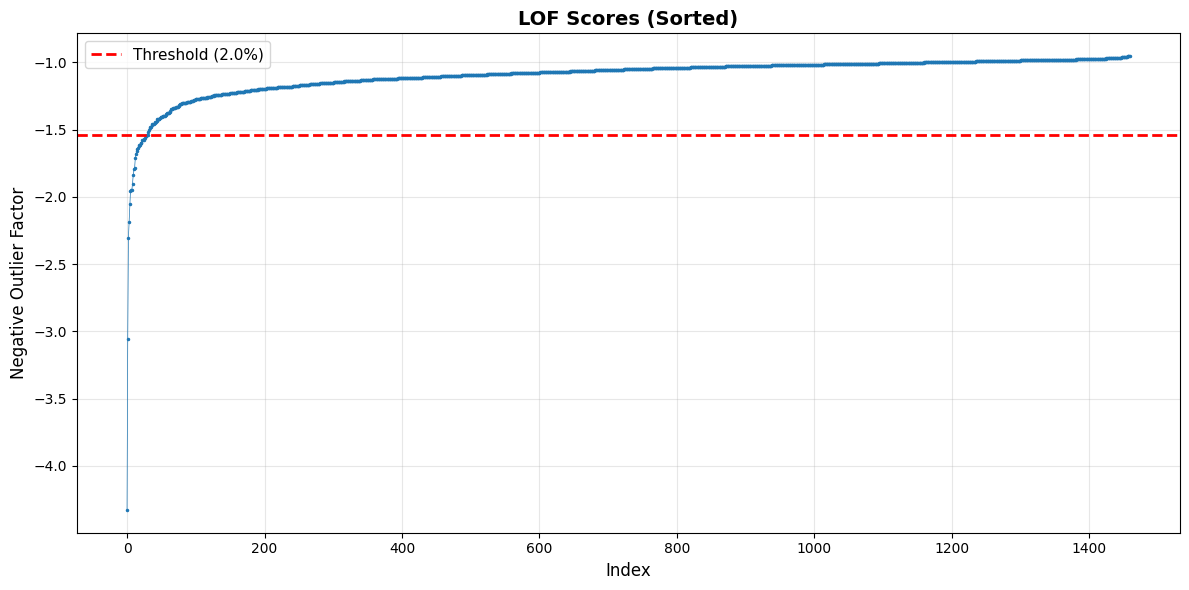

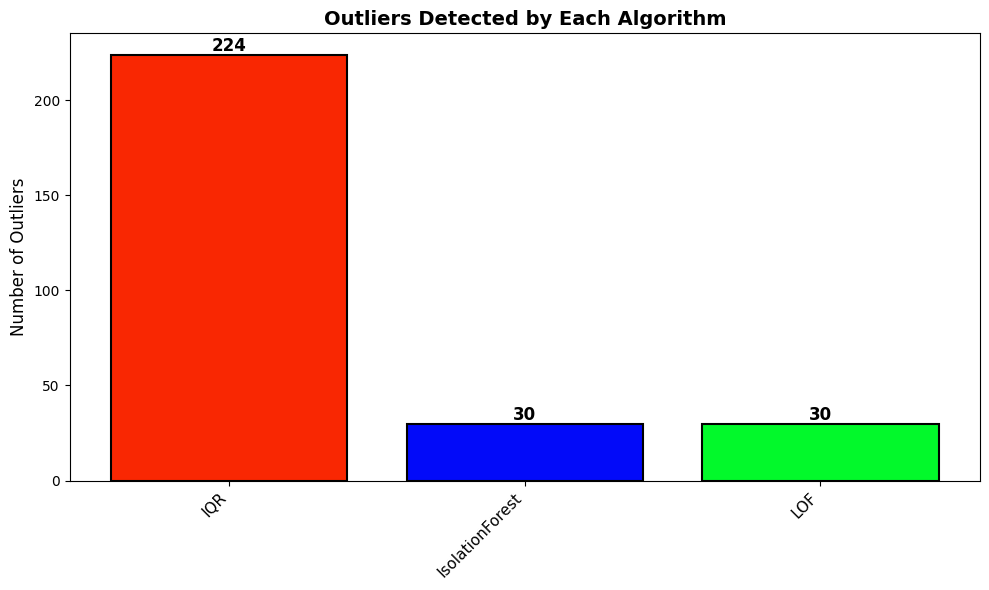

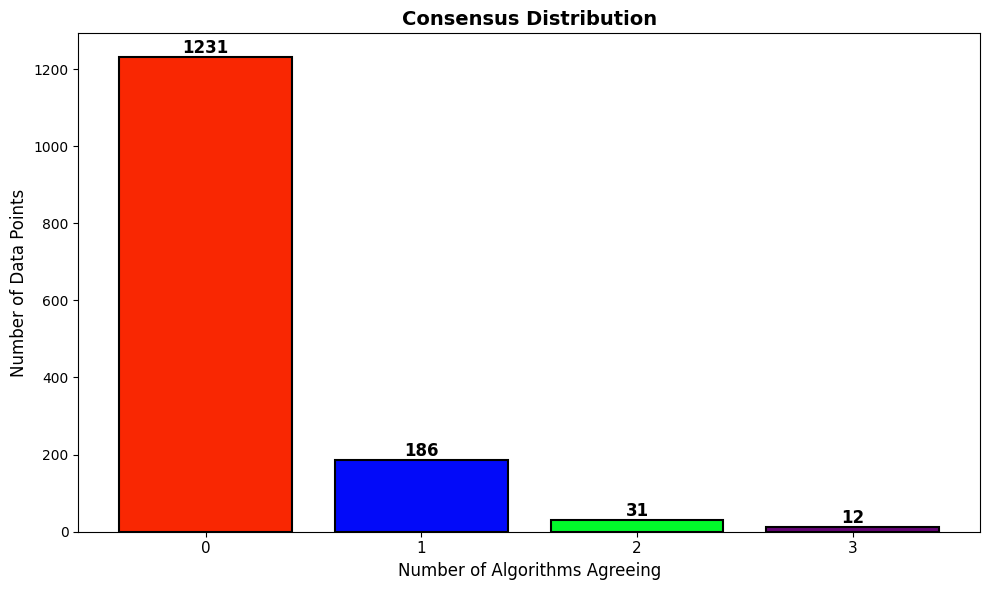

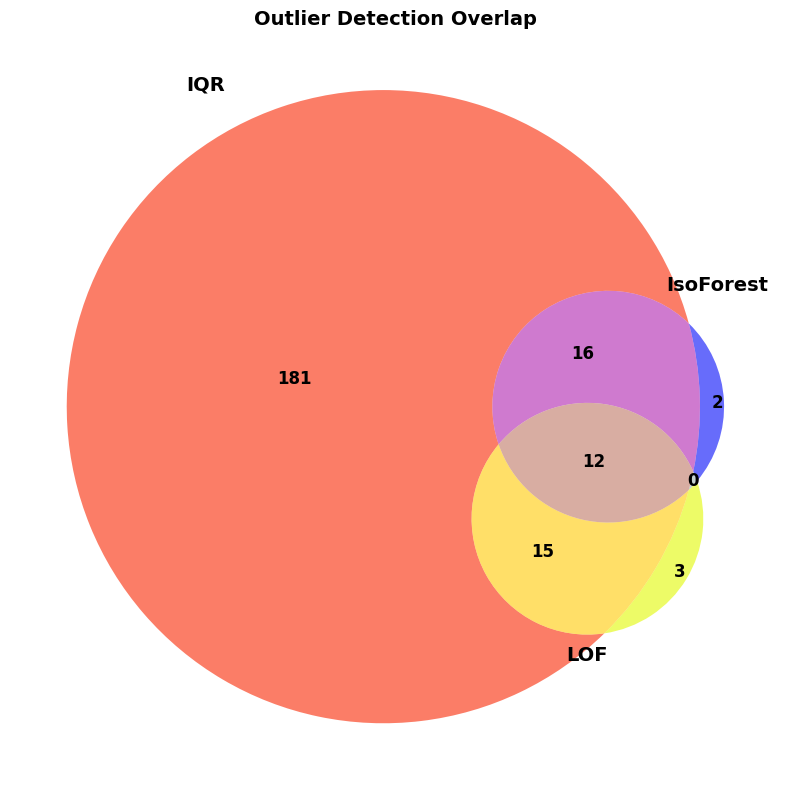


                      Outlier Detection Summary                       
Total data points: 1460
----------------------------------------------------------------------
IQR method: 224 outliers (15.34%)
Isolation Forest:  30 outliers ( 2.05%)
LOF:  30 outliers ( 2.05%)
----------------------------------------------------------------------
ML Consensus ((ISO ∪ LOF) ∩ IQR):   43 outliers ( 2.95%)
All 3 agree:  12 outliers ( 0.82%)



In [21]:
# Exclude zero-inflated variables from outlier detection. For example:
# LowQualFinSF: 98.2% zeros - IQR method doesn't work (Q1=Q3=0, thresholds=0)
# MiscVal: 96.7% zeros - IQR method doesn't work (Q1=Q3=0, thresholds=0)
# 3SsnPorch: 98.35% zeros - IQR method doesn't work (Q1=Q3=0, thresholds=0)
# Goes on for other similar features...
# Also Excluded:
# GarageYrBlt: Many missing values filled with -1 sentinel, not suitable for IQR
# We'll create a binary feature for this in feature engineering phase
zero_inflated_vars = ['3SsnPorch', 'LowQualFinSF', 'MiscVal', 'ScreenPorch', 
                   'BsmtFinSF2', 'EnclosedPorch', 'MasVnrArea', '2ndFlrSF', 
                   'WoodDeckSF', "OpenPorchSF", "GarageYrBlt"]

# Exclude features with natural wide range and meaningful extreme values
# LotArea: Lot size in square feet - naturally has wide distribution
#          IQR upper limit (~17,673) is too restrictive and caps many legitimate large lots
#          99th percentile (~37,568) still insufficient for capturing true variance
#          Extreme values are informative for price prediction (larger lot = potentially higher price)
#          Better handled through feature transformation (log/sqrt) in feature engineering phase
natural_wide_range_vars = ['LotArea']

# Combine exclusion lists
outlier_exclusion_vars = zero_inflated_vars + natural_wide_range_vars

# Remove zero-inflated variables from outlier detection
cp_num_cols_for_outlier = [col for col in cp_num_cols_clean if col not in outlier_exclusion_vars]

print("Starting outlier detection...")
print(f"Features to analyze: {len(cp_num_cols_clean)}")
print(f"Features excluded from outlier detection: {len(outlier_exclusion_vars)}")
print(f"  - Zero-inflated: {len(zero_inflated_vars)}")
print(f"  - Natural wide range: {len(natural_wide_range_vars)}")
print(f"Features for outlier detection: {len(cp_num_cols_for_outlier)}")

outliers_results, lof_scores, ml_consensus_outliers = hybrid_outlier_detection(
    df_clean, 
    cp_num_cols_for_outlier, # LowQualFinSF excluded
    contamination=0.02 # By looking at the LOF Score graph, the breakpoint of the elbow was selected.
)

In [22]:
if outliers_results is not None and len(ml_consensus_outliers) > 0:
    print(f"\n{'='*70}")
    print(f"Replacing {len(ml_consensus_outliers)} outlier rows with IQR thresholds...")
    print(f"{'='*70}\n")
    
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=FutureWarning)
        df_outlier_handling, replacement_log = replace_outliers_with_threholds(
            df_clean, 
            cp_num_cols_for_outlier, 
            ml_consensus_outliers
        )
    
    print(f"\n{'='*70}")
    print(f"✓ Outlier replacement completed!")
    print(f"  Total replacements: {len(replacement_log)}")
    print(f"{'='*70}\n")
    
    # İlk birkaç değişikliği göster
    if len(replacement_log) > 0:
        print("Sample replacements:")
        print(replacement_log.head(10))
else:
    print("\nNo outliers detected or detection failed.")


Replacing 43 outlier rows with IQR thresholds...

  LotFrontage: 14 value was changed
  YearBuilt: 2 value was changed
  BsmtFinSF1: 6 value was changed
  BsmtUnfSF: 8 value was changed
  TotalBsmtSF: 21 value was changed
  1stFlrSF: 14 value was changed
  GrLivArea: 13 value was changed
  TotRmsAbvGrd: 8 value was changed
  GarageArea: 8 value was changed

✓ Outlier replacement completed!
  Total replacements: 94

Sample replacements:
   index       column  original     new   type
0    649  LotFrontage    21.000  30.000  lower
1    523  LotFrontage   130.000 110.000  upper
2    909  LotFrontage   149.000 110.000  upper
3   1298  LotFrontage   313.000 110.000  upper
4   1173  LotFrontage   138.000 110.000  upper
5    277  LotFrontage   140.000 110.000  upper
6   1182  LotFrontage   160.000 110.000  upper
7   1061  LotFrontage   120.000 110.000  upper
8    934  LotFrontage   313.000 110.000  upper
9    807  LotFrontage   144.000 110.000  upper


In [23]:
cat_cols_outlierhandling , num_cols_outlierhandling, cat_but_car_outlierhandling, num_but_cat_outlierhandling = grab_col_names(df_outlier_handling)
num_cols_outlierhandling = [col for col in num_cols_outlierhandling if col not in ["Id"]]

Observations: 1460
Variables: 81
cat_cols: 55
num_cols: 25
cat_but_car: 1
num_but_cat: 12


In [24]:
# ========================================
# FEATURE ENGINEERING
# ========================================

def create_new_features(dataframe):
    """
    Creates new engineered features from existing features.
    
    Parameters:
    -----------
    dataframe : pd.DataFrame
        Input dataframe with original features
        
    Returns:
    --------
    pd.DataFrame
        Dataframe with additional engineered features
    """

    # Create a copy to avoid modifying original dataframe
    df_fe = dataframe.copy()

    # =======================================
    # 1. TOTAL AREAS
    # =======================================
    print("Creating Total Area Features")

    # Total square footage (above ground + basement)
    df_fe["TotalSF"] = df_fe["GrLivArea"] + df_fe["TotalBsmtSF"]

    # Total bathrooms (fullbaths count as 1, halfbaths as 0.5)
    df_fe["TotalBath"] = (df_fe["FullBath"] +
                          0.5 * df_fe["HalfBath"] +
                          df_fe["BsmtFullBath"] +
                          0.5 * df_fe["BsmtHalfBath"])
    
    # Total porch square footage (only porches)
    df_fe["TotalPorchSF"] = (df_fe["OpenPorchSF"] +
                            df_fe["EnclosedPorch"] +
                            df_fe["3SsnPorch"] +
                            df_fe["ScreenPorch"])

    # Total outdoor space (porches + deck)
    df_fe["TotalOutdoorSF"] = df_fe["TotalPorchSF"] + df_fe["WoodDeckSF"]
    
    # ========================================
    # 2. PROPORTIONAL FEATURES (RATIOS)
    # ========================================
    print("Creating Proportional Features")

    # Living area as proportion of lot area
    df_fe["LivingArea_to_LotArea"] = df_fe["GrLivArea"] / df_fe["LotArea"]

    # Basement proportion of living area (if basement exists)
    df_fe["Basement_to_GrLivArea"] = np.where(
        df_fe["GrLivArea"] > 0,
        df_fe["TotalBsmtSF"] / df_fe["GrLivArea"],
        0
    )

    # Garage area as proportion of lot area
    df_fe["GarageArea_to_LotArea"] = np.where(
        df_fe["LotArea"] > 0,
        df_fe["GarageArea"] / df_fe["LotArea"],
        0
    )

    # Rooms per unit area (rooms per square foot)
    df_fe["Rooms_per_Area"] = np.where(
        df_fe["GrLivArea"] > 0,
        (df_fe["TotRmsAbvGrd"] + df_fe["TotalBsmtSF"]) / df_fe["GrLivArea"],
        0
    )

    # Bedroom proportion of total rooms
    df_fe["Bedroom_to_TotRms"] = np.where(
        df_fe["TotRmsAbvGrd"] > 0,
        df_fe["BedroomAbvGr"] / df_fe["TotRmsAbvGrd"],
        0
    )

    # Kitchen proportion of total rooms
    df_fe["Kitchen_to_TotRms"] = np.where(
        df_fe["TotRmsAbvGrd"] > 0,
        df_fe["KitchenAbvGr"] / df_fe["TotRmsAbvGrd"],
        0
    )

    # ========================================
    # 3. AGE FEATURES
    # ========================================
    print("Creating Age Features")

    # House age at time of sale
    df_fe["HouseAge"] = df_fe["YrSold"] - df_fe["YearBuilt"]

    # Time since last remodeling
    df_fe["RemodAge"] = df_fe["YrSold"] - df_fe["YearRemodAdd"]

    # Garage age (handle -1 sentinel value for missing GarageYrBlt)
    df_fe["GarageAge"] = np.where(
        df_fe["GarageYrBlt"] == -1,
        -1,     # Keep -1 for houses without garage
        df_fe["YrSold"] - df_fe["GarageYrBlt"]
    )

    # ========================================
    # 4. BINARY FEATURES (0/1 indicators)
    # ========================================
    print("Creating Binary Features")

    # Was the house remodeled after construction?
    df_fe["IsRemodeled"] = (df_fe["YearRemodAdd"] != df_fe["YearBuilt"]).astype(int)

    # Was the house sold in the same year it was built?
    df_fe["IsNewHouse"] = (df_fe["YrSold"] == df_fe["YearBuilt"]).astype(int)

    # Was the house sold in the same year it was remodeled?
    df_fe["IsNewlyRemodeled"] = (df_fe["YrSold"] == df_fe["YearRemodAdd"]).astype(int)

    # Binary indicators for zero-inflated features
    df_fe["Is3SsnPorch"] = (df_fe["3SsnPorch"] > 0).astype(int)
    df_fe["IsLowQualFinSF"] = (df_fe["LowQualFinSF"] > 0).astype(int)
    df_fe["IsMiscVal"] = (df_fe["MiscVal"] > 0).astype(int)
    df_fe["IsScreenPorch"] = (df_fe["ScreenPorch"] > 0).astype(int)
    df_fe["IsBsmtFinSF2"] = (df_fe["BsmtFinSF2"] > 0).astype(int)
    df_fe["IsEnclosedPorch"] = (df_fe["EnclosedPorch"] > 0).astype(int)
    df_fe["IsMasVnrArea"] = (df_fe["MasVnrArea"] > 0).astype(int)
    df_fe["Is2ndFlrSF"] = (df_fe["2ndFlrSF"] > 0).astype(int)
    df_fe["IsWoodDeckSF"] = (df_fe["WoodDeckSF"] > 0).astype(int)
    df_fe["IsOpenPorchSF"] = (df_fe["OpenPorchSF"] > 0).astype(int)
    df_fe["IsGarage"] = (df_fe["GarageYrBlt"] != -1).astype(int)    # Has Garage

    # ========================================
    # 5. QUALITY MAPPING (Categorical to Numerical)
    # ========================================
    print("Mapping Quality Variables")
    
    # Quality mapping dictionary
    qual_map = {
        'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 
        'None': 0, 'NA': 0, np.nan: 0
    }
    
    # Apply quality mapping
    df_fe["ExterQual_num"] = df_fe["ExterQual"].map(qual_map).fillna(0)
    df_fe["KitchenQual_num"] = df_fe["KitchenQual"].map(qual_map).fillna(0)
    df_fe["BsmtQual_num"] = df_fe["BsmtQual"].map(qual_map).fillna(0)
    df_fe["HeatingQC_num"] = df_fe["HeatingQC"].map(qual_map).fillna(0)
    df_fe["GarageQual_num"] = df_fe["GarageQual"].map(qual_map).fillna(0)

    # Apply condition mapping
    df_fe["ExterCond_num"] = df_fe["ExterCond"].map(qual_map).fillna(0)
    df_fe["BsmtCond_num"] = df_fe["BsmtCond"].map(qual_map).fillna(0)
    df_fe["GarageCond_num"] = df_fe["GarageCond"].map(qual_map).fillna(0)
    # ========================================
    # 6. NUMERICAL QUALITY SCORES
    # ========================================
    print("Creating Quality Score Features")

    # Total quality score (sum of quality ratings)
    df_fe["TotalQual"] = (df_fe["OverallQual"] +
                               df_fe["ExterQual_num"] +
                               df_fe["KitchenQual_num"] +
                               df_fe["BsmtQual_num"] +
                               df_fe["HeatingQC_num"] +
                               df_fe["GarageQual_num"])
    
    # Total condition score (sum of condition ratings)
    df_fe["TotalCond"] = (df_fe["OverallCond"] +
                               df_fe["ExterCond_num"] +
                               df_fe["BsmtCond_num"] +
                               df_fe["GarageCond_num"])
    
    # Interaction: Overall quality * condition
    df_fe["OverallQual_and_OverallCond"] = df_fe["OverallQual"] * df_fe["OverallCond"]

    # Interaction: Living area * quality
    df_fe["LivingArea_and_OverallQuality"] = df_fe["GrLivArea"] * df_fe["OverallQual"]

    # ========================================
    # 7. CATEGORICAL QUALITY COMBINATIONS
    # ========================================
    print("Creating Categorical Quality Combination Features")

    # Combine exterior quality and condition
    df_fe["Exter_Qual_and_Cond"] = df_fe["ExterQual"].astype(str) + "_" + df_fe["ExterCond"].astype(str)
    
    # Combine basement quality and condition
    df_fe["Bsmt_Qual_and_Cond"] = df_fe["BsmtQual"].astype(str) + "_" + df_fe["BsmtCond"].astype(str)
    
    # Combine heating type and quality
    df_fe["Heating_and_HeatingQC"] = df_fe["Heating"].astype(str) + "_" + df_fe["HeatingQC"].astype(str)
    
    # Combine garage quality and condition
    df_fe["Garage_Qual_and_Cond"] = df_fe["GarageQual"].astype(str) + "_" + df_fe["GarageCond"].astype(str)

    # ========================================
    # 8. QUALITY GROUPING
    # ========================================

    print("Creating Quality Grouping Features")

    # Overall quality grouping
    df_fe["QualityLevel"] = pd.cut(
        df_fe["OverallQual"],
        bins=[0, 2, 4, 5, 7, 10],
        labels=["Very Poor", "Poor", "Average", "Good", "Excellent"],
        include_lowest=True
    )

    # Overall condition grouping
    df_fe["ConditionLevel"] = pd.cut(
        df_fe["OverallCond"],
        bins=[0, 2, 4, 5, 7, 10],
        labels=["Very Poor", "Poor", "Average", "Good", "Excellent"],
        include_lowest=True
    )

    # ========================================
    # 9. LUXURY AND FEATURE SCORES
    # ========================================
    print("Creating Luxury and Feature Score Features")

    # Basic amenities binary features
    df_fe["HasPool"] = (df_fe["PoolArea"] > 0).astype(int)
    df_fe["HasFireplace"] = (df_fe["Fireplaces"] > 0).astype(int)
    df_fe["HasGarage"] = (df_fe["GarageArea"] > 0).astype(int)
    df_fe["HasBasement"] = (df_fe["TotalBsmtSF"] > 0).astype(int)
    df_fe["HasPorch"] = (df_fe["TotalPorchSF"] > 0).astype(int)

    # Basic amenities score
    df_fe["FeatureScore"] = (df_fe["HasPool"] +
                            df_fe["HasFireplace"] +
                            df_fe["HasGarage"] +
                            df_fe["HasBasement"] +
                            df_fe["HasPorch"])
    
    # Luxury score (amenities weighted by luxury level)
    df_fe["LuxuryScore"] = ((df_fe["PoolArea"] > 0).astype(int) * 3 + 
                             (df_fe["Fireplaces"] > 1).astype(int) * 2 + 
                             (df_fe["GarageCars"] > 2).astype(int) * 2 + 
                             (df_fe["OverallQual"] >= 8).astype(int) * 3)
    
    # ========================================
    # 10. SEASON FEATURE
    # ========================================
    print("Creating Season Feature")

    # Season of sale
    season_map = {
        12: "Winter", 1: "Winter", 2: "Winter",
        3: "Spring", 4: "Spring", 5: "Spring",
        6: "Summer", 7: "Summer", 8: "Summer",
        9: "Fall", 10: "Fall", 11: "Fall"
    }

    df_fe["Season"] = df_fe["MoSold"].map(season_map)

    # ========================================
    # 11. SALE TYPE GROUPING
    # ========================================
    print("Creating Sale Type Grouping Features")
    
    # Sale financing type grouping
    sale_financing_map = {
        "WD": "Standard_Deed", "CWD": "Standard_Deed", "VWD": "Standard_Deed",
        "Con": "Contract_Sale", "ConLw": "Contract_Sale", "ConLI": "Contract_Sale", 
        "ConLD": "Contract_Sale",
        "New": "New_Construction",
        "COD": "Distressed_Special", "Oth": "Distressed_Special"
    }
    
    df_fe['Sale_Financing_Type'] = df_fe['SaleType'].map(sale_financing_map)
    
    # Sale type risk grouping
    sale_risk_map = {
        "WD": "Low_Risk", "CWD": "Low_Risk", "VWD": "Low_Risk", "New": "Low_Risk",
        "Con": "Medium_Risk", "ConLI": "Medium_Risk", "ConLD": "Medium_Risk",
        "ConLw": "High_Risk", "COD": "High_Risk", "Oth": "High_Risk"
    }
    
    df_fe['SaleType_Risk'] = df_fe['SaleType'].map(sale_risk_map)
    
    # ========================================
    # 12. SALE CONDITION GROUPING
    # ========================================
    print("Creating Sale Condition Grouping Features")
    
    # Sale market condition grouping
    sale_market_map = {
        "Normal": "Normal_Complete",
        "Abnorml": "Abnormal_Distressed", "Family": "Abnormal_Distressed",
        "Partial": "Partial_Development", "AdjLand": "Partial_Development", 
        "Alloca": "Partial_Development"
    }
    
    df_fe['Sale_Market_Condition'] = df_fe['SaleCondition'].map(sale_market_map)
    
    # Sale condition risk grouping
    sale_cond_risk_map = {
        'Normal': 'Low_Risk',
        'AdjLand': 'Medium_Risk', 'Alloca': 'Medium_Risk', 'Partial': 'Medium_Risk',
        'Abnorml': 'High_Risk', 'Family': 'High_Risk'
    }
    
    df_fe['SaleCondition_Risk'] = df_fe['SaleCondition'].map(sale_cond_risk_map)
    
    # ========================================
    # 13. NUMERICAL TRANSFORMATIONS
    # ========================================
    print("Creating Numerical Transformations")

    # Log transformation for LotArea (handle skewness)
    df_fe['LotArea_Log'] = np.log1p(df_fe['LotArea'])  # log1p = log(1+x) to handle zeros
    
    # Square root transformation for LotArea
    df_fe['LotArea_Sqrt'] = np.sqrt(df_fe['LotArea'])

    # ========================================
    # 14. NEIGHBORHOOD GROUPING
    # ========================================
    print("Creating Neighborhood Grouping Features")

    # Neighborhood price tier grouping (based on domain knowledge/EDA)
    neighborhood_tiers = {
        "Luxury": ["NoRidge", "NridgHt", "StoneBr"],
        "Upper_Middle": ["Timber", "Veenker", "Somerst", "ClearCr", "Crawfor"],
        "Middle": ["CollgCr", "Blmngtn", "Gilbert", "NWAmes", "SawyerW"],
        "Lower_Middle": ["Mitchel", "NAmes", "NPkVill", "SWISU", "Blueste", 
                        "Sawyer", "OldTown", "Edwards", "BrkSide"],
        "Budget": ["BrDale", "IDOTRR", "MeadowV"]
    }

    # Reverse mapping
    neighborhood_price_map = {neighborhood: tier 
                            for tier, neighborhoods in neighborhood_tiers.items() 
                            for neighborhood in neighborhoods}

    df_fe["Neighborhood_Price_Level"] = df_fe["Neighborhood"].map(neighborhood_price_map).fillna("Other")

    # Validate mapping
    unmapped = df_fe[df_fe["Neighborhood_Price_Level"] == "Other"]["Neighborhood"].unique()
    if len(unmapped) > 0:
        print(f"Warning: {len(unmapped)} neighborhoods not mapped: {list(unmapped)}")
    else:
        print("All neighborhoods successfully mapped")

    print(f"\nFeature Engineering Complete!")
    print(f"Original features: {len(dataframe.columns)}")
    print(f"New features added: {len(df_fe.columns) - len(dataframe.columns)}")
    print(f"Total features: {len(df_fe.columns)}")
    
    return df_fe

In [25]:
# Apply feature engineering to your cleaned dataframe
df_engineered = create_new_features(df_outlier_handling)

# Display summary
print("\n" + "="*50)
print("FEATURE ENGINEERING SUMMARY")
print("="*50)
check_df(df_engineered)

# Get new feature names
original_cols = set(df_outlier_handling.columns)
new_cols = set(df_engineered.columns) - original_cols
print(f"\nNewly Created Features ({len(new_cols)}):")
print("-" * 50)
for i, col in enumerate(sorted(new_cols), 1):
    print(f"{i:2d}. {col}")

Creating Total Area Features
Creating Proportional Features
Creating Age Features
Creating Binary Features
Mapping Quality Variables
Creating Quality Score Features
Creating Categorical Quality Combination Features
Creating Quality Grouping Features
Creating Luxury and Feature Score Features
Creating Season Feature
Creating Sale Type Grouping Features
Creating Sale Condition Grouping Features
Creating Numerical Transformations
Creating Neighborhood Grouping Features
All neighborhoods successfully mapped

Feature Engineering Complete!
Original features: 81
New features added: 60
Total features: 141

FEATURE ENGINEERING SUMMARY
###################### Shape ######################
(1460, 141)

###################### Info ######################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 141 entries, Id to Neighborhood_Price_Level
dtypes: category(2), float64(20), int64(65), object(54)
memory usage: 1.6+ MB

###################### Types ###############

,Type
Id,int64
MSSubClass,object
MSZoning,object
LotFrontage,float64
LotArea,int64
Street,object
Alley,object
LotShape,object
LandContour,object
Utilities,object



##################### Head #####################


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,TotalPorchSF,TotalOutdoorSF,LivingArea_to_LotArea,Basement_to_GrLivArea,GarageArea_to_LotArea,Rooms_per_Area,Bedroom_to_TotRms,Kitchen_to_TotRms,HouseAge,RemodAge,GarageAge,IsRemodeled,IsNewHouse,IsNewlyRemodeled,Is3SsnPorch,IsLowQualFinSF,IsMiscVal,IsScreenPorch,IsBsmtFinSF2,IsEnclosedPorch,IsMasVnrArea,Is2ndFlrSF,IsWoodDeckSF,IsOpenPorchSF,IsGarage,ExterQual_num,KitchenQual_num,BsmtQual_num,HeatingQC_num,GarageQual_num,ExterCond_num,BsmtCond_num,GarageCond_num,TotalQual,TotalCond,OverallQual_and_OverallCond,LivingArea_and_OverallQuality,Exter_Qual_and_Cond,Bsmt_Qual_and_Cond,Heating_and_HeatingQC,Garage_Qual_and_Cond,QualityLevel,ConditionLevel,HasPool,HasFireplace,HasGarage,HasBasement,HasPorch,FeatureScore,LuxuryScore,Season,Sale_Financing_Type,SaleType_Risk,Sale_Market_Condition,SaleCondition_Risk,LotArea_Log,LotArea_Sqrt,Neighborhood_Price_Level
0,1,2story_1946+,RL,65.000,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706.000,Unf,0,150.000,856,GasA,Ex,Y,SBrkr,856.000,854,0,1710.000,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.000,RFn,2,548.000,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500,2566.000,3.500,61,61,0.202,0.501,0.065,0.505,0.375,0.125,5,5,5.000,0,0,0,0,0,0,0,0,0,1,1,0,1,1,4,4,4,5,3,3,3,3,27,14,35,11970.000,Gd_TA,Gd_TA,GasA_Ex,TA_TA,Good,Average,0,0,1,1,1,3,0,Winter,Standard_Deed,Low_Risk,Normal_Complete,Low_Risk,9.042,91.924,Middle
1,2,1story_1946+,RL,80.000,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.000,Unf,0,284.000,1262,GasA,Ex,Y,SBrkr,1262.000,0,0,1262.000,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.000,RFn,2,460.000,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500,2524.000,2.500,0,298,0.131,1.000,0.048,1.005,0.500,0.167,31,31,31.000,0,0,0,0,0,0,0,0,0,0,0,1,0,1,3,3,4,5,3,3,3,3,24,17,48,7572.000,TA_TA,Gd_TA,GasA_Ex,TA_TA,Good,Excellent,0,1,1,1,0,3,0,Spring,Standard_Deed,Low_Risk,Normal_Complete,Low_Risk,9.170,97.980,Upper_Middle
2,3,2story_1946+,RL,68.000,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.000,Unf,0,434.000,920,GasA,Ex,Y,SBrkr,920.000,866,0,1786.000,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.000,RFn,2,608.000,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500,2706.000,3.500,42,42,0.159,0.515,0.054,0.518,0.500,0.167,7,6,7.000,1,0,0,0,0,0,0,0,0,1,1,0,1,1,4,4,4,5,3,3,3,3,27,14,35,12502.000,Gd_TA,Gd_TA,GasA_Ex,TA_TA,Good,Average,0,1,1,1,1,4,0,Fall,Standard_Deed,Low_Risk,Normal_Complete,Low_Risk,9.328,106.066,Middle
3,4,2story_1945-,RL,60.000,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216.000,Unf,0,540.000,756,GasA,Gd,Y,SBrkr,961.000,756,0,1717.000,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.000,Unf,3,642.000,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000,2473.000,2.000,307


###################### Tail ######################


...


###################### Unique Value Counts per Column ######################


Id                               1460
MSSubClass                         15
MSZoning                            5
LotFrontage                       106
LotArea                          1073
Street                              2
Alley                               3
LotShape                            4
LandContour                         4
Utilities                           2
LotConfig                           5
LandSlope                           3
Neighborhood                       25
Condition1                          9
Condition2                          8
BldgType                            5
HouseStyle                          8
OverallQual                        10
OverallCond                         9
YearBuilt                         111
YearRemodAdd                       61
RoofStyle                           6
RoofMatl                            8
Exterior1st                        15
Exterior2nd                        16
MasVnrType                          4
MasVnrArea  


###################### NA ######################


,Missing Values
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
Alley,0
LotShape,0
LandContour,0
Utilities,0



Newly Created Features (60):
--------------------------------------------------
 1. Basement_to_GrLivArea
 2. Bedroom_to_TotRms
 3. BsmtCond_num
 4. BsmtQual_num
 5. Bsmt_Qual_and_Cond
 6. ConditionLevel
 7. ExterCond_num
 8. ExterQual_num
 9. Exter_Qual_and_Cond
10. FeatureScore
11. GarageAge
12. GarageArea_to_LotArea
13. GarageCond_num
14. GarageQual_num
15. Garage_Qual_and_Cond
16. HasBasement
17. HasFireplace
18. HasGarage
19. HasPool
20. HasPorch
21. HeatingQC_num
22. Heating_and_HeatingQC
23. HouseAge
24. Is2ndFlrSF
25. Is3SsnPorch
26. IsBsmtFinSF2
27. IsEnclosedPorch
28. IsGarage
29. IsLowQualFinSF
30. IsMasVnrArea
31. IsMiscVal
32. IsNewHouse
33. IsNewlyRemodeled
34. IsOpenPorchSF
35. IsRemodeled
36. IsScreenPorch
37. IsWoodDeckSF
38. KitchenQual_num
39. Kitchen_to_TotRms
40. LivingArea_and_OverallQuality
41. LivingArea_to_LotArea
42. LotArea_Log
43. LotArea_Sqrt
44. LuxuryScore
45. Neighborhood_Price_Level
46. OverallQual_and_OverallCond
47. QualityLevel
48. RemodAge
49. Room

In [26]:
cat_cols_engineered, num_cols_engineered, cat_but_car_engineered, num_but_cat_engineered = grab_col_names(df_engineered)
num_cols_engineered = [col for col in num_cols_engineered if col not in ["Id"]]

Observations: 1460
Variables: 141
cat_cols: 97
num_cols: 43
cat_but_car: 1
num_but_cat: 44


In [27]:
def target_encode(X_train, X_val, col, y_train, n_splits=5):
    """
    Applies K-Fold Target Encoding to a single categorical column to prevent data leakage.

    Methodology:
    1. For Training Data (X_train): Uses K-Fold cross-validation logic. The data is split 
       into K folds. For each fold, the mean is calculated using the OTHER (K-1) folds. 
       This prevents the model from "seeing" the target of the row it is currently predicting.
    2. For Validation Data (X_val): Uses the standard global mean from the entire X_train. 
       This mimics the production environment where we use all available history.

    Parameters
    ----------
    X_train : pd.DataFrame
        Training feature set.
    X_val : pd.DataFrame
        Validation feature set.
    col : str
        The name of the column to encode.
    y_train : pd.Series
        The target variable.
    n_splits : int, optional
        Number of folds for K-Fold encoding (default is 5).

    Returns
    -------
    X_train_encoded, X_val_encoded : pd.Series
        The column transformed into numerical mean values.
    """
    # Initialize empty Series for the encoded training column with the same index as X_train
    X_train_encoded = pd.Series(np.nan, index=X_train.index)
    
    # Initialize KFold
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # --- 1. K-Fold Encoding for X_train (Prevents Leakage) ---
    for train_idx, map_idx in kf.split(X_train):
        # Split internal training data into "inner train" and "inner hold-out"
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_map = X_train.iloc[map_idx]
        
        # Calculate means on the "inner train" folds
        # Using groupby on y_train directly aligned with X_train is faster and cleaner
        fold_means = y_fold_train.groupby(X_fold_train[col]).mean()
        
        # Map these means to the "inner hold-out" fold
        X_train_encoded.iloc[map_idx] = X_fold_map[col].map(fold_means)

    # --- 2. Standard Encoding for X_val (Production Logic) ---
    # For validation, we use the entire training set statistics
    global_mean = y_train.mean()
    full_means = y_train.groupby(X_train[col]).mean()
    
    X_val_encoded = X_val[col].map(full_means)
    
    # --- 3. Handle Missing Values (Unseen Categories) ---
    # Fill NaNs in both sets with the global mean of the target
    X_train_encoded.fillna(global_mean, inplace=True)
    X_val_encoded.fillna(global_mean, inplace=True)
    
    return X_train_encoded, X_val_encoded


def prepare_features_for_models(X_train, X_val, y_train, cat_cols, cat_but_car):
    """
    Prepares features for modeling by handling encoding, scaling, and feature tracking.
    
    Methodology:
    1. High Cardinality Columns: Applies K-Fold Target Encoding (Updated).
    2. Low Cardinality Columns: Applies One-Hot Encoding.
    3. Scaling: Standardizes features (Z-score) for linear models (ElasticNet).
    4. Mapping: Creates a dictionary to map dummy variables back to their original parent feature.

    Parameters
    ----------
    X_train, X_val : pd.DataFrame
        Raw training and validation split data.
    y_train : pd.Series
        Target variable for target encoding.
    cat_cols : list
        List of all categorical columns.
    cat_but_car : list
        List of high-cardinality categorical columns (to be target encoded).

    Returns
    -------
    X_train_scaled, X_val_scaled : pd.DataFrame
        Processed and scaled data ready for ElasticNet.
    feature_names : list
        List of final column names after encoding.
    scaler : StandardScaler
        The fitted scaler object.
    feature_map : dict
        A dictionary mapping original feature names to their encoded dummy columns.
        Structure: {'Original_Col': ['Dummy_Col_1', 'Dummy_Col_2', ...]}
    """
    X_train_proc = X_train.copy()
    X_val_proc = X_val.copy()
    
    # Feature Map: {Original_Col_Name: [List_of_Encoded_Col_Names]}
    feature_map = {}
    
    # Identify column types
    cat_but_car_in_data = [col for col in cat_but_car if col in X_train.columns]
    low_card_cat = [col for col in cat_cols if col in X_train.columns and col not in cat_but_car_in_data]
    
    # 1. Target encoding for high cardinality (1-to-1 mapping)
    for col in cat_but_car_in_data:
        # Calls the updated K-Fold enabled function
        X_train_proc[col], X_val_proc[col] = target_encode(X_train, X_val, col, y_train)
        feature_map[col] = [col]
    
    # 2. One-hot encoding for low cardinality (1-to-Many mapping)
    for col in low_card_cat:
        dummies_train = pd.get_dummies(X_train_proc[col], prefix=col, drop_first=True)
        dummies_val = pd.get_dummies(X_val_proc[col], prefix=col, drop_first=True)
        
        # Align columns (ensure val set has same dummies as train)
        for c in dummies_train.columns:
            if c not in dummies_val.columns:
                dummies_val[c] = 0
        dummies_val = dummies_val[dummies_train.columns]
        
        X_train_proc = pd.concat([X_train_proc.drop(col, axis=1), dummies_train], axis=1)
        X_val_proc = pd.concat([X_val_proc.drop(col, axis=1), dummies_val], axis=1)
        
        # Record which dummy columns belong to this original categorical feature
        feature_map[col] = list(dummies_train.columns)
    
    # 3. Numerical columns (1-to-1 mapping)
    # Any column not in cat_cols is considered numerical for this mapping
    num_cols = [c for c in X_train.columns if c not in cat_cols]
    for col in num_cols:
        feature_map[col] = [col]

    # 4. Scale for ElasticNet
    scaler = MaxAbsScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_proc),
        columns=X_train_proc.columns,
        index=X_train_proc.index
    )
    X_val_scaled = pd.DataFrame(
        scaler.transform(X_val_proc),
        columns=X_val_proc.columns,
        index=X_val_proc.index
    )
    
    return X_train_scaled, X_val_scaled, list(X_train_proc.columns), scaler, feature_map


def calculate_grouped_permutation(model, X_val, y_val, feature_map):
    """
    Calculates Permutation Importance and aggregates results for One-Hot Encoded features.
    
    Methodology:
    1. Calculates standard Permutation Importance (on Validation set).
    2. Uses 'feature_map' to identify which dummy columns belong to the same original feature.
    3. Sums the importance scores of these dummy groups to get a single score per original feature.
    
    Parameters
    ----------
    model : fitted estimator
        The trained model (ElasticNet, RF, or XGB).
    X_val : pd.DataFrame
        Validation features.
    y_val : pd.Series
        Validation targets.
    feature_map : dict
        Mapping of original features to encoded columns.

    Returns
    -------
    pd.Series
        Aggregated importance scores sorted descending.
    """
    result = permutation_importance(
        model, X_val, y_val, n_repeats=5, random_state=42, n_jobs=-1, scoring='r2'
    )
    raw_imp = pd.Series(result.importances_mean, index=X_val.columns)
    
    grouped_imp = {}
    for original, encoded_cols in feature_map.items():
        valid_cols = [c for c in encoded_cols if c in X_val.columns]
        if valid_cols:
            grouped_imp[original] = raw_imp[valid_cols].sum()
            
    return pd.Series(grouped_imp).sort_values(ascending=False)


def train_and_get_importances(X_train, X_val, y_train, y_val, feature_map):
    """
    Trains ElasticNet, RandomForest, and XGBoost models and computes their importances.
    
    Methodology:
    Trains each model on the processed training set, evaluates it on the validation set,
    and then calls 'calculate_grouped_permutation' to derive unbiased feature importance.

    Returns
    -------
    results : dict
        A dictionary containing the trained models, their metrics (RMSE, R2), 
        and the calculated feature importance Series.
    """
    results = {}
    
    # 1. ElasticNet
    print("Training ElasticNet...", end=" ")
    elasticnet = ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
        cv=5, random_state=42, max_iter=10000
    )
    elasticnet.fit(X_train, y_train)
    y_pred_en = elasticnet.predict(X_val)
    
    print("Calculating Importance...", end=" ")
    imp_en = calculate_grouped_permutation(elasticnet, X_val, y_val, feature_map)

    results['ElasticNet'] = {
        'model': elasticnet,
        'importances': imp_en,
        'metrics': {
            'RMSE': np.sqrt(mean_squared_error(y_val, y_pred_en)),
            'MAE': mean_absolute_error(y_val, y_pred_en),
            'R2': r2_score(y_val, y_pred_en)
        }
    }
    print(f"R²: {results['ElasticNet']['metrics']['R2']:.4f}")
    
    # 2. Random Forest
    print("Training RandomForest...", end=" ")
    rf = RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_split=5, 
        min_samples_leaf=2, random_state=42, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_val)
    
    print("Calculating Importance...", end=" ")
    imp_rf = calculate_grouped_permutation(rf, X_val, y_val, feature_map)

    results['RandomForest'] = {
        'model': rf,
        'importances': imp_rf,
        'metrics': {
            'RMSE': np.sqrt(mean_squared_error(y_val, y_pred_rf)),
            'MAE': mean_absolute_error(y_val, y_pred_rf),
            'R2': r2_score(y_val, y_pred_rf)
        }
    }
    print(f"R²: {results['RandomForest']['metrics']['R2']:.4f}")
    
    # 3. XGBoost
    print("Training XGBoost...", end=" ")
    xgb_model = xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.05, 
        min_child_weight=3, random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_val)
    
    print("Calculating Importance...", end=" ")
    imp_xgb = calculate_grouped_permutation(xgb_model, X_val, y_val, feature_map)

    results['XGBoost'] = {
        'model': xgb_model,
        'importances': imp_xgb,
        'metrics': {
            'RMSE': np.sqrt(mean_squared_error(y_val, y_pred_xgb)),
            'MAE': mean_absolute_error(y_val, y_pred_xgb),
            'R2': r2_score(y_val, y_pred_xgb)
        }
    }
    print(f"R²: {results['XGBoost']['metrics']['R2']:.4f}")
    
    return results


def plot_model_performance(results):
    """
    Visualizes the comparative performance (RMSE, MAE, R2) of the three models using bar charts.
    """
    models = list(results.keys())
    metrics_names = ['RMSE', 'MAE', 'R2']
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    colours = ['#6d0972', '#720943', '#380972']
    
    for idx, metric in enumerate(metrics_names):
        values = [results[m]['metrics'][metric] for m in models]
        bars = axes[idx].bar(models, values, color=colours, edgecolor='black', linewidth=1.2)
        axes[idx].set_title(metric, fontsize=14, fontweight='bold')
        axes[idx].set_ylabel(metric, fontsize=11)
        
        for bar, val in zip(bars, values):
            height = bar.get_height()
            axes[idx].text(
                bar.get_x() + bar.get_width() / 2., height,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold'
            )
        
        axes[idx].grid(axis='y', alpha=0.3)
    
    plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_feature_importance_on_ax(importances, model_name, metrics, ax, top_n=30, colour='#667EEA'):
    """
    Helper function to plot feature importance on a specific Matplotlib Axis (ax).
    Used to create the side-by-side subplot layout.
    """
    sorted_imp = importances.sort_values(ascending=True).tail(top_n)
    
    # Plot horizontal bars
    bars = ax.barh(range(len(sorted_imp)), sorted_imp.values, color=colour, edgecolor='black', linewidth=0.5)
    
    # Formatting
    ax.set_yticks(range(len(sorted_imp)))
    ax.set_yticklabels(sorted_imp.index, fontsize=9)
    ax.set_xlabel('Permutation Importance', fontsize=10)
    
    # Title with metrics
    metrics_str = f"R²: {metrics['R2']:.3f} | RMSE: {metrics['RMSE']:.2f} | MAE: {metrics['MAE']:.2f}"
    ax.set_title(f'{model_name}\n{metrics_str}', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)


def get_styled_importance_table(importances, model_name):
    """
    Prepares a dataframe for HTML display, resetting index and sorting values.
    """
    df = pd.DataFrame({
        'Feature': importances.index,
        'Importance': importances.values
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
    
    df.index = df.index + 1
    return df


def compare_feature_importance(
    X_train, X_val, y_train, y_val,
    cat_cols=None, cat_but_car=None,
    top_n=30, show_tables=True
):
    """
    Main Execution Function.
    
    Orchestrates the entire pipeline:
    1. Prepares data (Encoding/Scaling).
    2. Trains 3 models (ElasticNet, RF, XGB).
    3. Calculates Grouped Permutation Importance.
    4. Plots performance metrics.
    5. Plots feature importance graphs side-by-side.
    6. Displays detailed feature importance tables side-by-side.
    
    Parameters
    ----------
    X_train, X_val : pd.DataFrame
        Data splits.
    top_n : int
        Number of top features to display in the graphs.
    show_tables : bool
        Whether to render the detailed HTML tables.
        
    Returns
    -------
    results : dict
        Contains all trained model objects, metrics, and importance scores.
    """
    print("=" * 60)
    print(f"{'Feature Importance Comparison':^60}")
    print("=" * 60)
    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    
    # Handle None inputs
    if cat_cols is None:
        cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
    if cat_but_car is None:
        cat_but_car = []
    
    # Prepare features
    X_train_proc, X_val_proc, feature_names, scaler, feature_map = prepare_features_for_models(
        X_train, X_val, y_train, cat_cols, cat_but_car
    )
    
    # Train models
    results = train_and_get_importances(X_train_proc, X_val_proc, y_train, y_val, feature_map)
    
    # 1. Plot Performance
    print("\n")
    plot_model_performance(results)
    
    # 2. Plot Feature Importances (Side-by-Side 1x3 Grid)
    print("\n" + "="*60)
    print("Top Feature Importances (Grouped Permutation)")
    print("="*60)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, max(10, top_n * 0.3))) # Dynamic height
    colours = {'ElasticNet': '#6d0972', 'RandomForest': '#720943', 'XGBoost': '#380972'}
    
    for (model_name, data), ax in zip(results.items(), axes):
        plot_feature_importance_on_ax(
            data['importances'],
            model_name,
            data['metrics'],
            ax=ax,
            top_n=top_n,
            colour=colours[model_name]
        )
    
    plt.tight_layout()
    plt.show()

    # 3. Display Tables (Side-by-Side HTML)
    if show_tables:
        print("\n" + "="*60)
        print("Detailed Importance Tables (All Features)")
        print("="*60)
        
        html_str = ""
        for model_name, data in results.items():
            df = get_styled_importance_table(data['importances'], model_name)
            
            # Count Non-zeros
            non_zero = (df['Importance'] > 0).sum()
            total = len(df)
            
            # Create a header for the HTML table
            header_html = f"""
            <div style="display:inline-block; vertical-align:top; margin-right:20px;">
            <h3>{model_name}</h3>
            <p>Total: {total} | Non-Zero: {non_zero}</p>
            """
            
            # Convert DF to HTML with specific float format
            table_html = df.to_html(float_format=lambda x: f'{x:.5f}')
            
            # Combine
            html_str += header_html + table_html + "</div>"
        
        # Display all 3 tables horizontally
        display_html(html_str, raw=True)
    
    return results

               Feature Importance Comparison                
Training samples: 1168
Validation samples: 292
Training ElasticNet... Calculating Importance... R²: 0.7910
Training RandomForest... Calculating Importance... R²: 0.8888
Training XGBoost... Calculating Importance... R²: 0.9072




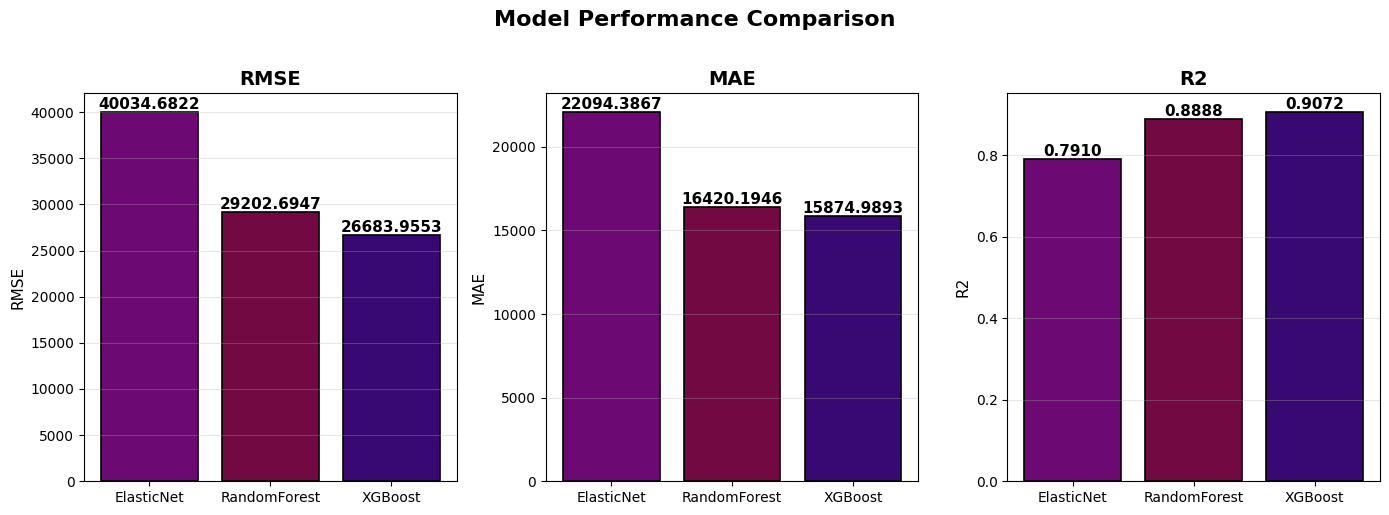


Top Feature Importances (Grouped Permutation)


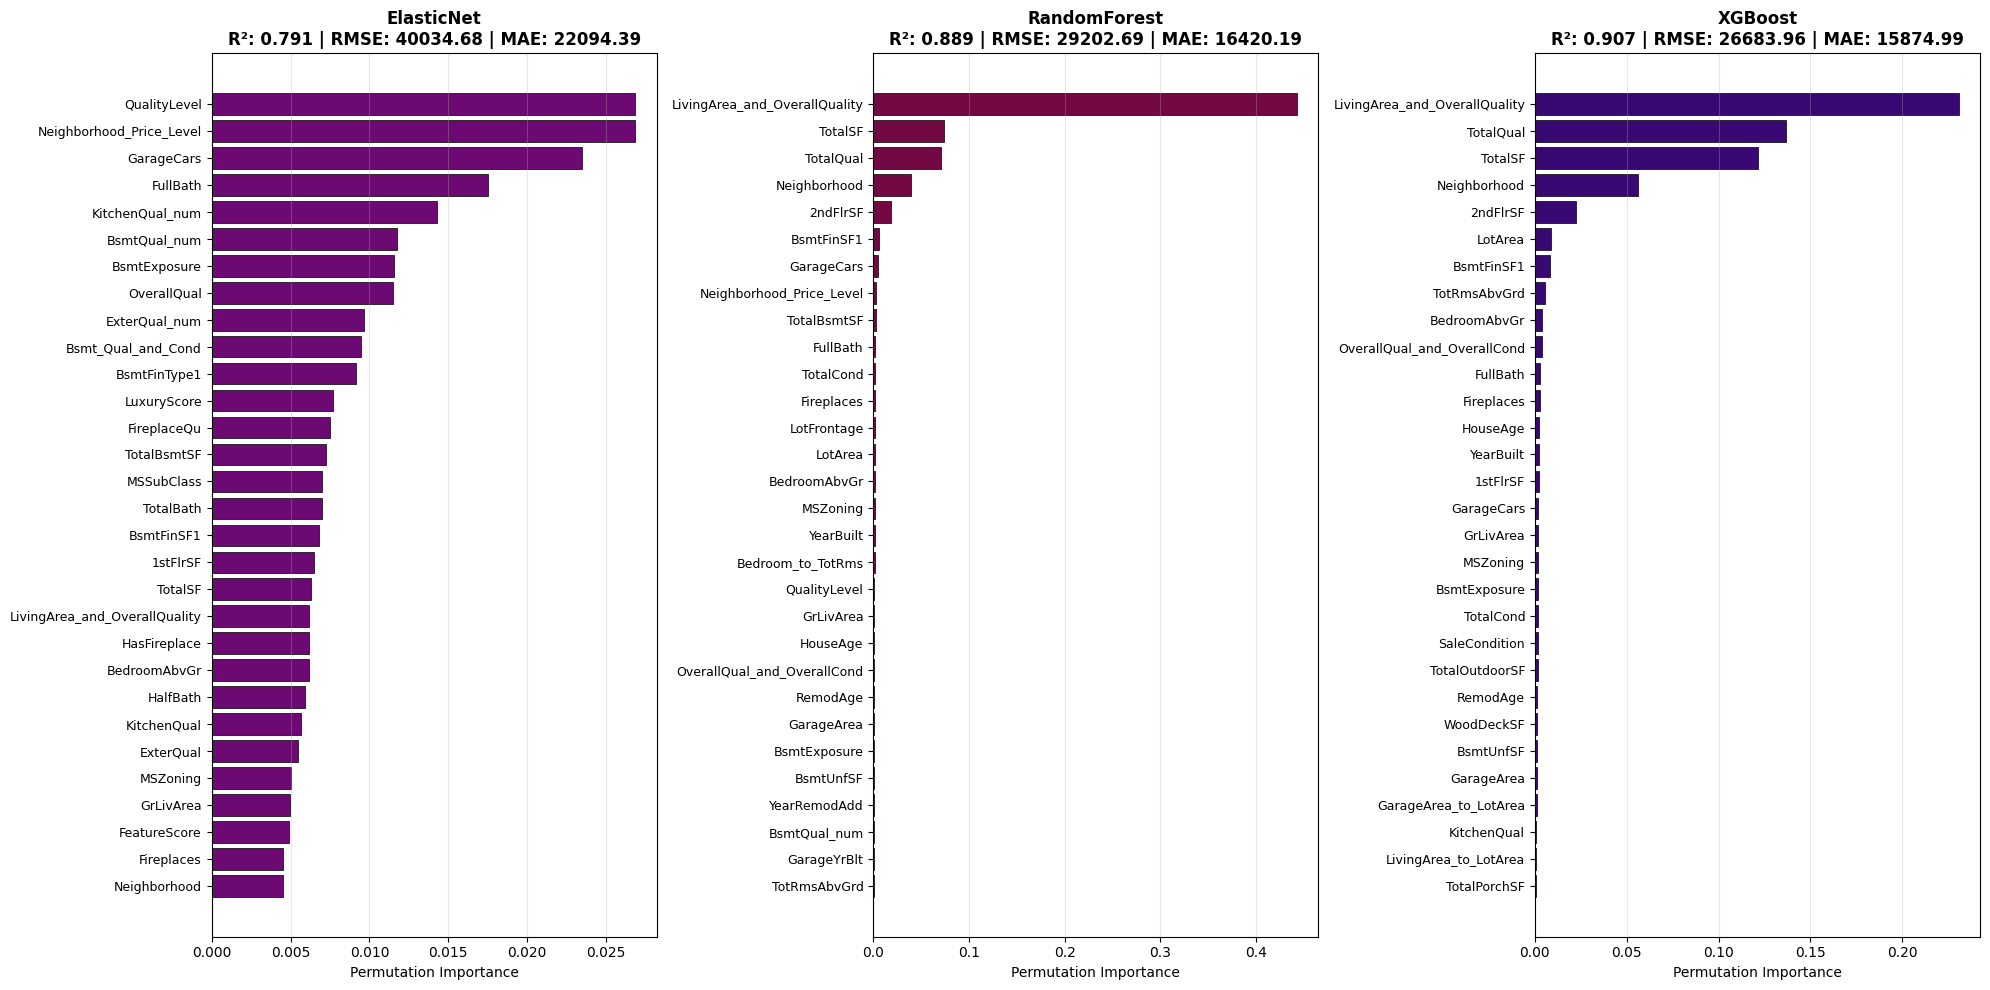


Detailed Importance Tables (All Features)


,Feature,Importance
1,QualityLevel,0.02686
2,Neighborhood_Price_Level,0.02682
3,GarageCars,0.02348
4,FullBath,0.01753
5,KitchenQual_num,0.01428
6,BsmtQual_num,0.01178
7,BsmtExposure,0.01154
8,OverallQual,0.01151
9,ExterQual_num,0.00964
10,Bsmt_Qual_and_Cond,0.00947


In [28]:
# Prepare data
feature_selection_X = df_engineered.drop("SalePrice", axis=1)
feature_selection_y = df_engineered["SalePrice"]

# Remove ID column if present
if "Id" in feature_selection_X.columns:
    feature_selection_X = feature_selection_X.drop("Id", axis=1)

# Split processed training data
X_train, X_val, y_train, y_val = train_test_split(
    feature_selection_X, feature_selection_y, test_size=0.2, random_state=42
)

# Run comparison
results = compare_feature_importance(
    X_train, X_val, y_train, y_val,
    cat_cols=cat_cols_engineered,
    cat_but_car=cat_but_car_engineered,
    top_n=30,
    show_tables=True
)

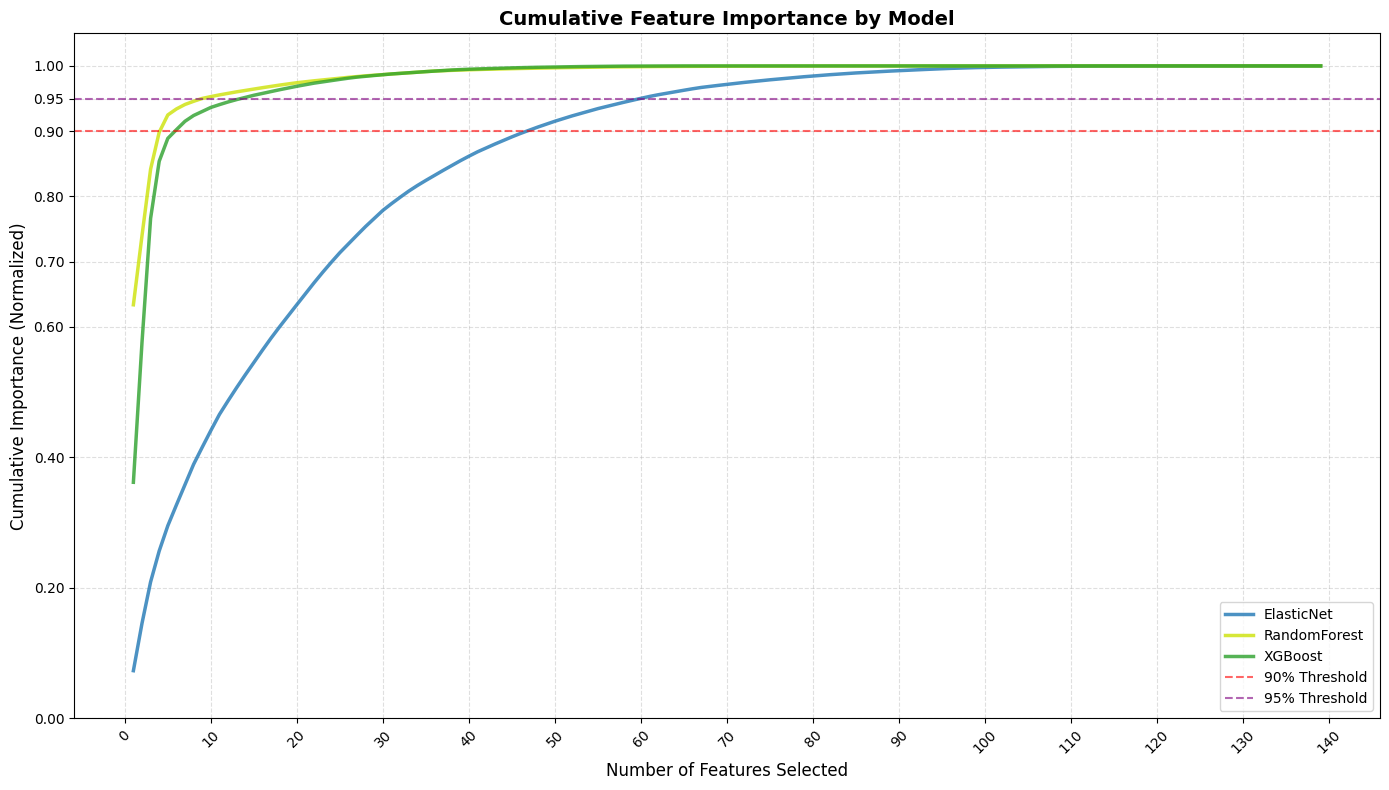


TOP 70 FEATURES (RANK AGGREGATION CONSENSUS)


Rank_Overall,Feature,ElasticNet,RandomForest,XGBoost,Score
1,LivingArea_and_OverallQuality,20,1,1,7.33
2,TotalSF,19,2,3,8.00
3,FullBath,4,10,11,8.33
4,GarageCars,3,7,16,8.67
5,BsmtFinSF1,17,6,7,10.00
6,Neighborhood,30,4,4,12.67
7,BedroomAbvGr,22,15,9,15.33
8,2ndFlrSF,40,5,5,16.67
9,BsmtExposure,7,25,19,17.00
10,Fireplaces,29,12,12,17.67


In [29]:
def analyze_feature_consensus(results, top_n_display=50):
    """
    Analyzes feature selection consensus across multiple models using Rank Aggregation.
    It does NOT retrain models; it only processes the 'results' dictionary.
    
    Methodology:
    1. Calculates cumulative importance for each model to visualize feature sufficiency.
    2. Ranks features in each model (1 = Most Important).
    3. Computes a 'Consensus Score' by averaging the ranks across models.
       Formula: Score = (Rank_Model1 + Rank_Model2 + Rank_Model3) / 3
    4. Generates a sorted table of features based on this consensus score (Lower is better).
    
    Parameters
    ----------
    results : dict
        Dictionary containing model results from 'compare_feature_importance'.
        Expected structure:
        {
            'ModelName': {'importances': pd.Series(values, index=feature_names), ...},
            ...
        }
    top_n_display : int, optional
        Number of top features to display in the final consensus table. Default is 50.
        
    Returns
    -------
    pd.DataFrame
        The consensus table containing individual ranks and the final score.
    """
    
    model_names = list(results.keys())
    
    # --- Part 1: Cumulative Importance Plot ---
    plt.figure(figsize=(14, 8))
    
    # Color palette for distinct lines
    colors = ['#1f77b4', '#cce206', '#2ca02c', '#d62728', '#9467bd']
    max_features = 0
    
    for i, model in enumerate(model_names):
        # Extract importances and sort descending
        imp = results[model]['importances'].sort_values(ascending=False)
        
        # Clip negative importances to 0 for cleaner cumulative plot
        imp_plot = imp.clip(lower=0)
        
        # Normalize to 0-1 range
        total_imp = imp_plot.sum()
        if total_imp > 0:
            cumulative_imp = imp_plot.cumsum() / total_imp
        else:
            cumulative_imp = pd.Series(0, index=imp.index)
            
        n_features = len(cumulative_imp)
        max_features = max(max_features, n_features)
        
        # Plot the line
        plt.plot(
            np.arange(1, n_features + 1), 
            cumulative_imp.values, 
            label=f"{model}",
            linewidth=2.5,
            color=colors[i % len(colors)],
            alpha=0.8
        )

    # X-axis: Intervals of 10
    x_ticks = np.arange(0, max_features + 10, 10)
    plt.xticks(x_ticks, rotation=45)
    plt.xlabel("Number of Features Selected", fontsize=12)
    
    # Y-axis: Specific intervals (0.7, 0.8, 0.9, ...)
    y_ticks = [0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
    plt.yticks(y_ticks)
    plt.ylabel("Cumulative Importance (Normalized)", fontsize=12)
    plt.ylim(0, 1.05)
    
    # Threshold lines for 90% and 95%
    plt.axhline(y=0.90, color='r', linestyle='--', alpha=0.6, label='90% Threshold')
    plt.axhline(y=0.95, color='purple', linestyle='--', alpha=0.6, label='95% Threshold')
    
    plt.title("Cumulative Feature Importance by Model", fontsize=14, fontweight='bold')
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.legend(loc='lower right', frameon=True)
    plt.tight_layout()
    plt.show()
    
    # --- Part 2: Rank Aggregation Table ---
    
    rank_data = {}
    
    for model in model_names:
        # Sort features by importance (Highest to Lowest)
        imp = results[model]['importances'].sort_values(ascending=False)
        
        # Assign Rank: 1 = Best Feature
        # Use existing index (feature names) to align later
        ranks = pd.Series(np.arange(1, len(imp) + 1), index=imp.index, name=f'Rank_{model}')
        rank_data[model] = ranks

    # Merge all model ranks into a single DataFrame
    # Outer join ensures no feature is lost if models have slightly different feature sets
    df_ranks = pd.DataFrame(rank_data)
    
    # Handle missing features (if any): Fill with worst rank + 1
    max_rank_possible = df_ranks.max().max()
    df_ranks = df_ranks.fillna(max_rank_possible + 1)
    
    # Calculate Consensus Score: Average of Ranks
    # Example: Feature A ranks (6, 24, 27) -> Score = 19
    df_ranks['Score'] = df_ranks.mean(axis=1)
    
    # Sort by Score (Lower score is better)
    df_ranks = df_ranks.sort_values('Score', ascending=True)
    
    # Prepare the display table
    output_table = df_ranks.head(top_n_display).copy()
    output_table = output_table.reset_index().rename(columns={'index': 'Feature'})
    
    # Add Overall Rank column
    output_table.insert(0, 'Rank_Overall', np.arange(1, len(output_table) + 1))
    
    # Round the score for readability
    output_table['Score'] = output_table['Score'].round(2)
    
    # Print the table
    print(f"\n{'='*80}")
    print(f"TOP {top_n_display} FEATURES (RANK AGGREGATION CONSENSUS)")
    print(f"{'='*80}")
    # Display logic checks for IPython environment to use pretty HTML table if available
    try:
        from IPython.display import display
        # Format Score column to 2 decimal places (only for this display)
        display(output_table.style.hide(axis='index').format({'Score': '{:.2f}'}))
    except ImportError:
        print(output_table.to_string(index=False))

    return df_ranks

df_ranks = analyze_feature_consensus(results, top_n_display=70)

In [30]:
selected_features = df_ranks.head(30).index.tolist()
print("\nSelected Features:\n", selected_features)

df_final = df_engineered[selected_features + ["SalePrice"]].copy()

check_df(df_final)


Selected Features:
 ['LivingArea_and_OverallQuality', 'TotalSF', 'FullBath', 'GarageCars', 'BsmtFinSF1', 'Neighborhood', 'BedroomAbvGr', '2ndFlrSF', 'BsmtExposure', 'Fireplaces', 'TotalQual', 'MSZoning', 'TotalBsmtSF', 'GrLivArea', 'TotRmsAbvGrd', 'RemodAge', 'OverallQual_and_OverallCond', 'LuxuryScore', 'GarageArea', 'KitchenQual', 'BsmtFinType1', 'FireplaceQu', 'HouseAge', 'LotFrontage', 'TotalOutdoorSF', 'LotArea', 'BsmtQual_num', 'HalfBath', 'BsmtUnfSF', 'TotalCond']
###################### Shape ######################
(1460, 31)

###################### Info ######################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   LivingArea_and_OverallQuality  1460 non-null   float64
 1   TotalSF                        1460 non-null   float64
 2   FullBath                       1460 non-null   int64  
 

,Type
LivingArea_and_OverallQuality,float64
TotalSF,float64
FullBath,int64
GarageCars,int64
BsmtFinSF1,float64
Neighborhood,object
BedroomAbvGr,int64
2ndFlrSF,int64
BsmtExposure,object
Fireplaces,int64



##################### Head #####################


,LivingArea_and_OverallQuality,TotalSF,FullBath,GarageCars,BsmtFinSF1,Neighborhood,BedroomAbvGr,2ndFlrSF,BsmtExposure,Fireplaces,TotalQual,MSZoning,TotalBsmtSF,GrLivArea,TotRmsAbvGrd,RemodAge,OverallQual_and_OverallCond,LuxuryScore,GarageArea,KitchenQual,BsmtFinType1,FireplaceQu,HouseAge,LotFrontage,TotalOutdoorSF,LotArea,BsmtQual_num,HalfBath,BsmtUnfSF,TotalCond,SalePrice
0,11970.000,2566.000,2,2,706.000,CollgCr,3,854,No,0,27,RL,856,1710.000,8,5,35,0,548.000,Gd,GLQ,None,5,65.000,61,8450,4,1,150.000,14,208500
1,7572.000,2524.000,2,2,978.000,Veenker,3,0,Gd,1,24,RL,1262,1262.000,6,31,48,0,460.000,TA,ALQ,TA,31,80.000,298,9600,4,0,284.000,17,181500
2,12502.000,2706.000,2,2,486.000,CollgCr,3,866,Mn,1,27,RL,920,1786.000,6,6,35,0,608.000,Gd,GLQ,TA,7,68.000,42,11250,4,1,434.000,14,223500
3,12019.000,2473.000,1,3,216.000,Crawfor,3,756,No,1,24,RL,756,1717.000,7,36,35,2,642.000,Gd,ALQ,Gd,91,60.000,307,9550,3,0,540.000,15,140000
4,17584.000,3343.000,2,3,655.000,NoRidge,4,1053,Av,1,28,RL,1145,2198.000,9,8,40,5,836.000,Gd,GLQ,TA,8,84.000,276,14260,4,1,490.000,14,250000



###################### Tail ######################


...

,count,mean,std,min,0%,5%,50%,95%,99%,100%,max
LivingArea_and_OverallQuality,1460.000,9596.727,4802.082,334.000,334.000,3840.000,8820.000,19090.050,24728.625,36270.000,36270.000
TotalSF,1460.000,2556.864,749.281,376.000,376.000,1536.000,2479.000,3960.000,4576.000,5557.000,5557.000
FullBath,1460.000,1.565,0.551,0.000,0.000,1.000,2.000,2.000,3.000,3.000,3.000
GarageCars,1460.000,1.767,0.747,0.000,0.000,0.000,2.000,3.000,3.000,4.000,4.000
BsmtFinSF1,1460.000,440.018,433.282,0.000,0.000,0.000,383.500,1274.000,1572.410,1810.000,1810.000
BedroomAbvGr,1460.000,2.866,0.816,0.000,0.000,2.000,3.000,4.000,5.000,8.000,8.000
2ndFlrSF,1460.000,346.992,436.528,0.000,0.000,0.000,0.000,1141.050,1418.920,2065.000,2065.000
Fireplaces,1460.000,0.613,0.645,0.000,0.000,0.000,1.000,2.000,2.000,3.000,3.000
TotalQual,1460.000,23.451,3.879,7.000,7.000,18.000,23.000,30.000,32.000,33.000,33.000
TotalBsmtSF,1460.000,1049.738,401.372,0.000,0.000,519.300,991.500,1753.000,2052.000,2217.000,2217.000



###################### Unique Value Counts per Column ######################


LivingArea_and_OverallQuality    1126
TotalSF                           960
FullBath                            4
GarageCars                          5
BsmtFinSF1                        632
Neighborhood                       25
BedroomAbvGr                        8
2ndFlrSF                          417
BsmtExposure                        5
Fireplaces                          4
TotalQual                          25
MSZoning                            5
TotalBsmtSF                       708
GrLivArea                         849
TotRmsAbvGrd                       11
RemodAge                           62
OverallQual_and_OverallCond        32
LuxuryScore                         9
GarageArea                        435
KitchenQual                         4
BsmtFinType1                        7
FireplaceQu                         6
HouseAge                          121
LotFrontage                       106
TotalOutdoorSF                    427
LotArea                          1073
BsmtQual_num


###################### NA ######################


,Missing Values
LivingArea_and_OverallQuality,0
TotalSF,0
FullBath,0
GarageCars,0
BsmtFinSF1,0
Neighborhood,0
BedroomAbvGr,0
2ndFlrSF,0
BsmtExposure,0
Fireplaces,0


In [31]:
final_cat_cols, final_num_cols, final_cat_but_car, final_num_but_cat = grab_col_names(df_final)
final_num_cols = [col for col in final_num_cols if col not in "Id"]

Observations: 1460
Variables: 31
cat_cols: 12
num_cols: 18
cat_but_car: 1
num_but_cat: 7


In [32]:
def encode_and_scale(
    X, 
    y=None,
    fitted_objects=None,
    cardinality_threshold=20,
    n_splits=5,
    scaler_type='maxabs',
    random_state=42
):
    """
    Encodes categorical features and scales numerical features.
    
    Training Mode (fitted_objects=None): Fits encoders/scaler and transforms data.
        I. Binary → Label Encoding (0/1)
        II. Low cardinality (< threshold) → One-Hot Encoding
        III. High cardinality (≥ threshold) → KFold Target Encoding
        IV.  Scaling → Applied ONLY to numerical and target-encoded features (preserves sparsity).
    
    Test Mode (fitted_objects provided): Transforms data using fitted objects.
        - Handles unseen categories in One-Hot encoding via reindexing.
        - Applies learned scaling parameters to appropriate columns.

    Parameters
    ----------
    X : pd.DataFrame
        Input features (without target variable)
    y : pd.Series, optional
        Target variable (required for training mode)
    fitted_objects : dict, optional
        Pre-fitted encoders/scaler (None = training, dict = test)
    cardinality_threshold : int, default=20
        Threshold for one-hot vs target encoding
    n_splits : int, default=5
        KFold splits for target encoding
    scaler_type : str, default='maxabs'
        Type of scaler: 'maxabs', 'standard', 'robust', 'minmax'
    
    Returns
    -------
    X_processed : pd.DataFrame
    fitted_objects : dict (training mode only)
    
    Examples
    --------
    >>> # Training mode
    >>> X_train_proc, fitted_obj = encode_and_scale(X_train, y_train)
    >>> 
    >>> # Test mode (using same encoders/scaler)
    >>> X_test_proc = encode_and_scale(X_test, fitted_objects=fitted_obj)
    """
    X_proc = X.copy()
    is_training_mode = fitted_objects is None
    
    if is_training_mode and y is None:
        raise ValueError("y (target) is required for training mode")
    
    if is_training_mode:
        # Auto-detect categorical and numerical columns
        cat_cols = X_proc.select_dtypes(include=['object', 'category']).columns.tolist()
        num_cols = X_proc.select_dtypes(include=['number']).columns.tolist()
        
        # Separate binary, low, and high cardinality
        binary_cols = []
        low_card_cols = []
        high_card_cols = []
        
        for col in cat_cols:
            n_unique = X_proc[col].nunique()
            if n_unique == 2:
                binary_cols.append(col)
            elif n_unique < cardinality_threshold:
                low_card_cols.append(col)
            else:
                high_card_cols.append(col)
        
        print(f"Categorical columns: {len(cat_cols)}")
        print(f"  - Binary: {len(binary_cols)} (label encode to 0/1)")
        print(f"  - One-Hot: {len(low_card_cols)} (cardinality < {cardinality_threshold})")
        print(f"  - Target (KFold): {len(high_card_cols)} (cardinality ≥ {cardinality_threshold})")
        
        # Binary encoding (label encode to 0/1)
        binary_mappings = {}
        for col in binary_cols:
            categories = sorted(X_proc[col].dropna().unique())
            if len(categories) == 2:
                mapping = {categories[0]: 0, categories[1]: 1}
            else:
                mapping = {categories[0]: 0}
            
            binary_mappings[col] = mapping
            X_proc[col] = X_proc[col].map(mapping)
        
        # One-hot encoding
        onehot_columns = []
        for col in low_card_cols:
            dummies = pd.get_dummies(X_proc[col], prefix=col, drop_first=True, dtype=int)
            onehot_columns.extend(dummies.columns.tolist())
            X_proc = pd.concat([X_proc.drop(col, axis=1), dummies], axis=1)
        
        # Target encoding with KFold
        target_encoders = {}
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        
        for col in high_card_cols:            
            encoded_values = np.zeros(len(X_proc))
            
            for train_idx, val_idx in kf.split(X_proc):
                train_means = y.iloc[train_idx].groupby(X_proc[col].iloc[train_idx]).mean()
                encoded_values[val_idx] = X_proc[col].iloc[val_idx].map(train_means)
            
            global_mean = y.mean()
            encoded_values = pd.Series(encoded_values, index=X_proc.index).fillna(global_mean)
            
            full_mean_map = y.groupby(X_proc[col]).mean().to_dict()
            target_encoders[col] = {'mean_map': full_mean_map, 'global_mean': global_mean}
            X_proc[col] = encoded_values
        
        # Scaling
        scaler_dict = {
            'maxabs': MaxAbsScaler(),
            'standard': StandardScaler(),
            'robust': RobustScaler(),
            'minmax': MinMaxScaler()
        }
        scaler = scaler_dict[scaler_type]

        # Avoid scaling Binary/One-Hot columns to preserve sparsity and 0/1 logic.
        cols_to_scale = num_cols + high_card_cols

        # Ensure we only scale columns that exist in the processed dataframe
        cols_to_scale = [c for c in cols_to_scale if c in X_proc.columns]
        
        if cols_to_scale:
            X_proc[cols_to_scale] = scaler.fit_transform(X_proc[cols_to_scale])
        
        print(f"Scaling: {scaler_type.upper()} applied to {len(cols_to_scale)} features.")
        
        fitted_objects = {
            'scaler': scaler,
            'binary_mappings': binary_mappings,
            'target_encoders': target_encoders,
            'onehot_columns': onehot_columns,
            'cols_to_scale': cols_to_scale,
            'feature_names': list(X_proc.columns),
            'categorical_cols': cat_cols,
            'numerical_cols': num_cols,
            'binary_cols': binary_cols,
            'low_card_cols': low_card_cols,
            'high_card_cols': high_card_cols
        }
        
        return X_proc, fitted_objects
    
    else:
        # TEST MODE
        scaler = fitted_objects['scaler']
        binary_mappings = fitted_objects['binary_mappings']
        target_encoders = fitted_objects['target_encoders']
        onehot_columns = fitted_objects['onehot_columns']
        cols_to_scale = fitted_objects.get('cols_to_scale', [])
        binary_cols = fitted_objects['binary_cols']
        low_card_cols = fitted_objects['low_card_cols']
        high_card_cols = fitted_objects['high_card_cols']
        
        # Binary encoding
        for col in binary_cols:
            if col in X_proc.columns:
                mapping = binary_mappings[col]
                X_proc[col] = X_proc[col].map(mapping).fillna(0)
        
        # One-hot encoding
        for col in low_card_cols:
            if col in X_proc.columns:
                dummies_test = pd.get_dummies(X_proc[col], prefix=col, drop_first=True, dtype=int)
                
                expected_cols = [c for c in onehot_columns if c.startswith(col + '_')]

                dummies_aligned = dummies_test.reindex(columns=expected_cols, fill_value=0)
                X_proc = pd.concat([X_proc.drop(col, axis=1), dummies_aligned], axis=1)
        
        # Target encoding
        for col in high_card_cols:
            if col in X_proc.columns:
                mean_map = target_encoders[col]['mean_map']
                global_mean = target_encoders[col]['global_mean']
                X_proc[col] = X_proc[col].map(mean_map).fillna(global_mean)
        
        # Scaling
        # Check if columns to scale exist in test set
        test_cols_to_scale = [c for c in cols_to_scale if c in X_proc.columns]

        if test_cols_to_scale:
            X_proc[test_cols_to_scale] = scaler.transform(X_proc[test_cols_to_scale])

        # Final Alignment
        # Ensure test set has exactly the same columns in the same order as training
        # Missing columns (if any) are filled with 0
        X_proc = X_proc.reindex(columns=fitted_objects['feature_names'], fill_value=0)
        
        print(f"Test mode: {X_proc.shape}")
        
        return X_proc

In [34]:
X = df_final.drop("SalePrice", axis=1)
y = df_final["SalePrice"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

X_train_proc, fitted_obj = encode_and_scale(
    X_train, 
    y=y_train,
    cardinality_threshold=20,
    n_splits=5,
    scaler_type='maxabs',
    random_state=42
)

print(f"\nX_train_proc shape: {X_train_proc.shape}")
print(f"fitted_obj keys: {list(fitted_obj.keys())}")

X_val_proc = encode_and_scale(
    X_val,
    fitted_objects=fitted_obj  # Test mode
)

print(f"X_val_proc shape: {X_val_proc.shape}")

X_train shape: (1168, 30)
X_val shape: (292, 30)
Categorical columns: 6
  - Binary: 0 (label encode to 0/1)
  - One-Hot: 5 (cardinality < 20)
  - Target (KFold): 1 (cardinality ≥ 20)
Scaling: MAXABS applied to 25 features.

X_train_proc shape: (1168, 47)
fitted_obj keys: ['scaler', 'binary_mappings', 'target_encoders', 'onehot_columns', 'cols_to_scale', 'feature_names', 'categorical_cols', 'numerical_cols', 'binary_cols', 'low_card_cols', 'high_card_cols']
Test mode: (292, 47)
X_val_proc shape: (292, 47)


In [35]:
def train_and_optimize_models(
    X_train,
    y_train,
    X_val=None,
    y_val=None,
    models='all',
    cv=5,
    n_trials=100,
    random_state=42,
    n_jobs=-1,
    verbose=1
):
    """
    Trains and optimizes multiple regression models using Optuna.
    Pruning: Stops unpromising trials early (saves RAM/time) for SVR, RF, XGB, LGBM, and CatBoost

    Parameters
    ----------
    X_train : pd.DataFrame or np.ndarray
        Training features (already encoded and scaled)
    y_train : pd.Series or np.ndarray
        Training target variable
    X_val : pd.DataFrame or np.ndarray, optional
        Validation features (for final evaluation)
    y_val : pd.Series or np.ndarray, optional
        Validation target variable
    models : str or list, default='all'
        Which models to train:
        - 'all': Train all 7 models
        - list: ['elasticnet', 'xgboost', 'lightgbm', ...]
    cv : int, default=5
        Number of cross-validation folds
    n_trials : int, default=100
        Number of Optuna trials per model
    random_state : int, default=42
        Random state for reproducibility
    n_jobs : int, default=-1
        Number of parallel jobs (-1 = use all cores)
    verbose : int, default=1
        Verbosity level (0=silent, 1=progress, 2=detailed)
    
    Returns
    -------
    results : dict
        Detailed results for each model with best_model, best_params, scores
    results_df : pd.DataFrame
        Summary DataFrame sorted by CV score
    
    Examples
    --------
    >>> # Train all models
    >>> results, df = train_and_optimize_models(X_train_proc, y_train, X_val_proc, y_val)
    >>> 
    >>> # Train only specific models (faster)
    >>> results, df = train_and_optimize_models(
    ...     X_train_proc, y_train, 
    ...     models=['elasticnet', 'xgboost', 'catboost'],
    ...     n_trials=50
    ... )
    """
    
    # Setup cross-validation
    kfold = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    
    # Suppress Optuna logs if verbose=0
    optuna.logging.set_verbosity(optuna.logging.WARNING if verbose == 0 else optuna.logging.INFO)
    
    # Objective Functions
    # Fast Models (Use cross_val_score, pruning is less critical here)
    def objective_elasticnet(trial):
        params = {
            'alpha': trial.suggest_float('alpha', 0.001, 10.0, log=True),
            'l1_ratio': trial.suggest_float('l1_ratio', 0.1, 0.9),
            'max_iter': trial.suggest_categorical('max_iter', [1000, 2000, 5000, 10000]),
            'random_state': random_state
        }
        model = ElasticNet(**params)
        scores = cross_val_score(model, X_train, y_train, cv=kfold, 
                                 scoring='neg_mean_squared_log_error', n_jobs=n_jobs)
        return np.sqrt(-scores.mean())
    
    def objective_knn(trial):
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 3, 15),
            'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
            'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan']),
            'n_jobs': n_jobs
        }
        model = KNeighborsRegressor(**params)
        scores = cross_val_score(model, X_train, y_train, cv=kfold,
                                 scoring='neg_mean_squared_log_error', n_jobs=n_jobs)
        return np.sqrt(-scores.mean())
    
    # Heavy Models (Manual CV loop for Pruning support)
    def objective_svr(trial):
        params = {
            'C': trial.suggest_float('C', 0.1, 100.0, log=True),
            'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly']),
            'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
            'epsilon': trial.suggest_float('epsilon', 0.01, 0.2)
        }
        
        fold_scores = []
        # Manual CV loop to enable pruning
        for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
            X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model = SVR(**params)
            model.fit(X_tr, y_tr)
            
            # Predict and Clip (safety for RMSLE)
            y_pred = np.clip(model.predict(X_val_fold), 0, None)
            rmsle = np.sqrt(mean_squared_log_error(y_val_fold, y_pred))
            fold_scores.append(rmsle)
            
            # Report intermediate result to Optuna
            trial.report(rmsle, fold_idx)
            
            # Prune if the trial is unpromising
            if trial.should_prune():
                raise optuna.TrialPruned()
                
        return np.mean(fold_scores)
    
    def objective_random_forest(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
            'max_depth': trial.suggest_int('max_depth', 10, 30, step=5),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            'random_state': random_state,
            'n_jobs': n_jobs 
        }
        
        fold_scores = []
        for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
            X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model = RandomForestRegressor(**params)
            model.fit(X_tr, y_tr)
            
            y_pred = np.clip(model.predict(X_val_fold), 0, None)
            rmsle = np.sqrt(mean_squared_log_error(y_val_fold, y_pred))
            fold_scores.append(rmsle)
            
            trial.report(rmsle, fold_idx)
            if trial.should_prune():
                raise optuna.TrialPruned()
                
        return np.mean(fold_scores)
    
    def objective_xgboost(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'subsample': trial.suggest_float('subsample', 0.7, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
            'random_state': random_state,
            'n_jobs': n_jobs,
            'verbosity': 0
        }
        
        fold_scores = []
        for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
            X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model = XGBRegressor(**params)
            model.fit(X_tr, y_tr)
            y_pred = np.clip(model.predict(X_val_fold), 0, None)
            rmsle = np.sqrt(mean_squared_log_error(y_val_fold, y_pred))
            fold_scores.append(rmsle)
            
            trial.report(rmsle, fold_idx)
            if trial.should_prune():
                raise optuna.TrialPruned()
        
        return np.mean(fold_scores)
    
    def objective_lightgbm(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 31, 100),
            'subsample': trial.suggest_float('subsample', 0.7, 1.0),
            'random_state': random_state,
            'n_jobs': n_jobs,
            'verbose': -1
        }
        
        fold_scores = []
        for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
            X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model = LGBMRegressor(**params)
            model.fit(X_tr, y_tr)
            y_pred = np.clip(model.predict(X_val_fold), 0, None)
            rmsle = np.sqrt(mean_squared_log_error(y_val_fold, y_pred))
            fold_scores.append(rmsle)
            
            trial.report(rmsle, fold_idx)
            if trial.should_prune():
                raise optuna.TrialPruned()
        
        return np.mean(fold_scores)
    
    def objective_catboost(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 100, 300, step=50),
            'depth': trial.suggest_int('depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 7),
            'random_state': random_state,
            'verbose': 0
        }

        fold_scores = []
        for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
            X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model = CatBoostRegressor(**params)
            model.fit(X_tr, y_tr)
            y_pred = np.clip(model.predict(X_val_fold), 0, None)
            rmsle = np.sqrt(mean_squared_log_error(y_val_fold, y_pred))
            fold_scores.append(rmsle)
            
            trial.report(rmsle, fold_idx)
            if trial.should_prune():
                raise optuna.TrialPruned()
        
        return np.mean(fold_scores)
    
    # Model registry
    MODEL_REGISTRY = {
        'elasticnet': objective_elasticnet,
        'knn': objective_knn,
        'svr': objective_svr,
        'random_forest': objective_random_forest,
        'xgboost': objective_xgboost,
        'lightgbm': objective_lightgbm,
        'catboost': objective_catboost
    }
    
    # Determine which models to train
    if models == 'all':
        selected_models = list(MODEL_REGISTRY.keys())
    else:
        selected_models = models
    
    # Validate model names
    invalid_models = set(selected_models) - set(MODEL_REGISTRY.keys())
    if invalid_models:
        raise ValueError(f"Invalid model names: {invalid_models}. Valid: {list(MODEL_REGISTRY.keys())}")
    

    # Pruner configuration
    # n_warmup_steps=2: Pruning starts after the 2nd fold (0 and 1 are safe).
    # This is a conservative approach to avoid killing potentially good models too early.
    pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=2)
    
    # Results storage
    results = {}
    summary_data = []
    
    if verbose >= 1:
        print(f"\n{'='*70}")
        print(f"Training {len(selected_models)} models with Optuna (RMSLE metric)")
        print(f"Train set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
        print(f"Trials per model: {n_trials} | CV folds: {cv}")
        if X_val is not None:
            print(f"Validation set: {X_val.shape[0]} samples")
        print(f"{'='*70}\n")
    
    # Train each model
    for i, model_name in enumerate(selected_models, 1):
        if verbose >= 1:
            print(f"[{i}/{len(selected_models)}] Optimizing {model_name.upper()} ({n_trials} trials)...")
        
        start_time = time.time()

        try:
            # Create study for each model
            study = optuna.create_study(
                direction='minimize',
                pruner=pruner,
                sampler=optuna.samplers.TPESampler(seed=random_state)
            )
            
            objective_func = MODEL_REGISTRY[model_name]
            
            # Run optimization
            # n_jobs=1: Using sequential optimization to save RAM and allow models 
            # to use internal parallelization (n_jobs=-1).
            study.optimize(
                objective_func,
                n_trials=n_trials,
                show_progress_bar=(verbose >= 1),
                n_jobs=1,
                catch=(Exception,) # Catches model-specific errors without crashing the loop
            )
            
            # Best params and score
            best_params = study.best_params
            cv_score = study.best_value
            
            # Re-instantiate the best model
            if model_name == 'elasticnet':
                best_model = ElasticNet(**best_params)
            elif model_name == 'knn':
                best_model = KNeighborsRegressor(**best_params, n_jobs=n_jobs)
            elif model_name == 'svr':
                best_model = SVR(**best_params)
            elif model_name == 'random_forest':
                best_model = RandomForestRegressor(**best_params, n_jobs=n_jobs)
            elif model_name == 'xgboost':
                best_model = XGBRegressor(**best_params)
            elif model_name == 'lightgbm':
                best_model = LGBMRegressor(**best_params)
            elif model_name == 'catboost':
                best_model = CatBoostRegressor(**best_params)
            
            # Fit on full training set
            best_model.fit(X_train, y_train)
            
            # Metrics on Train
            y_train_pred = np.clip(best_model.predict(X_train), 0, None)
            train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
            train_mae = mean_absolute_error(y_train, y_train_pred)
            train_r2 = r2_score(y_train, y_train_pred)
            
            # Metrics on Validation (if provided)
            val_rmsle = val_mae = val_r2 = None
            if X_val is not None and y_val is not None:
                y_val_pred = np.clip(best_model.predict(X_val), 0, None)
                val_rmsle = np.sqrt(mean_squared_log_error(y_val, y_val_pred))
                val_mae = mean_absolute_error(y_val, y_val_pred)
                val_r2 = r2_score(y_val, y_val_pred)
            
            elapsed = time.time() - start_time
            
            # Store results
            results[model_name] = {
                'best_model': best_model,
                'best_params': best_params,
                'cv_rmsle': cv_score,
                'train_rmsle': train_rmsle,
                'train_mae': train_mae,
                'train_r2': train_r2,
                'val_rmsle': val_rmsle,
                'val_mae': val_mae,
                'val_r2': val_r2,
                'fit_time': elapsed,
                'study': study
            }
            
            summary_data.append({
                'Model': model_name,
                'CV_RMSLE': cv_score,
                'Train_RMSLE': train_rmsle,
                'Train_R2': train_r2,
                'Train_MAE': train_mae,
                'Val_RMSLE': val_rmsle,
                'Val_R2': val_r2,
                'Val_MAE': val_mae,
                'Time(s)': elapsed
            })
        
            
            if verbose >= 1:
                print(f"--- {model_name.upper()} RESULTS ---")
                print(f"CV RMSLE: {cv_score:.4f}")
                print(f"Train RMSLE: {train_rmsle:.4f} | MAE: {train_mae:.4f} | R2: {train_r2:.4f}")
                if val_rmsle: print(f"Val RMSLE: {val_rmsle:.4f} | MAE: {val_mae:.4f} | R2: {val_r2:.4f}")
                print(f"Time: {elapsed:.2f}s | Trials: {len(study.trials)}")
                print(f"Best params: {best_params}")
                print()
                
        except Exception as e:
            print(f"!! ERROR optimizing {model_name}: {str(e)}")
            continue

    # Final summary
    results_df = pd.DataFrame(summary_data).sort_values('CV_RMSLE').reset_index(drop=True)
    
    if verbose >= 1:
        print(f"{'='*70}")
        print("RESULTS SUMMARY (sorted by CV_RMSLE):")
        print(results_df.to_string(index=False))
        print(f"{'='*70}\n")
    
    return results, results_df

In [36]:
results, results_df = train_and_optimize_models(
    X_train_proc, 
    y_train,
    X_val_proc,
    y_val,
    models='all',
    n_trials=200,
    cv=5,
    verbose=2
)

[I 2026-01-10 21:18:50,170] A new study created in memory with name: no-name-35380458-ce10-4991-ace7-946e35fa8a76



Training 7 models with Optuna (RMSLE metric)
Train set: 1168 samples, 47 features
Trials per model: 200 | CV folds: 5
Validation set: 292 samples

[1/7] Optimizing ELASTICNET (200 trials)...


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-01-10 21:18:50,238] Trial 0 finished with value: 0.1345464545707719 and parameters: {'alpha': 0.03148911647956861, 'l1_ratio': 0.8605714451279329, 'max_iter': 1000}. Best is trial 0 with value: 0.1345464545707719.
[I 2026-01-10 21:18:50,296] Trial 1 finished with value: 0.13455857925776413 and parameters: {'alpha': 0.0017073967431528124, 'l1_ratio': 0.7929409166199481, 'max_iter': 10000}. Best is trial 0 with value: 0.1345464545707719.
[I 2026-01-10 21:18:50,322] Trial 2 finished with value: 0.3114452715545417 and parameters: {'alpha': 2.1368329072358767, 'l1_ratio': 0.26987128854262094, 'max_iter': 10000}. Best is trial 0 with value: 0.1345464545707719.
[I 2026-01-10 21:18:50,347] Trial 3 finished with value: 0.1463068551449453 and parameters: {'alpha': 0.05342937261279776, 'l1_ratio': 0.3329833121584336, 'max_iter': 1000}. Best is trial 0 with value: 0.1345464545707719.
[I 2026-01-10 21:18:50,373] Trial 4 finished with value: 0.13982387577889122 and parameters: {'alpha': 0.06

[I 2026-01-10 21:18:58,588] A new study created in memory with name: no-name-f9b2125e-fd26-4c80-a1e7-ca3c974748fe


...

[I 2026-01-10 21:31:43,826] Trial 0 finished with value: 0.1347465863035399 and parameters: {'n_estimators': 150, 'max_depth': 10, 'learning_rate': 0.08960785365368121, 'num_leaves': 72, 'subsample': 0.7468055921327309}. Best is trial 0 with value: 0.1347465863035399.
[I 2026-01-10 21:31:44,007] Trial 1 finished with value: 0.1291454645906383 and parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.13394334706750485, 'num_leaves': 73, 'subsample': 0.9124217733388136}. Best is trial 1 with value: 0.1291454645906383.
[I 2026-01-10 21:31:44,469] Trial 2 finished with value: 0.13445216193716095 and parameters: {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.12106896936002161, 'num_leaves': 45, 'subsample': 0.7545474901621302}. Best is trial 1 with value: 0.1291454645906383.
[I 2026-01-10 21:31:44,795] Trial 3 finished with value: 0.13351515847702683 and parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.048164145309070844, 'num_leaves': 61, 'subs

[I 2026-01-10 21:33:44,105] A new study created in memory with name: no-name-1d514c35-0e65-40f2-87c1-09323f35e686


[I 2026-01-10 21:33:44,049] Trial 199 pruned. 
--- LIGHTGBM RESULTS ---
CV RMSLE: 0.1291
Train RMSLE: 0.0946 | MAE: 11046.5483 | R2: 0.9561
Val RMSLE: 0.1392 | MAE: 16496.2198 | R2: 0.8969
Time: 120.89s | Trials: 200
Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.13394334706750485, 'num_leaves': 73, 'subsample': 0.9124217733388136}

[7/7] Optimizing CATBOOST (200 trials)...


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-01-10 21:33:55,737] Trial 0 finished with value: 0.12908163610897386 and parameters: {'iterations': 150, 'depth': 10, 'learning_rate': 0.08960785365368121, 'l2_leaf_reg': 5}. Best is trial 0 with value: 0.12908163610897386.
[I 2026-01-10 21:33:56,454] Trial 1 finished with value: 0.22743609400395295 and parameters: {'iterations': 100, 'depth': 5, 'learning_rate': 0.011900590783184251, 'l2_leaf_reg': 7}. Best is trial 0 with value: 0.12908163610897386.
[I 2026-01-10 21:34:02,526] Trial 2 finished with value: 0.16287993824920427 and parameters: {'iterations': 250, 'depth': 8, 'learning_rate': 0.010636066512540286, 'l2_leaf_reg': 7}. Best is trial 0 with value: 0.12908163610897386.
[I 2026-01-10 21:34:04,677] Trial 3 finished with value: 0.13327384560357808 and parameters: {'iterations': 300, 'depth': 5, 'learning_rate': 0.017240892195821537, 'l2_leaf_reg': 2}. Best is trial 0 with value: 0.12908163610897386.
[I 2026-01-10 21:34:06,838] Trial 4 finished with value: 0.1323838900272

In [52]:
# Compatibility Wrapper for Sklearn 1.6+
class SklearnWrapper(BaseEstimator, RegressorMixin):
    """
    A compatibility wrapper for third-party estimators (e.g., CatBoost, XGBoost)
    to ensure full compliance with Scikit-learn 1.6+ strict tag checks.

    This wrapper implements the new '__sklearn_tags__' method required by 
    sklearn 1.6+ to validte the estimator type.
    """
    
    # Legacy support (Scikit-learn < 1.6)
    _estimator_type = "regressor"

    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, y):
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X, y)
        return self

    def predict(self, X):
        return self.estimator_.predict(X)
    
    def get_params(self, deep=True):
        return {"estimator": self.estimator}

    def set_params(self, **params):
        if "estimator" in params:
            self.estimator = params["estimator"]
        return self

    # --- CRITICAL FIX FOR SKLEARN 1.6+ ---
    def __sklearn_tags__(self):
        # Call the parent's tags generation (BaseEstimator)
        tags = super().__sklearn_tags__()
        # Explicitly set the estimator type in the new tags structure
        tags.estimator_type = "regressor"
        return tags


def train_dynamic_stacking(
    results,
    X_train,
    y_train,
    X_val=None,
    y_val=None,
    included_models='all',
    meta_learner=None,
    cv=5,
    random_state=42,
    verbose=1
):
    """
    Trains and optimises a Stacking Regressor using pre-tuned base models.
    
    This function dynamically reconstructs model instances using the 'best_params' 
    found in the previous optimisation step. It avoids data leakage by retraining 
    base models from scratch within the stacking cross-validation scheme.
    
    It also automatically wraps boosting models (CatBoost, XGBoost, LightGBM)
    to prevent compatibility issues with newer Scikit-learn versions.

    Parameters
    ----------
    results : dict
        Dictionary containing results from 'train_and_optimize_models', specifically 
        requiring the 'best_params' key for each model.
    X_train : pd.DataFrame or np.ndarray
        Training features.
    y_train : pd.Series or np.ndarray
        Training target variable.
    X_val : pd.DataFrame or np.ndarray, optional
        Validation features for final evaluation.
    y_val : pd.Series or np.ndarray, optional
        Validation target variable.
    included_models : list or str, default='all'
        Specifies which models to include in the stack:
        - 'all': Includes all models present in the 'results' dictionary.
        - list: A specific list of model names, e.g., ['catboost', 'elasticnet'].
    meta_learner : sklearn estimator, optional
        The final estimator used to combine base model predictions.
        If None, defaults to RidgeCV (L2 regularised linear regression).
    cv : int, default=5
        Number of cross-validation folds for the stacking procedure.
    random_state : int, default=42
        Random state for reproducibility.
    verbose : int, default=1
        Verbosity level (0=silent, 1=progress/summary).

    Returns
    -------
    stacking_model : sklearn.ensemble.StackingRegressor
        The fitted Stacking Regressor ready for prediction.
    metrics : dict
        Performance metrics (RMSLE, MAE, R2) on training and validation sets.

    Examples
    --------
    >>> # Stack specific models from previous results
    >>> stack_model, metrics = train_dynamic_stacking(
    ...     results=results,
    ...     X_train=X_train, y_train=y_train,
    ...     included_models=['catboost', 'xgboost', 'elasticnet']
    ... )
    """
    
    # Model Factory: Maps string identifiers to class objects
    MODEL_FACTORY = {
        'xgboost': XGBRegressor,
        'lightgbm': LGBMRegressor,
        'catboost': CatBoostRegressor,
        'random_forest': RandomForestRegressor,
        'elasticnet': ElasticNet,
        'knn': KNeighborsRegressor,
        'svr': SVR
    }
    
    # Identify models to include in the stack
    available_models = list(results.keys())
    if included_models == 'all':
        target_models = available_models
    else:
        # Filter models: must exist in both 'results' and user request
        target_models = [m for m in included_models if m in available_models]
    
    if verbose >= 1:
        print(f"{'='*70}")
        print(f"Building Stacking Regressor with {len(target_models)} models")
        print(f"Included: {', '.join([m.upper() for m in target_models])}")
        print(f"{'='*70}")

    # Instantiate base estimators with optimised parameters
    estimators = []
    for model_name in target_models:
        if model_name not in MODEL_FACTORY:
            if verbose >= 1:
                print(f"Warning: No class definition found for '{model_name}'. Skipped.")
            continue
            
        best_params = results[model_name]['best_params']
        model_class = MODEL_FACTORY[model_name]
        
        # Handle random_state safety for applicable models
        if 'random_state' in best_params:
            model_instance = model_class(**best_params)
        elif hasattr(model_class(), 'random_state'):
            model_instance = model_class(**best_params, random_state=random_state)
        else:
            model_instance = model_class(**best_params)

        # Apply wrapper to specific boosting models to fix sklearn 1.6+ compatibility
        if model_name in ['catboost', 'xgboost', 'lightgbm']:
            model_instance = SklearnWrapper(model_instance)

        estimators.append((model_name, model_instance))
        
    # Configure Meta-Learner (Default: RidgeCV)
    if meta_learner is None:
        meta_learner = RidgeCV(alphas=[0.1, 1.0, 10.0])

    # Initialise and fit Stacking Regressor
    # n_jobs=-1 ensures parallel execution for base model training
    stacking_regressor = StackingRegressor(
        estimators=estimators,
        final_estimator=meta_learner,
        cv=cv,
        n_jobs=-1,
        passthrough=False
    )
    
    if verbose >= 1:
        print("\nTraining Stacking Regressor (this may take time)...")
    
    stacking_regressor.fit(X_train, y_train)
    
    # Calculate performance metrics
    metrics = {}
    
    # Training metrics
    y_train_pred = np.clip(stacking_regressor.predict(X_train), 0, None)
    metrics['train_rmsle'] = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
    metrics['train_mae'] = mean_absolute_error(y_train, y_train_pred)
    metrics['train_r2'] = r2_score(y_train, y_train_pred)
    
    # Validation metrics
    if X_val is not None and y_val is not None:
        y_val_pred = np.clip(stacking_regressor.predict(X_val), 0, None)
        metrics['val_rmsle'] = np.sqrt(mean_squared_log_error(y_val, y_val_pred))
        metrics['val_mae'] = mean_absolute_error(y_val, y_val_pred)
        metrics['val_r2'] = r2_score(y_val, y_val_pred)
        
        if verbose >= 1:
            print(f"\nStacking Results:")
            print(f"Train RMSLE: {metrics['train_rmsle']:.4f}")
            print(f"Val RMSLE: {metrics['val_rmsle']:.4f}")
            print(f"Val R2   : {metrics['val_r2']:.4f}")
            print(f"{'='*70}\n")
    
    return stacking_regressor, metrics

In [55]:
stack_model, stack_metrics = train_dynamic_stacking(
    results,
    X_train_proc,
    y_train,
    X_val_proc,
    y_val,
    included_models=["catboost", "xgboost", "lightgbm", "random_forest", "elasticnet"],
    cv=5,
    verbose=2
    )

Building Stacking Regressor with 5 models
Included: CATBOOST, XGBOOST, LIGHTGBM, RANDOM_FOREST, ELASTICNET

Training Stacking Regressor (this may take time)...
0:	learn: 74748.3027497	total: 55.2ms	remaining: 13.7s
1:	learn: 72499.6727290	total: 61ms	remaining: 7.56s
2:	learn: 70180.2133643	total: 67ms	remaining: 5.52s
3:	learn: 67915.2001940	total: 72.7ms	remaining: 4.47s
4:	learn: 65876.7286870	total: 78.2ms	remaining: 3.83s
5:	learn: 63862.0770541	total: 86.1ms	remaining: 3.5s
6:	learn: 61863.5074320	total: 92.3ms	remaining: 3.2s
7:	learn: 59991.2291609	total: 97.6ms	remaining: 2.95s
8:	learn: 58309.0669219	total: 102ms	remaining: 2.73s
9:	learn: 56562.1540121	total: 107ms	remaining: 2.58s
10:	learn: 54953.5950266	total: 112ms	remaining: 2.43s
11:	learn: 53485.9802632	total: 116ms	remaining: 2.3s
12:	learn: 51939.1588596	total: 119ms	remaining: 2.17s
13:	learn: 50559.2062331	total: 123ms	remaining: 2.08s
14:	learn: 49171.5977646	total: 127ms	remaining: 1.99s
15:	learn: 47884.7138773